# scraping

In [ ]:
import urllib3
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from time import sleep

def soupify(url:str):
    http = urllib3.PoolManager()
    response = http.request("GET", url)
    soup = BeautifulSoup(response.data)

    return soup

In [ ]:
# win = 1 if team1 win else 0
df = pd.DataFrame(columns = ["season","round", "team1", "team2", "team1_seed","team2_seed","win"])
df

,season,round,team1,team2,team1_seed,team2_seed,win


In [ ]:
# team : url
team_info: dict["str", "str"] = dict()
team_info

{}

In [ ]:
regions: list[str] = ["east", "midwest", "south", "west", "national"]
url_head: str = "https://www.sports-reference.com/"

In [ ]:
int(64/(2**(5-1)))

4

In [ ]:
[8/(2**round) for round in range(4)]

[8.0, 4.0, 2.0, 1.0]

In [ ]:
# rounds for each region (not national)
# round 1 - 64
# round 2 - 32
# round 3 - 16
# round 4 - 8
# round 5 - final four team (not the game, just the regional winner)

In [ ]:
s24 = soupify("https://www.sports-reference.com/cbb/postseason/men/2024-ncaa.html")

In [ ]:
s24.find('h1').find('span').contents[0]

'2024'

In [ ]:
# s24.find('div', {"id" : "bracket"})

In [ ]:
s24.find('div', {"id" : "east"}).find_all('div', {"class" : "round"})[0].find_all('div')[21]

<div> <!-- game -->
<div class="winner"> <!-- team -->
<span>2</span>
<a href="/cbb/schools/iowa-state/men/2024.html">Iowa State</a>
<a href="/cbb/boxscores/2024-03-21-19-iowa-state.html">82</a>
</div>
<div> <!-- team -->
<span>15</span>
<a href="/cbb/schools/south-dakota-state/men/2024.html">South Dakota State</a>
<a href="/cbb/boxscores/2024-03-21-19-iowa-state.html">65</a>
</div>
<span><a href="/cbb/boxscores/2024-03-21-19-iowa-state.html">at Omaha, NE</a></span>
</div>

In [ ]:
temp = s24.find('div', {"id" : "east"}).find_all('div', {"class" : "round"})[0].find_all('div')[21]
temp
tL = [int(temp.find_all('span')[0].contents[0]),
      temp.find_all('a')[0].contents[0],
      url_head + temp.find_all('a', href = True)[0]["href"],
      int(temp.find_all("span")[1].contents[0]),
      temp.find_all('a')[2].contents[0],
      url_head + temp.find_all('a', href = True)[2]["href"],
      1 if int(temp.find_all('a')[1].contents[0]) > int(temp.find_all('a')[3].contents[0]) else 0]
tL

[2,
 'Iowa State',
 'https://www.sports-reference.com//cbb/schools/iowa-state/men/2024.html',
 15,
 'South Dakota State',
 'https://www.sports-reference.com//cbb/schools/south-dakota-state/men/2024.html',
 1]

In [ ]:
# season: int = int(s24.find('h1').find('span').contents[0])
for region in regions[:4]:
    curr_region = s24.find("div", {"id" : "brackets"}).find("div", {"id": region})
    for round in range(4):
        # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
        for g in range(int(8/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(64/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
curr_region = s24.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
for round in range(2):
    for g in range(int(2/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(4/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list

In [ ]:
df

,season,round,team1,team2,team1_seed,team2_seed,win
0,2024,64,UConn,Stetson,1,16,1
1,2024,64,Florida Atlantic,Northwestern,8,9,0
2,2024,64,San Diego State,UAB,5,12,1
3,2024,64,Auburn,Yale,4,13,0
4,2024,64,BYU,Duquesne,6,11,0
...,...,...,...,...,...,...,...
58,2024,16,Clemson,Arizona,6,2,1
59,2024,8,Alabama,Clemson,4,6,1
60,2024,4,UConn,Alabama,1,4,1
61,2024,4,Purdue,NC State,1,11,1


In [ ]:
team = team_info["Auburn"]
aub = soupify(team)
cols = list((ent.contents[0]) for ent in aub.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])

In [ ]:
t_stats = list(float(ent.contents[0]) for ent in aub.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
opp_stats = list(float(ent.contents[0]) for ent in aub.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))

In [ ]:
team_stats = pd.DataFrame(columns = ["season","team"] + cols + list("opp_" + stat for stat in cols))
team_stats.loc[len(team_stats.index)] = [season, "Auburn"] + t_stats + opp_stats
team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]
team_stats

,season,team,G,MP,FG,FGA,FG%,3P,3PA,3P%,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,2024,Auburn,35.0,7000.0,1010.0,2121.0,0.476,280.0,795.0,0.352,...,0.734,403.0,803.0,1206.0,335.0,233.0,113.0,449.0,665.0,2391.0


In [ ]:
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = soupify(team_info[name])
    t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    if t == 0:
        cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
        team_stats = pd.DataFrame(columns = ["season","team"] + cols + list("opp_" + stat for stat in cols))
    team_stats.loc[len(team_stats.index)] = [season, name] + t_stats + opp_stats
    sleep(2)
team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]

In [ ]:
team_stats

,season,team,G,MP,FG,FGA,FG%,3P,3PA,3P%,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,2024,UConn,40.0,8000.0,1177.0,2367.0,0.497,340.0,951.0,0.358,...,0.725,395.0,809.0,1204.0,400.0,214.0,118.0,422.0,663.0,2536.0
1,2024,Stetson,35.0,7025.0,950.0,2053.0,0.463,313.0,857.0,0.365,...,0.715,390.0,824.0,1214.0,484.0,208.0,90.0,335.0,581.0,2566.0
2,2024,Florida Atlantic,34.0,6950.0,992.0,2074.0,0.478,284.0,810.0,0.351,...,0.727,370.0,789.0,1159.0,356.0,204.0,84.0,394.0,611.0,2495.0
3,2024,Northwestern,34.0,6925.0,892.0,1960.0,0.455,278.0,713.0,0.390,...,0.721,300.0,837.0,1137.0,477.0,167.0,133.0,422.0,567.0,2348.0
4,2024,San Diego State,37.0,7525.0,954.0,2167.0,0.440,259.0,822.0,0.315,...,0.711,377.0,868.0,1245.0,426.0,227.0,112.0,460.0,686.0,2467.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2024,Colgate,35.0,7000.0,929.0,1979.0,0.469,272.0,757.0,0.359,...,0.670,312.0,844.0,1156.0,444.0,198.0,86.0,393.0,502.0,2242.0
60,2024,Dayton,33.0,6625.0,831.0,1752.0,0.474,310.0,777.0,0.399,...,0.728,338.0,743.0,1081.0,417.0,195.0,100.0,342.0,547.0,2193.0
61,2024,Nevada,34.0,6825.0,881.0,1860.0,0.474,227.0,625.0,0.363,...,0.700,317.0,793.0,1110.0,441.0,169.0,80.0,405.0,716.0,2276.0
62,2024,Arizona,36.0,7325.0,1124.0,2321.0,0.484,284.0,776.0,0.366,...,0.712,323.0,852.0,1175.0,496.0,250.0,132.0,483.0,684.0,2594.0


In [ ]:
# Possessions; the formula for schools is 0.5 * (FGA + 0.475 * FTA - ORB + TOV) + 0.5 * (Opp FGA + 0.475 * Opp FTA - Opp ORB + Opp TOV).
40*((0.5 * (team_stats.loc[team_stats["team"] == "Auburn", "FGA"] +
 (.475*team_stats.loc[team_stats["team"] == "Auburn", "FTA"]) -
       team_stats.loc[team_stats["team"] == "Auburn", "ORB"] +
       team_stats.loc[team_stats["team"] == "Auburn", "TOV"]) +
0.5 * (team_stats.loc[team_stats["team"] == "Auburn", "opp_FGA"] +
 (.475*team_stats.loc[team_stats["team"] == "Auburn", "opp_FTA"]) -
       team_stats.loc[team_stats["team"] == "Auburn", "opp_ORB"] +
       team_stats.loc[team_stats["team"] == "Auburn", "opp_TOV"]))/(0.2*team_stats.loc[team_stats["team"] == "Auburn", "MP"]))

,0
0,70.895


In [ ]:
df = pd.DataFrame(columns = ["season","round", "team1", "team2", "team1_seed","team2_seed","win"])
team_info: dict["str", "str"] = dict()
regions: list[str] = ["east", "midwest", "south", "west", "national"]
url_head: str = "https://www.sports-reference.com/"
s24 = soupify("https://www.sports-reference.com/cbb/postseason/men/2024-ncaa.html")

In [ ]:
# season: int = int(s24.find('h1').find('span').contents[0])
season = 2024
for region in regions[:4]:
    curr_region = s24.find("div", {"id" : "brackets"}).find("div", {"id": region})
    for round in range(4):
        # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
        for g in range(int(8/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(64/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
curr_region = s24.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
for round in range(2):
    for g in range(int(2/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(4/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = soupify(team_info[name])
    t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    if t == 0:
        cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
        team_stats = pd.DataFrame(columns = ["season","team","srs","sos"] + cols + list("opp_" + stat for stat in cols))
    strength: list[float] = list()
    for cat in team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
        if cat.find('strong').find('a'):
            strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
    team_stats.loc[len(team_stats.index)] = [season, name] + strength + t_stats + opp_stats
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[4],
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[5]] + t_stats + opp_stats
    sleep(2)
# team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]

In [ ]:
for season in range(2023, 2009, -1):
    if season != 2020:
        oup = soupify(f"https://www.sports-reference.com/cbb/postseason/men/{season}-ncaa.html")
        regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
        team_info: dict["str", "str"] = dict() # team : url
        # season: int = int(s24.find('h1').find('span').contents[0])
        for region in regions[:4]:
            curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": region})
            for round in range(4):
                # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
                for g in range(int(8/(2**round))):
                    matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
                    if len(matchup.find_all('a')) <= 2:
                        curr_list = [int(64/(2**(round))),
                                     matchup.find_all('a')[0].contents[0],
                                     matchup.find_all('a')[1].contents[0],
                                     int(matchup.find_all('span')[0].contents[0]),
                                      int(matchup.find_all('span')[1].contents[0]),
                                     1]
                    else:
                        curr_list: list = [int(64/(2**(round))),
                                          matchup.find_all('a')[0].contents[0],
                                          matchup.find_all('a')[2].contents[0],
                                          int(matchup.find_all('span')[0].contents[0]),
                                          int(matchup.find_all('span')[1].contents[0]),
                                          1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                                          ]  # round
                    if round == 0:
                        if len(matchup.find_all('a')) <= 2:
                            team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                            team_info[matchup.find_all('a')[1].contents[0]] = url_head + matchup.find_all('a', href = True)[1]["href"]
                        else:
                            team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                            team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
                    df.loc[len(df.index)] = [season] + curr_list
        curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
        for round in range(2):
            for g in range(int(2/(2**round))):
                    matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
                    curr_list: list = [int(4/(2**(round))),
                                      matchup.find_all('a')[0].contents[0],
                                      matchup.find_all('a')[2].contents[0],
                                      int(matchup.find_all('span')[0].contents[0]),
                                      int(matchup.find_all('span')[1].contents[0]),
                                      1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                                      ]  # round
                    if round == 0:
                        team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                        team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
                    df.loc[len(df.index)] = [season] + curr_list
        for t in range(len(list(team_info.keys()))):
            name = list(team_info.keys())[t]
            team = soupify(team_info[name])
            t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
            opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
            # if t == 0:
                # cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
                # team_stats = pd.DataFrame(columns = ["season","team"] + cols + list("opp_" + stat for stat in cols))
            # team_stats.loc[len(team_stats.index)] = [season, name] + t_stats + opp_stats
            strength: list[float] = list()
            for cat in team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
                if cat.find('strong').find('a'):
                    strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
            team_stats.loc[len(team_stats.index)] = [season, name] + strength + t_stats + opp_stats
            sleep(2)
# team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]

In [ ]:
df = df.loc[df["season"] >= 2024,].copy()

In [ ]:
team_stats

,season,team,srs,sos,G,MP,FG,FGA,FG%,2P,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,2024,UConn,26.70,8.70,40.0,8000.0,1177.0,2367.0,0.497,837.0,...,0.725,395.0,809.0,1204.0,400.0,214.0,118.0,422.0,663.0,2536.0
1,2024,Stetson,-5.09,-3.24,35.0,7025.0,950.0,2053.0,0.463,637.0,...,0.715,390.0,824.0,1214.0,484.0,208.0,90.0,335.0,581.0,2566.0
2,2024,Florida Atlantic,13.26,4.61,34.0,6950.0,992.0,2074.0,0.478,708.0,...,0.727,370.0,789.0,1159.0,356.0,204.0,84.0,394.0,611.0,2495.0
3,2024,Northwestern,12.77,8.50,34.0,6925.0,892.0,1960.0,0.455,614.0,...,0.721,300.0,837.0,1137.0,477.0,167.0,133.0,422.0,567.0,2348.0
4,2024,San Diego State,14.68,8.37,37.0,7525.0,954.0,2167.0,0.440,695.0,...,0.711,377.0,868.0,1245.0,426.0,227.0,112.0,460.0,686.0,2467.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,2010,Oakland,-0.64,-2.96,35.0,7000.0,920.0,2053.0,0.448,714.0,...,0.672,381.0,793.0,1174.0,451.0,241.0,117.0,461.0,718.0,2504.0
892,2010,BYU,18.82,3.00,36.0,7250.0,1025.0,2120.0,0.483,733.0,...,0.682,372.0,809.0,1181.0,445.0,217.0,105.0,565.0,668.0,2392.0
893,2010,Florida,11.89,7.16,34.0,6875.0,890.0,2006.0,0.444,687.0,...,0.680,396.0,774.0,1170.0,439.0,227.0,135.0,465.0,584.0,2258.0
894,2010,Kansas State,19.88,10.28,37.0,7500.0,981.0,2182.0,0.450,728.0,...,0.701,451.0,826.0,1277.0,440.0,256.0,124.0,624.0,894.0,2584.0


In [ ]:
df.to_csv("matchups.csv")
team_stats.to_csv("team_stats.csv")

In [ ]:
[reg.contents[0] for reg in oup.find("div", {"class":"switcher filter"}).find_all('a')]

['East', 'Southeast', 'Southwest', 'West', 'National']

In [ ]:
[int(64/(2**(round))),
                                     matchup.find_all('a')[0].contents[0],
                                     matchup.find_all('a')[1].contents[0],
                                     int(matchup.find_all('span')[0].contents[0]),
                                      int(matchup.find_all('span')[1].contents[0]),
                                     1]

[64, 'Oregon', 'VCU', 7, 10, 1]

In [ ]:
soupify("https://www.sports-reference.com//cbb/schools/south-dakota-state/men/2024.html").find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[4].contents[1].lstrip().split(' ')[0]
soupify("https://www.sports-reference.com//cbb/schools/south-dakota-state/men/2024.html").find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[5].contents[1].lstrip().split(' ')[0]

'-2.70'

In [ ]:
temp = soupify("https://www.sports-reference.com//cbb/schools/south-dakota-state/men/2024.html")
temp.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[4].find('a').contents[0]

'SRS'

In [ ]:
for cat in temp.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
    if cat.find('strong').find('a'):
        print(f"{cat.find('a').contents[0]}: {cat.contents[1].lstrip().split(' ')[0]}")

SRS: 0.52
SOS: -2.70


## database 2

In [ ]:
s = soupify("https://www.sports-reference.com//cbb/schools/iowa-state/men/2024-gamelogs.html")
cols = [cat.contents[0] for cat in s.find('table').find('thead').find_all('th')[11:] if cat.contents]
cols = list(c for c in cols if c != "OT")

In [ ]:
strength = list()
for cat in s.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
    if cat.find('strong').find('a'):
        # print(f"{cat.find('a').contents[0]}: {cat.contents[1].lstrip().split(' ')[0]}")
        strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
strength

[22.3, 8.51]

In [ ]:
cols[:5]

['Tm', 'Opp', 'FG', 'FGA', 'FG%']

In [ ]:
s.find('table').find('tbody').find('tr').find_all('td')[4].contents[0]

'REG (Non-Conf)'

In [ ]:
[cat.contents[0] for cat in s.find('table').find('tbody').find('tr').find_all('td')[4:] if cat.contents]

['REG (Non-Conf)',
 'W',
 '85',
 '44',
 '31',
 '66',
 '.470',
 '8',
 '18',
 '.444',
 '23',
 '48',
 '.479',
 '.530',
 '15',
 '22',
 '.682',
 '15',
 '28',
 '43',
 '16',
 '10',
 '2',
 '3',
 '15',
 '13',
 '46',
 '.283',
 '8',
 '33',
 '.242',
 '5',
 '13',
 '.385',
 '.370',
 '10',
 '14',
 '.714',
 '4',
 '20',
 '24',
 '7',
 '2',
 '5',
 '15',
 '18']

In [ ]:
cols = cols[:23] + list(f"opp_{c}" for c in cols[2:23])

In [ ]:
cols[0] = "PTS"
cols[1] = "opp_PTS"

In [ ]:
glog = pd.DataFrame(columns = cols)
glog

,PTS,opp_PTS,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,...,opp_FTA,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF


In [ ]:
for row in s.find('table').find('tbody').find_all('tr'):
    if row.find_all('td'):
        if "ROUND" not in row.find_all('td')[4].contents[0]:
            curr_list = [cat.contents[0] for cat in row.find_all('td')[6:] if cat.contents]
            curr_list = list(c for c in curr_list if "OT" not in c)
            glog.loc[len(glog.index)] = curr_list
glog

,PTS,opp_PTS,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,...,opp_FTA,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF
0,85,44,31,66,.470,8,18,.444,23,48,...,14,.714,4,20,24,7,2,5,15,18
1,102,47,39,66,.591,7,20,.350,32,46,...,20,.700,3,20,23,7,5,1,21,19
2,86,55,31,65,.477,4,13,.308,27,52,...,22,.500,7,21,28,11,6,4,24,23
3,92,37,32,51,.627,7,15,.467,25,36,...,7,.857,6,10,16,5,7,2,20,21
4,68,64,24,59,.407,2,13,.154,22,46,...,18,.778,3,17,20,11,3,5,16,22
5,62,71,21,50,.420,5,21,.238,16,29,...,23,.870,8,23,31,16,7,1,15,18
6,69,73,21,61,.344,9,34,.265,12,27,...,25,.600,14,27,41,10,11,3,13,21
7,99,80,39,69,.565,7,17,.412,32,52,...,24,.875,7,20,27,14,8,3,17,16
8,90,65,32,60,.533,8,17,.471,24,43,...,16,.813,8,20,28,14,9,3,19,21
9,107,56,31,51,.608,9,15,.600,22,36,...,13,.846,10,11,21,11,14,3,29,30


In [ ]:
list(L[0] for L in list(ss.find_all('td')[8].contents for ss in s.find('table').find('tbody').find_all('tr') if ss.find_all('td')) if L)

[]

In [ ]:
for c in glog.columns:
    glog[c] = pd.to_numeric(glog[c])

In [ ]:
p = pd.DataFrame(glog.sum()[list(c for c in glog.columns if "%" not in c)]).transpose()
#p["team"] = name
#p["season"] = season
p["G"] = len(glog)
p["SRS"] = strength[0]
p["SOS"] = strength[1]
p["FG%"] = p["FG"]/p["FGA"]
p["3P%"] = p["3P"]/p["3PA"]
p["FT%"] = p["FT"]/p["FTA"]
p["opp_FG%"] = p["opp_FG"]/p["opp_FGA"]
p["opp_3P%"] = p["opp_3P"]/p["opp_3PA"]
p["opp_FT%"] = p["opp_FT"]/p["opp_FTA"]
p["MP"] = min_p(p, s)
p

,PTS,opp_PTS,FG,FGA,3P,3PA,2P,2PA,FT,FTA,...,G,SRS,SOS,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,MP
0,2569.0,2084.0,923.0,1992.0,222.0,637.0,701.0,1355.0,501.0,719.0,...,34,22.3,8.51,0.463353,0.348509,0.696801,0.399886,0.315121,0.712195,6800


### minutes played

In [ ]:
min_s = soupify("https://www.sports-reference.com/cbb/schools/drake/men/2024-gamelogs.html")

In [ ]:
list(L[0] for L in list(ss.find_all('td')[8].contents for ss in min_s.find('table').find('tbody').find_all('tr') if ss.find_all('td')) if L)

['OT', '2OT', 'OT', '3OT']

In [ ]:
def min_p(db: "pd.DataFrame", team_log_soup) -> int:
    base_min = int(200*db["G"].iloc[0])
    OT = list(L[0] for L in list(ss.find_all('td')[8].contents for ss in team_log_soup.find('table', {"id": "team_game_log"}).find('tbody').find_all('tr') if ss.find_all('td')) if L)
    if not OT:
        return base_min
    else:
        extra_min: int = sum(list(25 if ent == "OT" else 25*int(ent[0]) for ent in OT))

        return base_min + extra_min

In [ ]:
min_p(p, s)

6800

In [ ]:
cols = [cat.contents[0] for cat in min_s.find('table').find('thead').find_all('th')[11:] if cat.contents]
cols = list(c for c in cols if c != "OT")
strength = list()
for cat in min_s.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
    if cat.find('strong').find('a'):
        # print(f"{cat.find('a').contents[0]}: {cat.contents[1].lstrip().split(' ')[0]}")
        strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
cols = cols[:23] + list(f"opp_{c}" for c in cols[2:23])
cols[0] = "PTS"
cols[1] = "opp_PTS"
glog = pd.DataFrame(columns = cols)
for row in min_s.find('table').find('tbody').find_all('tr'):
    if row.find_all('td'):
        if "ROUND" not in row.find_all('td')[4].contents[0]:
            curr_list = [cat.contents[0] for cat in row.find_all('td')[6:] if cat.contents]
            curr_list = list(c for c in curr_list if "OT" not in c)
            glog.loc[len(glog.index)] = curr_list
for c in glog.columns:
    glog[c] = pd.to_numeric(glog[c])
p2 = pd.DataFrame(glog.sum()[list(c for c in glog.columns if "%" not in c)]).transpose()
#p["team"] = name
#p["season"] = season
p2["G"] = len(glog)
p2["SRS"] = strength[0]
p2["SOS"] = strength[1]
p2["FG%"] = p2["FG"]/p2["FGA"]
p2["3P%"] = p2["3P"]/p2["3PA"]
p2["FT%"] = p2["FT"]/p2["FTA"]
p2["opp_FG%"] = p2["opp_FG"]/p2["opp_FGA"]
p2["opp_3P%"] = p2["opp_3P"]/p2["opp_3PA"]
p2["opp_FT%"] = p2["opp_FT"]/p2["opp_FTA"]
p2["MP"] = min_p(p2, min_s)
pd.concat([p, p2], axis = 0).reset_index(drop = True)

,PTS,opp_PTS,FG,FGA,3P,3PA,2P,2PA,FT,FTA,...,G,SRS,SOS,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,MP
0,2569.0,2084.0,923.0,1992.0,222.0,637.0,701.0,1355.0,501.0,719.0,...,34,22.30,8.51,0.463353,0.348509,0.696801,0.399886,0.315121,0.712195,6800
1,2736.0,2397.0,967.0,2020.0,295.0,804.0,672.0,1216.0,507.0,667.0,...,34,11.08,1.84,0.478713,0.366915,0.760120,0.444216,0.328515,0.703020,6975


In [ ]:
def shooting_att_zero(cols, curr_list) -> list:

    if len(cols) == len(curr_list):
        return curr_list
    else:
        if "." not in curr_list[cols.index("3P%")]:
            curr_list.insert(cols.index("3P%"), ".000")
            return shooting_att_zero(cols, curr_list)
        if "." not in curr_list[cols.index("opp_3P%")]:
            curr_list.insert(cols.index("opp_3P%"), ".000")
            return shooting_att_zero(cols, curr_list)
        if "." not in curr_list[cols.index("FT%")]:
            curr_list.insert(cols.index("FT%"), ".000")
            return shooting_att_zero(cols, curr_list)
        if "." not in curr_list[cols.index("opp_FT%")]:
            curr_list.insert(cols.index("opp_FT%"), ".000")
            return shooting_att_zero(cols, curr_list)

    # return curr_list

# shooting_att_zero(cols, curr_list)

In [ ]:
def row_builder(team_log_soup, name: str, season: int) -> "pd.DataFrame":

    tourn_ids: list[str] = ["FIRST-FOUR"] + list(f"ROUND-{2**(6 - num)}" for num in range(4)) + ["NATIONAL-SEMI","NATIONAL-FINAL"]

    table = team_log_soup.find('table', {"id" : "team_game_log"})

    # cols = [cat.contents[0] for cat in team_log_soup.find('table').find('thead').find_all('th')[11:] if cat.contents]
    cols = [cat.contents[0] for cat in table.find('thead').find_all('th')[11:] if cat.contents]
    cols = list(c for c in cols if c != "OT")
    strength = list()
    for cat in team_log_soup.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
        if cat.find('strong').find('a'):
            # print(f"{cat.find('a').contents[0]}: {cat.contents[1].lstrip().split(' ')[0]}")
            strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
    cols = cols[:23] + list(f"opp_{c}" for c in cols[2:23])
    cols[0] = "PTS"
    cols[1] = "opp_PTS"
    glog = pd.DataFrame(columns = cols)
    # for row in team_log_soup.find('table').find('tbody').find_all('tr'):
    for row in table.find('tbody').find_all('tr'):
        if row.find_all('td'):
            # if "ROUND" not in row.find_all('td')[4].contents[0] and "FIRST" not in row.find_all('td')[4].contents[0]:
            if row.find_all('td')[4].contents[0] not in tourn_ids:
                curr_list = [cat.contents[0] for cat in row.find_all('td')[6:] if cat.contents]
                curr_list = list(c for c in curr_list if "OT" not in c)
                if curr_list:
                    curr_list = shooting_att_zero(cols, curr_list)
                    glog.loc[len(glog.index)] = curr_list
    for c in glog.columns:
        glog[c] = pd.to_numeric(glog[c])
    p2 = pd.DataFrame(glog.sum()[list(c for c in glog.columns if "%" not in c)]).transpose()
    p2["team"] = name
    p2["season"] = season
    p2["G"] = len(glog)
    p2["SRS"] = strength[0]
    p2["SOS"] = strength[1]
    p2["FG%"] = p2["FG"]/p2["FGA"]
    p2["3P%"] = p2["3P"]/p2["3PA"]
    p2["FT%"] = p2["FT"]/p2["FTA"]
    p2["opp_FG%"] = p2["opp_FG"]/p2["opp_FGA"]
    p2["opp_3P%"] = p2["opp_3P"]/p2["opp_3PA"]
    p2["opp_FT%"] = p2["opp_FT"]/p2["opp_FTA"]
    p2["MP"] = min_p(p2, team_log_soup)

    return p2

### 2025 inclusion

In [ ]:
# 1. Install playwright and the stealth plugin
# !pip install playwright playwright-stealth
!pip install playwright

# 2. Install the browser binaries
!playwright install chromium

# 3. Install system dependencies (Crucial for Colab!)
!playwright install-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 17.1 MB/s eta 0:00:00
(node:401) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
167.3 MiB [] 0% 0.0s167.3 MiB [] 0% 87.9s167.3 MiB [] 0% 44.0s167.3 MiB [] 0% 30.1s167.3 MiB [] 0% 27.2s167.3 MiB [] 0% 25.5s167.3 MiB [] 0% 20.5s167.3 MiB [] 0% 15.5s167.3 MiB [] 1% 12.9s167.3 MiB [] 1% 11.1s167.3 MiB [] 1% 10.4s167.3 MiB [] 2% 9.6s167.3 MiB [] 2% 10.0s167.3 MiB [] 2% 9.9s167.3 MiB [] 2% 9.3s167.3 MiB [] 3% 8.9s167.3 MiB [] 3% 8.4s167.3 MiB [] 3% 8.1s167.3 MiB [] 4% 8.1s167.3 MiB [] 4% 8.5s167.3 MiB [] 4% 9.0s167.3 MiB [] 4% 8.4s167.3 MiB [] 4% 8.1s167.3 MiB [] 5% 7.5s167.3 MiB [] 6% 6.8s167.3 MiB [] 6% 6.2s167.3 MiB [] 7% 5.8s167.3 MiB [] 8% 5.5s167.3 MiB [] 8% 5.4s167.3 MiB [] 9% 5.2s167.3 MiB [

In [ ]:
from playwright.sync_api import sync_playwright
from bs4 import BeautifulSoup
import multiprocessing
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def manual_stealth_scraper(url, queue):
    try:
        with sync_playwright() as p:
            # We use a real browser launch with 'args' to disable the bot flags manually
            browser = p.chromium.launch(headless=True, args=[
                '--disable-blink-features=AutomationControlled',
            ])

            context = browser.new_context(
                user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
                viewport={'width': 1920, 'height': 1080}
            )

            # Manually inject a script to hide the 'webdriver' property
            page = context.new_page()
            page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

            print(f"Accessing: {url}")
            page.goto(url, wait_until="domcontentloaded")

            # Wait for the Cloudflare "Just a moment" check
            time.sleep(10)

            content = page.content()
            browser.close()
            queue.put(content)
    except Exception as e:
        queue.put(f"PROCESS_ERROR: {str(e)}")

def run_manual_scraper(url):
    queue = multiprocessing.Queue()
    p = multiprocessing.Process(target=manual_stealth_scraper, args=(url, queue))
    p.start()
    result = queue.get()
    p.join()

    if result.startswith("PROCESS_ERROR"):
        return result
    return BeautifulSoup(result, 'html.parser')

In [ ]:
df = pd.DataFrame(columns = ["season","round", "team1", "team2", "team1_seed","team2_seed","win"])
team_info: dict["str", "str"] = dict()
url_head: str = "https://www.sports-reference.com/"

In [ ]:
# season: int = int(s24.find('h1').find('span').contents[0])
season: int = 2025
oup = run_manual_scraper(f"https://www.sports-reference.com/cbb/postseason/men/{season}-ncaa.html")
regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
team_info: dict["str", "str"] = dict()
for region in regions[:4]:
    curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": region})
    for round in range(4):
        # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
        for g in range(int(8/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(64/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
for round in range(2):
    for g in range(int(2/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(4/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
team_info = {key : f"{value[:-5]}-gamelogs.html" for (key,value) in team_info.items()}

Accessing: https://www.sports-reference.com/cbb/postseason/men/2025-ncaa.html


In [ ]:
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = run_manual_scraper(team_info[name])
    if t == 0:
        team_stats = row_builder(team, name, season)
    else:
        team_stats = pd.concat([team_stats, row_builder(team, name, season)], axis = 0).reset_index(drop = True).copy()
    time.sleep(3.5)

Accessing: https://www.sports-reference.com//cbb/schools/duke/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/mount-st-marys/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/mississippi-state/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/baylor/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/oregon/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/liberty/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/arizona/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/akron/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/brigham-young/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/virginia-commonwealth/men/2025-gamelogs.html
Accessing: https://www.sports-reference.com//cbb/schools/wisconsin/men/2025-gamelogs.html


In [ ]:
team_stats

,PTS,opp_PTS,FG,FGA,3P,3PA,2P,2PA,FT,FTA,...,G,SRS,SOS,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,MP
0,2812.0,2105.0,981.0,2010.0,344.0,912.0,637.0,1098.0,506.0,645.0,...,34,30.72,10.26,0.488060,0.377193,0.784496,0.386456,0.308725,0.715431,6800
1,2392.0,2373.0,840.0,1899.0,271.0,778.0,569.0,1121.0,441.0,601.0,...,34,-7.91,-6.48,0.442338,0.348329,0.733777,0.406477,0.311887,0.735027,6900
2,2632.0,2447.0,945.0,2095.0,278.0,886.0,667.0,1209.0,464.0,663.0,...,33,17.14,11.79,0.451074,0.313770,0.699849,0.439140,0.361045,0.694815,6675
3,2523.0,2282.0,894.0,1995.0,280.0,797.0,614.0,1198.0,455.0,611.0,...,33,18.77,13.86,0.448120,0.351317,0.744681,0.433460,0.349866,0.696721,6725
4,2515.0,2341.0,884.0,1935.0,254.0,747.0,630.0,1188.0,493.0,646.0,...,33,18.00,12.32,0.456848,0.340027,0.763158,0.431382,0.317139,0.721311,6675
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2699.0,2377.0,945.0,2004.0,248.0,732.0,697.0,1272.0,561.0,750.0,...,34,2.36,-3.95,0.471557,0.338798,0.748000,0.429150,0.334934,0.683673,6875
60,2515.0,2286.0,959.0,2035.0,245.0,697.0,714.0,1338.0,352.0,495.0,...,33,20.09,13.56,0.471253,0.351506,0.711111,0.399309,0.309466,0.727113,6675
61,2528.0,2348.0,896.0,1922.0,235.0,706.0,661.0,1216.0,501.0,683.0,...,33,17.09,11.70,0.466181,0.332861,0.733529,0.419679,0.318933,0.725256,6650
62,2676.0,2240.0,1004.0,2227.0,205.0,675.0,799.0,1552.0,463.0,672.0,...,34,21.25,8.55,0.450831,0.303704,0.688988,0.400709,0.318012,0.670000,6900


In [ ]:
team_stats.to_csv("25teamstats.csv")
df.to_csv("matchups25.csv")

In [ ]:
team_stats["poss"] = (0.5 * (team_stats["FGA"] + (.475*team_stats["FTA"]) -
                             team_stats["ORB"] + team_stats["TOV"]) +
                      0.5 * (team_stats["opp_FGA"] + (.475*team_stats["opp_FTA"]) -
       team_stats["opp_ORB"] + team_stats["opp_TOV"]))
team_stats["off_rtg"] = 100*team_stats["PTS"]/team_stats["poss"]
team_stats["def_rtg"] = 100*team_stats["opp_PTS"]/team_stats["poss"]
team_stats["pace"] = 40*team_stats["poss"]/(0.2*team_stats["MP"])

team_stats["net_rtg"] = team_stats["off_rtg"] - team_stats["def_rtg"]

# four factors
team_stats["eFG"] = (team_stats["FG"] + (.5*team_stats['3P']))/team_stats["FGA"]
team_stats["ORB_pct"] = team_stats["ORB"]/(team_stats["ORB"] + team_stats["opp_DRB"])
team_stats["FT_FGA"] = team_stats["FT"]/team_stats["FGA"]
team_stats["TOV_pct"] = 100*team_stats['TOV']/(team_stats['FGA'] + (.475*team_stats["FTA"]) + team_stats["TOV"])
# opponent four factors
team_stats["opp_eFG"] = (team_stats["opp_FG"] + (.5*team_stats['opp_3P']))/team_stats["opp_FGA"]
team_stats["opp_ORB_pct"] = team_stats["opp_ORB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["opp_FT_FGA"] = team_stats["opp_FT"]/team_stats["opp_FGA"]
team_stats["opp_TOV_pct"] = 100*team_stats['opp_TOV']/(team_stats['opp_FGA'] +
 (.475*team_stats["opp_FTA"]) + team_stats["opp_TOV"])

team_stats["TS_pct"] = team_stats["PTS"]/(2*(team_stats["FGA"] + (.475*team_stats["FTA"])))
team_stats["opp_TS_pct"] = team_stats["opp_PTS"]/(2*(team_stats["opp_FGA"] + (.475*team_stats["opp_FTA"])))

team_stats["pyth_W"] = team_stats["G"]*(team_stats["PTS"]/(team_stats["PTS"] + team_stats["opp_PTS"]))
team_stats["pyth_L"] = team_stats["G"] - team_stats["pyth_W"]

tots: list[str] = ["FG","FGA","3P","3PA","FT","FTA","ORB","DRB","TRB","AST","STL","BLK","TOV","PF"]
tots = tots + ["opp_" + t for t in tots]
for t in tots:
    team_stats[f"{t}_G"] = team_stats[f"{t}"]/team_stats["G"]
    team_stats[f"{t}_100poss"] = 100*(team_stats[f"{t}"]/team_stats['poss'])

team_stats["3PAr"] = team_stats["3PA"]/team_stats["FGA"]
team_stats["DRB_pct"] = team_stats["DRB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["TRB_pct"] = (team_stats["ORB_pct"] + team_stats["DRB_pct"])/2
team_stats["FTr"] = team_stats["FTA"]/team_stats["FGA"]

In [ ]:
dat = df.merge(team_stats.loc[:,list(cols for cols in team_stats.columns if cols not in list(team_stats.columns)[:34] +["G", "MP", "poss"])],
              left_on=["season","team1"],
              right_on=["season","team"]).drop('team', axis = 1).merge(team_stats.loc[:,list(cols for cols in team_stats.columns if cols not in list(team_stats.columns)[:34] +["G", "MP", "poss"])],
                                                                       left_on=["season","team2"],
                                                                       right_on=["season","team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)
dat

,season,round,team1,team2,team1_seed,team2_seed,win,SRS_team1,SOS_team1,FG%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,2025,64,Duke,Mount St. Mary's,1,16,1,30.72,10.26,0.488060,...,3.088235,4.418076,10.558824,15.105613,16.176471,23.142304,0.409689,0.734848,0.514281,0.316482
1,2025,64,Mississippi State,Baylor,8,9,0,17.14,11.79,0.451074,...,3.939394,5.779094,12.242424,17.959646,16.696970,24.494468,0.399499,0.709961,0.526679,0.306266
2,2025,64,Oregon,Liberty,5,12,1,18.00,12.32,0.456848,...,2.500000,3.680112,11.470588,16.885218,14.441176,21.258057,0.485248,0.756318,0.475395,0.293467
3,2025,64,Arizona,Akron,4,13,1,22.94,13.72,0.472666,...,2.323529,3.130138,12.147059,16.363889,16.529412,22.267567,0.461083,0.745675,0.532431,0.259445
4,2025,64,BYU,VCU,6,11,1,19.07,10.21,0.482234,...,2.323529,3.412509,13.000000,19.092769,17.117647,25.140253,0.476049,0.730419,0.548846,0.327901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2025,16,Texas Tech,Arkansas,3,10,1,23.05,10.62,0.469970,...,2.606061,3.625804,11.787879,16.400441,17.303030,24.073654,0.367326,0.735455,0.492602,0.355359
59,2025,8,Florida,Texas Tech,1,3,1,27.77,12.60,0.472669,...,2.696970,3.934593,11.303030,16.489923,16.060606,23.430722,0.446446,0.730989,0.526545,0.297297
60,2025,4,Auburn,Florida,1,1,0,28.68,15.13,0.482521,...,3.117647,4.330309,11.441176,15.891415,17.088235,23.734993,0.435921,0.736885,0.553119,0.325678
61,2025,4,Duke,Houston,1,1,0,30.72,10.26,0.488060,...,2.529412,3.902837,12.735294,19.650333,16.176471,24.960007,0.344672,0.749499,0.553356,0.281641


In [ ]:
dat.to_csv("database25.csv")

### 2024 loop

In [ ]:
df = pd.DataFrame(columns = ["season","round", "team1", "team2", "team1_seed","team2_seed","win"])
team_info: dict["str", "str"] = dict()
url_head: str = "https://www.sports-reference.com/"

In [ ]:
# season: int = int(s24.find('h1').find('span').contents[0])
season: int = 2024
oup = soupify(f"https://www.sports-reference.com/cbb/postseason/men/{season}-ncaa.html")
regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
team_info: dict["str", "str"] = dict()
for region in regions[:4]:
    curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": region})
    for round in range(4):
        # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
        for g in range(int(8/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(64/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
for round in range(2):
    for g in range(int(2/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            curr_list: list = [int(4/(2**(round))),
                               matchup.find_all('a')[0].contents[0],
                               matchup.find_all('a')[2].contents[0],
                               int(matchup.find_all('span')[0].contents[0]),
                               int(matchup.find_all('span')[1].contents[0]),
                               1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                               ]  # round
            if round == 0:
                team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
            df.loc[len(df.index)] = [season] + curr_list
team_info = {key : f"{value[:-5]}-gamelogs.html" for (key,value) in team_info.items()}
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = soupify(team_info[name])
    # t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    # opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    if t == 0:
        # cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
        # team_stats = pd.DataFrame(columns = ["season","team","srs","sos"] + cols + list("opp_" + stat for stat in cols))
        team_stats = row_builder(team, name, season)
    else:
        team_stats = pd.concat([team_stats, row_builder(team, name, season)], axis = 0).reset_index(drop = True).copy()
    # strength: list[float] = list()
    # for cat in team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
        # if cat.find('strong').find('a'):
            # strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
    # team_stats.loc[len(team_stats.index)] = [season, name] + strength + t_stats + opp_stats
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[4],
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[5]] + t_stats + opp_stats
    sleep(2)
# team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]

In [ ]:
df

,season,round,team1,team2,team1_seed,team2_seed,win
0,2024,64,UConn,Stetson,1,16,1
1,2024,64,Florida Atlantic,Northwestern,8,9,0
2,2024,64,San Diego State,UAB,5,12,1
3,2024,64,Auburn,Yale,4,13,0
4,2024,64,BYU,Duquesne,6,11,0
...,...,...,...,...,...,...,...
58,2024,16,Clemson,Arizona,6,2,1
59,2024,8,Alabama,Clemson,4,6,1
60,2024,4,UConn,Alabama,1,4,1
61,2024,4,Purdue,NC State,1,11,1


In [ ]:
team_stats.to_csv("team_stats24.csv")
# team_stats.to_csv("team_stats.csv")

In [ ]:
list(years for years in range(2023,2010,-1) if years != 2020)

[2023, 2022, 2021, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011]

In [ ]:
# season: int = int(s24.find('h1').find('span').contents[0])
for season in range(2023, 2010,-1):
    if season != 2020:
        # season: int = 2024
        oup = soupify(f"https://www.sports-reference.com/cbb/postseason/men/{season}-ncaa.html")
        regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
        team_info: dict["str", "str"] = dict()
        for region in regions[:4]:
            curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": region})
            for round in range(4):
                # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
                for g in range(int(8/(2**round))):
                    matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
                    if len(matchup.find_all('a')) <= 2:
                      curr_list = [int(64/(2**(round))),
                                    matchup.find_all('a')[0].contents[0],
                                    matchup.find_all('a')[1].contents[0],
                                    int(matchup.find_all('span')[0].contents[0]),
                                    int(matchup.find_all('span')[1].contents[0]),
                                    1]
                    else:
                        curr_list: list = [int(64/(2**(round))),
                                          matchup.find_all('a')[0].contents[0],
                                          matchup.find_all('a')[2].contents[0],
                                          int(matchup.find_all('span')[0].contents[0]),
                                          int(matchup.find_all('span')[1].contents[0]),
                                          1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                                          ]  # round
                    if round == 0:
                        if len(matchup.find_all('a')) <= 2:
                            team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                            team_info[matchup.find_all('a')[1].contents[0]] = url_head + matchup.find_all('a', href = True)[1]["href"]
                        else:
                            team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                            team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
                    df.loc[len(df.index)] = [season] + curr_list
        curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": regions[4]})
        for round in range(2):
            for g in range(int(2/(2**round))):
                    matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
                    curr_list: list = [int(4/(2**(round))),
                                      matchup.find_all('a')[0].contents[0],
                                      matchup.find_all('a')[2].contents[0],
                                      int(matchup.find_all('span')[0].contents[0]),
                                      int(matchup.find_all('span')[1].contents[0]),
                                      1 if int(matchup.find_all('a')[1].contents[0]) > int(matchup.find_all('a')[3].contents[0]) else 0
                                      ]  # round
                    if round == 0:
                        team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                        team_info[matchup.find_all('a')[2].contents[0]] = url_head + matchup.find_all('a', href = True)[2]["href"]
                    df.loc[len(df.index)] = [season] + curr_list
        team_info = {key : f"{value[:-5]}-gamelogs.html" for (key,value) in team_info.items()}
        for t in range(len(list(team_info.keys()))):
            name = list(team_info.keys())[t]
            team = soupify(team_info[name])
            if t == 0:
                team_stats2 = row_builder(team, name, season)
            else:
                team_stats2 = pd.concat([team_stats2, row_builder(team, name, season)], axis = 0).reset_index(drop = True).copy()
            sleep(2)
        team_stats = pd.concat([team_stats, team_stats2], axis = 0).reset_index(drop = True).copy()
# team_stats = team_stats.loc[:,list(c for c in team_stats.columns if c not in ["2P","2PA","2P%","opp_G","opp_MP","opp_2P","opp_2PA","opp_2P%"])]

In [ ]:
team_stats = pd.concat([team_stats.iloc[:192,], team_stats.iloc[256:]], axis = 0).reset_index(drop =True).copy()

In [ ]:
team_stats.to_csv("team_stats2.csv")

In [ ]:
df

,season,round,team1,team2,team1_seed,team2_seed,win
0,2024,64,UConn,Stetson,1,16,1
1,2024,64,Florida Atlantic,Northwestern,8,9,0
2,2024,64,San Diego State,UAB,5,12,1
3,2024,64,Auburn,Yale,4,13,0
4,2024,64,BYU,Duquesne,6,11,0
...,...,...,...,...,...,...,...
814,2011,16,UConn,San Diego State,3,2,1
815,2011,8,Arizona,UConn,5,3,0
816,2011,4,UConn,Kentucky,3,4,1
817,2011,4,VCU,Butler,11,8,0


In [ ]:
team_stats

,PTS,opp_PTS,FG,FGA,3P,3PA,2P,2PA,FT,FTA,...,G,SRS,SOS,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,MP
0,2770.0,2190.0,989.0,1994.0,299.0,815.0,690.0,1179.0,493.0,664.0,...,34,26.70,8.70,0.495988,0.366871,0.742470,0.398028,0.319249,0.722045,6800
1,2635.0,2475.0,933.0,1998.0,310.0,837.0,623.0,1161.0,459.0,599.0,...,34,-5.09,-3.24,0.466967,0.370370,0.766277,0.438513,0.334168,0.713178,6825
2,2724.0,2418.0,970.0,2017.0,279.0,783.0,691.0,1234.0,505.0,703.0,...,33,13.26,4.61,0.480912,0.356322,0.718350,0.435619,0.336971,0.727110,6750
3,2358.0,2208.0,841.0,1832.0,266.0,675.0,575.0,1157.0,410.0,548.0,...,32,12.77,8.50,0.459061,0.394074,0.748175,0.450209,0.358643,0.720121,6525
4,2536.0,2263.0,880.0,1999.0,236.0,755.0,644.0,1244.0,540.0,737.0,...,34,14.68,8.37,0.440220,0.312583,0.732700,0.404627,0.305486,0.708134,6925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,2335.0,2093.0,811.0,1804.0,227.0,564.0,584.0,1240.0,486.0,618.0,...,33,2.39,-3.87,0.449557,0.402482,0.786408,0.392426,0.314843,0.694785,6625
828,2270.0,1989.0,819.0,1828.0,195.0,551.0,624.0,1277.0,437.0,630.0,...,32,12.35,4.23,0.448031,0.353902,0.693651,0.411403,0.350913,0.703476,6475
829,2080.0,2060.0,741.0,1694.0,208.0,619.0,533.0,1075.0,390.0,538.0,...,33,11.98,11.45,0.437426,0.336026,0.724907,0.438163,0.367412,0.692308,6600
830,2454.0,2004.0,909.0,1946.0,201.0,584.0,708.0,1362.0,435.0,623.0,...,34,17.96,6.36,0.467112,0.344178,0.698234,0.395563,0.309353,0.722656,6850


### loop for rest of years

In [ ]:
team_stats = pd.read_csv("team_stats2.csv")
team_stats = team_stats.drop("Unnamed: 0", axis = 1)

In [ ]:
team_stats["poss"] = (0.5 * (team_stats["FGA"] + (.475*team_stats["FTA"]) -
                             team_stats["ORB"] + team_stats["TOV"]) +
                      0.5 * (team_stats["opp_FGA"] + (.475*team_stats["opp_FTA"]) -
       team_stats["opp_ORB"] + team_stats["opp_TOV"]))
team_stats["off_rtg"] = 100*team_stats["PTS"]/team_stats["poss"]
team_stats["def_rtg"] = 100*team_stats["opp_PTS"]/team_stats["poss"]
team_stats["pace"] = 40*team_stats["poss"]/(0.2*team_stats["MP"])

team_stats["net_rtg"] = team_stats["off_rtg"] - team_stats["def_rtg"]

# four factors
team_stats["eFG"] = (team_stats["FG"] + (.5*team_stats['3P']))/team_stats["FGA"]
team_stats["ORB_pct"] = team_stats["ORB"]/(team_stats["ORB"] + team_stats["opp_DRB"])
team_stats["FT_FGA"] = team_stats["FT"]/team_stats["FGA"]
team_stats["TOV_pct"] = 100*team_stats['TOV']/(team_stats['FGA'] + (.475*team_stats["FTA"]) + team_stats["TOV"])
# opponent four factors
team_stats["opp_eFG"] = (team_stats["opp_FG"] + (.5*team_stats['opp_3P']))/team_stats["opp_FGA"]
team_stats["opp_ORB_pct"] = team_stats["opp_ORB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["opp_FT_FGA"] = team_stats["opp_FT"]/team_stats["opp_FGA"]
team_stats["opp_TOV_pct"] = 100*team_stats['opp_TOV']/(team_stats['opp_FGA'] +
 (.475*team_stats["opp_FTA"]) + team_stats["opp_TOV"])

team_stats["TS_pct"] = team_stats["PTS"]/(2*(team_stats["FGA"] + (.475*team_stats["FTA"])))
team_stats["opp_TS_pct"] = team_stats["opp_PTS"]/(2*(team_stats["opp_FGA"] + (.475*team_stats["opp_FTA"])))

team_stats["pyth_W"] = team_stats["G"]*(team_stats["PTS"]/(team_stats["PTS"] + team_stats["opp_PTS"]))
team_stats["pyth_L"] = team_stats["G"] - team_stats["pyth_W"]

tots: list[str] = ["FG","FGA","3P","3PA","FT","FTA","ORB","DRB","TRB","AST","STL","BLK","TOV","PF"]
tots = tots + ["opp_" + t for t in tots]
for t in tots:
    team_stats[f"{t}_G"] = team_stats[f"{t}"]/team_stats["G"]
    team_stats[f"{t}_100poss"] = 100*(team_stats[f"{t}"]/team_stats['poss'])

team_stats["3PAr"] = team_stats["3PA"]/team_stats["FGA"]
team_stats["DRB_pct"] = team_stats["DRB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["TRB_pct"] = (team_stats["ORB_pct"] + team_stats["DRB_pct"])/2
team_stats["FTr"] = team_stats["FTA"]/team_stats["FGA"]

In [ ]:
team_stats

,PTS,opp_PTS,FG,FGA,3P,3PA,2P,2PA,FT,FTA,...,opp_BLK_G,opp_BLK_100poss,opp_TOV_G,opp_TOV_100poss,opp_PF_G,opp_PF_100poss,3PAr,DRB_pct,TRB_pct,FTr
0,2770.0,2190.0,989.0,1994.0,299.0,815.0,690.0,1179.0,493.0,664.0,...,2.882353,4.274110,10.088235,14.959385,16.852941,24.990460,0.408726,0.768402,0.561005,0.332999
1,2635.0,2475.0,933.0,1998.0,310.0,837.0,623.0,1161.0,459.0,599.0,...,2.588235,3.777939,9.000000,13.136923,16.529412,24.127291,0.418919,0.710054,0.492807,0.299800
2,2724.0,2418.0,970.0,2017.0,279.0,783.0,691.0,1234.0,505.0,703.0,...,2.515152,3.508401,11.121212,15.513051,18.121212,25.277396,0.388200,0.727831,0.523837,0.348537
3,2358.0,2208.0,841.0,1832.0,266.0,675.0,575.0,1157.0,410.0,548.0,...,3.718750,5.589118,11.968750,17.988505,16.781250,25.221481,0.368450,0.744385,0.491564,0.299127
4,2536.0,2263.0,880.0,1999.0,236.0,755.0,644.0,1244.0,540.0,737.0,...,3.205882,4.620700,11.529412,16.617563,18.823529,27.130715,0.377689,0.743474,0.528454,0.368684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,2335.0,2093.0,811.0,1804.0,227.0,564.0,584.0,1240.0,486.0,618.0,...,2.515152,3.702671,11.787879,17.353482,17.575758,25.874087,0.312639,0.739090,0.489886,0.342572
828,2270.0,1989.0,819.0,1828.0,195.0,551.0,624.0,1277.0,437.0,630.0,...,3.093750,4.576421,13.125000,19.415120,17.250000,25.517014,0.301422,0.733135,0.521621,0.344639
829,2080.0,2060.0,741.0,1694.0,208.0,619.0,533.0,1075.0,390.0,538.0,...,3.696970,6.042296,10.575758,17.284929,17.515152,28.626616,0.365407,0.722707,0.513432,0.317591
830,2454.0,2004.0,909.0,1946.0,201.0,584.0,708.0,1362.0,435.0,623.0,...,2.823529,4.318367,12.470588,19.072788,17.058824,26.090135,0.300103,0.729779,0.551846,0.320144


In [ ]:
team_stats.loc[:,list(cols for cols in team_stats.columns if cols not in list(team_stats.columns)[:34] +["G", "MP", "poss"])]

Index(['team', 'season', 'SRS', 'SOS', 'FG%', '3P%', 'FT%', 'opp_FG%',
       'opp_3P%', 'opp_FT%', 'off_rtg', 'def_rtg', 'pace', 'net_rtg', 'eFG',
       'ORB_pct', 'FT_FGA', 'TOV_pct', 'opp_eFG', 'opp_ORB_pct', 'opp_FT_FGA',
       'opp_TOV_pct', 'TS_pct', 'opp_TS_pct', 'pyth_W', 'pyth_L', 'FG_G',
       'FG_100poss', 'FGA_G', 'FGA_100poss', '3P_G', '3P_100poss', '3PA_G',
       '3PA_100poss', 'FT_G', 'FT_100poss', 'FTA_G', 'FTA_100poss', 'ORB_G',
       'ORB_100poss', 'DRB_G', 'DRB_100poss', 'TRB_G', 'TRB_100poss', 'AST_G',
       'AST_100poss', 'STL_G', 'STL_100poss', 'BLK_G', 'BLK_100poss', 'TOV_G',
       'TOV_100poss', 'PF_G', 'PF_100poss', 'opp_FG_G', 'opp_FG_100poss',
       'opp_FGA_G', 'opp_FGA_100poss', 'opp_3P_G', 'opp_3P_100poss',
       'opp_3PA_G', 'opp_3PA_100poss', 'opp_FT_G', 'opp_FT_100poss',
       'opp_FTA_G', 'opp_FTA_100poss', 'opp_ORB_G', 'opp_ORB_100poss',
       'opp_DRB_G', 'opp_DRB_100poss', 'opp_TRB_G', 'opp_TRB_100poss',
       'opp_AST_G', 'opp_AST_100po

In [ ]:
dat = df.merge(team_stats.loc[:,list(cols for cols in team_stats.columns if cols not in list(team_stats.columns)[:34] +["G", "MP", "poss"])],
              left_on=["season","team1"],
              right_on=["season","team"]).drop('team', axis = 1).merge(team_stats.loc[:,list(cols for cols in team_stats.columns if cols not in list(team_stats.columns)[:34] +["G", "MP", "poss"])],
                                                                       left_on=["season","team2"],
                                                                       right_on=["season","team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)
dat

,season,round,team1,team2,team1_seed,team2_seed,win,SRS_team1,SOS_team1,FG%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,2024,64,UConn,Stetson,1,16,1,26.70,8.70,0.495988,...,2.588235,3.777939,9.000000,13.136923,16.529412,24.127291,0.418919,0.710054,0.492807,0.299800
1,2024,64,Florida Atlantic,Northwestern,8,9,0,13.26,4.61,0.480912,...,3.718750,5.589118,11.968750,17.988505,16.781250,25.221481,0.368450,0.744385,0.491564,0.299127
2,2024,64,San Diego State,UAB,5,12,1,14.68,8.37,0.440220,...,4.117647,5.764430,10.676471,14.946344,18.647059,26.104635,0.313976,0.735478,0.533524,0.398622
3,2024,64,Auburn,Yale,4,13,0,22.46,7.66,0.475338,...,3.387097,4.974093,10.483871,15.396003,15.838710,23.259808,0.347826,0.790419,0.533751,0.268921
4,2024,64,BYU,Duquesne,6,11,0,19.33,7.86,0.462345,...,3.914286,5.753432,12.400000,18.226200,16.971429,24.945537,0.394380,0.729167,0.507962,0.328650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,2011,16,UConn,San Diego State,3,2,1,17.95,10.44,0.432921,...,2.823529,4.318367,12.470588,19.072788,17.058824,26.090135,0.300103,0.729779,0.551846,0.320144
815,2011,8,Arizona,UConn,5,3,0,16.54,7.99,0.470588,...,3.800000,5.501637,11.942857,17.290858,18.771429,27.177257,0.292578,0.677952,0.528976,0.343482
816,2011,4,UConn,Kentucky,3,4,1,17.95,10.44,0.432921,...,3.606061,5.236495,12.121212,17.601663,18.696970,27.150566,0.318750,0.731250,0.534679,0.370833
817,2011,4,VCU,Butler,11,8,0,8.56,3.78,0.435127,...,2.812500,4.181112,12.593750,18.722090,19.625000,29.174869,0.370246,0.751788,0.531918,0.380872


In [ ]:
dat.to_csv("database2.csv")

# further database building

In [ ]:
df = pd.read_csv("matchups.csv")
team_stats = pd.read_csv("team_stats.csv")

In [ ]:
df = df.drop("Unnamed: 0", axis = 1)
team_stats = team_stats.drop("Unnamed: 0", axis=1)

In [ ]:
df.head()

,season,round,team1,team2,team1_seed,team2_seed,win
0,2024,64,UConn,Stetson,1,16,1
1,2024,64,Florida Atlantic,Northwestern,8,9,0
2,2024,64,San Diego State,UAB,5,12,1
3,2024,64,Auburn,Yale,4,13,0
4,2024,64,BYU,Duquesne,6,11,0


In [ ]:
team_stats.head()

,season,team,srs,sos,G,MP,FG,FGA,FG%,2P,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,2024,UConn,26.70,8.70,40.0,8000.0,1177.0,2367.0,0.497,837.0,...,0.725,395.0,809.0,1204.0,400.0,214.0,118.0,422.0,663.0,2536.0
1,2024,Stetson,-5.09,-3.24,35.0,7025.0,950.0,2053.0,0.463,637.0,...,0.715,390.0,824.0,1214.0,484.0,208.0,90.0,335.0,581.0,2566.0
2,2024,Florida Atlantic,13.26,4.61,34.0,6950.0,992.0,2074.0,0.478,708.0,...,0.727,370.0,789.0,1159.0,356.0,204.0,84.0,394.0,611.0,2495.0
3,2024,Northwestern,12.77,8.50,34.0,6925.0,892.0,1960.0,0.455,614.0,...,0.721,300.0,837.0,1137.0,477.0,167.0,133.0,422.0,567.0,2348.0
4,2024,San Diego State,14.68,8.37,37.0,7525.0,954.0,2167.0,0.440,695.0,...,0.711,377.0,868.0,1245.0,426.0,227.0,112.0,460.0,686.0,2467.0


In [ ]:
team_stats["net_rtg"] = team_stats["off_rtg"] - team_stats["def_rtg"]

In [ ]:
np.random.randint(0,896)

801

In [ ]:
team_stats.iloc[801][["season","team","off_rtg","def_rtg","pace"]]

,801
season,2011
team,Boston University
off_rtg,103.033707
def_rtg,100.855021
pace,62.723488


In [ ]:
# four factors
team_stats["eFG"] = (team_stats["FG"] + (.5*team_stats['3P']))/team_stats["FGA"]
team_stats["ORB_pct"] = team_stats["ORB"]/(team_stats["ORB"] + team_stats["opp_DRB"])
team_stats["FT_FGA"] = team_stats["FT"]/team_stats["FGA"]
team_stats["TOV_pct"] = 100*team_stats['TOV']/(team_stats['FGA'] + (.475*team_stats["FTA"]) + team_stats["TOV"])

In [ ]:
# opponent four factors
team_stats["opp_eFG"] = (team_stats["opp_FG"] + (.5*team_stats['opp_3P']))/team_stats["opp_FGA"]
team_stats["opp_ORB_pct"] = team_stats["opp_ORB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["opp_FT_FGA"] = team_stats["opp_FT"]/team_stats["opp_FGA"]
team_stats["opp_TOV_pct"] = 100*team_stats['opp_TOV']/(team_stats['opp_FGA'] + (.475*team_stats["opp_FTA"]) + team_stats["opp_TOV"])

In [ ]:
team_stats["TS_pct"] = team_stats["PTS"]/(2*(team_stats["FGA"] + (.475*team_stats["FTA"])))
team_stats["opp_TS_pct"] = team_stats["opp_PTS"]/(2*(team_stats["opp_FGA"] + (.475*team_stats["opp_FTA"])))

In [ ]:
team_stats["pyth_W"] = team_stats["G"]*(team_stats["PTS"]/(team_stats["PTS"] + team_stats["opp_PTS"]))
team_stats["pyth_L"] = team_stats["G"] - team_stats["pyth_W"]

In [ ]:
team_stats.iloc[801][["pyth_W","pyth_L"]]

,801
pyth_W,17.686999
pyth_L,17.313001


In [ ]:
team_stats.columns

Index(['season', 'team', 'srs', 'sos', 'G', 'MP', 'FG', 'FGA', 'FG%', '2P',
       '2PA', '2P%', '3P', '3PA', '3P%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB',
       'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'opp_G', 'opp_MP',
       'opp_FG', 'opp_FGA', 'opp_FG%', 'opp_2P', 'opp_2PA', 'opp_2P%',
       'opp_3P', 'opp_3PA', 'opp_3P%', 'opp_FT', 'opp_FTA', 'opp_FT%',
       'opp_ORB', 'opp_DRB', 'opp_TRB', 'opp_AST', 'opp_STL', 'opp_BLK',
       'opp_TOV', 'opp_PF', 'opp_PTS', 'poss', 'off_rtg', 'def_rtg', 'pace',
       'eFG', 'ORB_pct', 'FT_FGA', 'TOV_pct', 'TS_pct', 'pyth_W', 'pyth_L',
       'net_rtg'],
      dtype='object')

In [ ]:
tots: list[str] = ["FG","FGA","3P","3PA","FT","FTA","ORB","DRB","TRB","AST","STL","BLK","TOV","PF"]
tots = tots + ["opp_" + t for t in tots]

In [ ]:
for t in tots:
    team_stats[f"{t}_G"] = team_stats[f"{t}"]/team_stats["G"]
    team_stats[f"{t}_100poss"] = 100*(team_stats[f"{t}"]/team_stats['poss'])

In [ ]:
team_stats["3PAr"] = team_stats["3PA"]/team_stats["FGA"]
team_stats["DRB_pct"] = team_stats["DRB"]/(team_stats["opp_ORB"] + team_stats["DRB"])
team_stats["TRB_pct"] = (team_stats["ORB_pct"] + team_stats["DRB_pct"])/2
team_stats["FTr"] = team_stats["FTA"]/team_stats["FGA"]

In [ ]:
team_stats.iloc[801][["team","season","DRB_pct","DRB_100poss"]]

,801
team,Boston University
season,2011
DRB_pct,0.65748
DRB_100poss,37.900064


In [ ]:
team_stats

,season,team,srs,sos,G,MP,FG,FGA,FG%,2P,...,opp_BLK_G,opp_BLK_100poss,opp_TOV_G,opp_TOV_100poss,opp_PF_G,opp_PF_100poss,3PAr,DRB_pct,TRB_pct,FTr
0,2024,UConn,26.70,8.70,40.0,8000.0,1177.0,2367.0,0.497,837.0,...,2.950000,4.468110,10.550000,15.979174,16.575000,25.104721,0.401774,0.732928,0.549954,0.319392
1,2024,Stetson,-5.09,-3.24,35.0,7025.0,950.0,2053.0,0.463,637.0,...,2.571429,3.797569,9.571429,14.135394,16.600000,24.515414,0.417438,0.692186,0.491837,0.301510
2,2024,Florida Atlantic,13.26,4.61,34.0,6950.0,992.0,2074.0,0.478,708.0,...,2.470588,3.498834,11.588235,16.411196,17.970588,25.449850,0.390550,0.708202,0.521190,0.349084
3,2024,Northwestern,12.77,8.50,34.0,6925.0,892.0,1960.0,0.455,614.0,...,3.911765,5.930054,12.411765,18.815661,16.676471,25.280758,0.363776,0.721707,0.489514,0.292347
4,2024,San Diego State,14.68,8.37,37.0,7525.0,954.0,2167.0,0.440,695.0,...,3.027027,4.441030,12.432432,18.239944,18.540541,27.201309,0.379326,0.719285,0.525796,0.361790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,2010,Oakland,-0.64,-2.96,35.0,7000.0,920.0,2053.0,0.448,714.0,...,3.342857,4.740609,13.171429,18.678809,20.514286,29.091940,0.311739,0.694712,0.535151,0.426693
892,2010,BYU,18.82,3.00,36.0,7250.0,1025.0,2120.0,0.483,733.0,...,2.916667,4.076799,15.694444,21.937062,18.555556,25.936208,0.330189,0.721765,0.516920,0.388208
893,2010,Florida,11.89,7.16,34.0,6875.0,890.0,2006.0,0.444,687.0,...,3.970588,5.907805,13.676471,20.349108,17.176471,25.556729,0.323031,0.671642,0.520931,0.334497
894,2010,Kansas State,19.88,10.28,37.0,7500.0,981.0,2182.0,0.450,728.0,...,3.351351,4.646653,16.864865,23.383157,24.162162,33.500869,0.322181,0.660647,0.532129,0.503208


In [ ]:
(team_stats.columns)[4:51]

Index(['G', 'MP', 'FG', 'FGA', 'FG%', '2P', '2PA', '2P%', '3P', '3PA', '3P%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'opp_G', 'opp_MP', 'opp_FG', 'opp_FGA', 'opp_FG%',
       'opp_2P', 'opp_2PA', 'opp_2P%', 'opp_3P', 'opp_3PA', 'opp_3P%',
       'opp_FT', 'opp_FTA', 'opp_FT%', 'opp_ORB', 'opp_DRB', 'opp_TRB',
       'opp_AST', 'opp_STL', 'opp_BLK', 'opp_TOV', 'opp_PF', 'opp_PTS',
       'poss'],
      dtype='object')

In [ ]:
(team_stats.columns)[3:]

In [ ]:
team_stats = team_stats[[col for col in team_stats.columns if col not in team_stats.columns[4:51] or col in {"FG%","3P%","FT%","opp_FG%","opp_3P%","opp_FT%"}]].copy()

In [ ]:
df.iloc[:10,]

,season,round,team1,team2,team1_seed,team2_seed,win
0,2024,64,UConn,Stetson,1,16,1
1,2024,64,Florida Atlantic,Northwestern,8,9,0
2,2024,64,San Diego State,UAB,5,12,1
3,2024,64,Auburn,Yale,4,13,0
4,2024,64,BYU,Duquesne,6,11,0
5,2024,64,Illinois,Morehead State,3,14,1
6,2024,64,Washington State,Drake,7,10,1
7,2024,64,Iowa State,South Dakota State,2,15,1
8,2024,32,UConn,Northwestern,1,9,1
9,2024,32,San Diego State,Yale,5,13,1


In [ ]:
pd.merge(df.iloc[:10,], team_stats.iloc[:10,], left_on=["team1","season"],right_on=["team","season"], suffixes = ("_team1", "_team1")).drop('team', axis = 1)

,season,round,team1,team2,team1_seed,team2_seed,win,srs,sos,G,...,def_rtg,pace,eFG,ORB_pct,FT_FGA,TOV_pct,TS_pct,pyth_W,pyth_L,net_rtg
0,2024,64,UConn,Stetson,1,16,1,26.70,8.70,40.0,...,96.026506,66.023438,0.569075,0.366980,0.237431,12.318677,0.597190,22.486188,17.513812,27.263046
1,2024,64,Florida Atlantic,Northwestern,8,9,0,13.26,4.61,34.0,...,103.923692,69.087770,0.546770,0.334177,0.251205,13.828005,0.576740,17.945874,16.054126,12.245918
2,2024,64,San Diego State,UAB,5,12,1,14.68,8.37,37.0,...,97.821615,67.028239,0.500000,0.332308,0.265344,13.988619,0.539891,19.476675,17.523325,10.904315
3,2024,64,Auburn,Yale,4,13,0,22.46,7.66,35.0,...,96.359808,70.895000,0.542197,0.328595,0.287129,12.982956,0.580245,19.210377,15.789623,20.875943
4,2024,64,BYU,Duquesne,6,11,0,19.33,7.86,34.0,...,99.993693,69.945588,0.548028,0.327935,0.188399,13.099062,0.573126,18.288379,15.711621,16.399302
5,2024,32,UConn,Northwestern,1,9,1,26.70,8.70,40.0,...,96.026506,66.023438,0.569075,0.366980,0.237431,12.318677,0.597190,22.486188,17.513812,27.263046
6,2024,32,San Diego State,Yale,5,13,1,14.68,8.37,37.0,...,97.821615,67.028239,0.500000,0.332308,0.265344,13.988619,0.539891,19.476675,17.523325,10.904315


In [ ]:
temp = df.iloc[:10,].merge(team_stats.iloc[:10,], left_on=["team1","season"],right_on=["team","season"]).drop('team', axis = 1)

In [ ]:
temp.iloc[:,7:] = temp.iloc[:,7:].add_prefix("team1_")
temp

,season,round,team1,team2,team1_seed,team2_seed,win,srs,sos,G,...,def_rtg,pace,eFG,ORB_pct,FT_FGA,TOV_pct,TS_pct,pyth_W,pyth_L,net_rtg
0,2024,64,UConn,Stetson,1,16,1,26.70,8.70,40.0,...,96.026506,66.023438,0.569075,0.366980,0.237431,12.318677,0.597190,22.486188,17.513812,27.263046
1,2024,64,Florida Atlantic,Northwestern,8,9,0,13.26,4.61,34.0,...,103.923692,69.087770,0.546770,0.334177,0.251205,13.828005,0.576740,17.945874,16.054126,12.245918
2,2024,64,San Diego State,UAB,5,12,1,14.68,8.37,37.0,...,97.821615,67.028239,0.500000,0.332308,0.265344,13.988619,0.539891,19.476675,17.523325,10.904315
3,2024,64,Auburn,Yale,4,13,0,22.46,7.66,35.0,...,96.359808,70.895000,0.542197,0.328595,0.287129,12.982956,0.580245,19.210377,15.789623,20.875943
4,2024,64,BYU,Duquesne,6,11,0,19.33,7.86,34.0,...,99.993693,69.945588,0.548028,0.327935,0.188399,13.099062,0.573126,18.288379,15.711621,16.399302
5,2024,32,UConn,Northwestern,1,9,1,26.70,8.70,40.0,...,96.026506,66.023438,0.569075,0.366980,0.237431,12.318677,0.597190,22.486188,17.513812,27.263046
6,2024,32,San Diego State,Yale,5,13,1,14.68,8.37,37.0,...,97.821615,67.028239,0.500000,0.332308,0.265344,13.988619,0.539891,19.476675,17.523325,10.904315


In [ ]:
dat = df.merge(team_stats, left_on=["team1","season"],right_on=["team","season"]).drop('team', axis = 1).merge(team_stats, left_on=["team2","season"],right_on=["team","season"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat.to_csv("database.csv")

# model building

In [ ]:
dat = pd.read_csv('database.csv')
dat = dat.drop("Unnamed: 0", axis = 1)

In [ ]:
# removing round made it worse
X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season","round","team1_seed","team2_seed"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season","round"]]]
y = dat["win"]

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from random import seed
m = len(X)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

(705, 177)

In [ ]:
X_train= X.iloc[train_labels]
y_train = y.iloc[train_labels]

X_test = X.iloc[test_labels]
y_test = y.iloc[test_labels]

In [ ]:
# was 85%

In [ ]:
tree = DecisionTreeClassifier(random_state = 42, min_samples_leaf=5)
tree.fit(X_train, y_train)
tree.score(X_test, y_test)

0.7062146892655368

In [ ]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
rf = RandomForestClassifier(random_state = 42, n_estimators = 500)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.7627118644067796

In [ ]:
BaggingClassifier(DecisionTreeClassifier(max_depth = 8, min_samples_leaf=1),
                  n_estimators=100,
                  max_samples=700,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.7740112994350282

In [ ]:
best = 0
for m in range(1,10):
    for ms in range(2,3):
        for n in range(6,10):
            for msamp in range(20,701):
                score = BaggingClassifier(DecisionTreeClassifier(max_depth = m, min_samples_leaf=1, min_samples_split=ms),
                  n_estimators=n,
                  max_samples=msamp,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
                if score > best:
                    best = score
                    print(f"{m} depth, {ms} min sample split, {n} estimators, {msamp} max samples -> {score}")
            print(f"n = {n}")
    # print(f"m = {m}")
BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=1, min_samples_split=2),
                  n_estimators=6,
                  max_samples=75,
                  n_jobs=-1,
                  random_state=42)

1 depth, 2 min sample split, 6 estimators, 20 max samples -> 0.6610169491525424
1 depth, 2 min sample split, 6 estimators, 22 max samples -> 0.6949152542372882
1 depth, 2 min sample split, 6 estimators, 24 max samples -> 0.7005649717514124
1 depth, 2 min sample split, 6 estimators, 26 max samples -> 0.7401129943502824
1 depth, 2 min sample split, 6 estimators, 34 max samples -> 0.751412429378531
1 depth, 2 min sample split, 6 estimators, 48 max samples -> 0.7627118644067796
1 depth, 2 min sample split, 6 estimators, 68 max samples -> 0.7740112994350282
1 depth, 2 min sample split, 6 estimators, 75 max samples -> 0.807909604519774
n = 6
n = 7


KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
best = 0
bestC = 0
for C in range(1,500):
    # score  = LogisticRegression(random_state=42, C = C,max_iter=40000).fit(X_train, y_train).score(X_test, y_test)
    score = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = C,max_iter=400)).fit(X_train, y_train).score(X_test, y_test)
    if best < score:
        print(f"C = {C} -> {score}")
        best= score
        bestC = C
    if C % 100 == 0:
        print(f"C = {C}")
make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = bestC,max_iter=400))

C = 1 -> 0.8135593220338984


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

C = 100


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

C = 128 -> 0.8192090395480226


...

C = 300


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

C = 400


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=128, max_iter=400, random_state=42))])

In [ ]:
bestC

128

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import SGDClassifier
#make_pipeline(StandardScaler(),
SVC(random_state=42, kernel = "poly", degree = 8, max_iter = 1000, C= 3, coef0 =0).fit(X_train, y_train).score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.8192090395480226

In [ ]:
SVC(random_state=42, kernel = "rbf", C = 1, gamma = 3, max_iter = 10000).fit(X_train, y_train).score(X_test, y_test)

0.6440677966101694

In [ ]:
LinearSVC(random_state = 42, C = 2, max_iter = 1000).fit(X_train, y_train).score(X_test, y_test)

0.8135593220338984

In [ ]:
from sklearn.ensemble import VotingClassifier
vot_all = VotingClassifier( estimators = [
    ("lin_svc", LinearSVC(random_state = 42, C = 2, max_iter = 1000)),
    ("SVC_ker" , SVC(random_state=42, kernel = "poly", degree = 8, max_iter = 1000, C= 3, coef0 =0)),
    ("lr" , make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = 128,max_iter=400))),
    #("bag" , BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=1, min_samples_split=2), n_estimators=6, max_samples=75, n_jobs=-1, random_state=42))
])
vot_all.fit(X_train, y_train)
for name, clf in vot_all.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
vot_all.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


lin_svc = 0.8135593220338984
SVC_ker = 0.8192090395480226
lr = 0.8192090395480226


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8248587570621468

In [ ]:
len(tree.feature_importances_)

170

In [ ]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': tree.feature_importances_})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)
feature_importance_df.head(32)

,Feature,Importance
24,pyth_W_team1,0.303182
108,pyth_W_team2,0.271174
87,sos_team2,0.068152
25,pyth_L_team1,0.045183
109,pyth_L_team2,0.036936
33,3PA_100poss_team1,0.033810
145,opp_3PA_100poss_team2,0.029892
3,sos_team1,0.019948
80,opp_PF_G_team1,0.019051
51,TOV_100poss_team1,0.018536


In [ ]:
sig_inds = [i for i in range(len(tree.feature_importances_)) if tree.feature_importances_[i] != 0]

In [ ]:
sig_cols = list(X.iloc[:,sig_inds].columns)

In [ ]:
len(sig_inds)

31

In [ ]:
# using sig inds
trees: list = list()
for t in range(465):
    curr_list = []
    np.random.seed(42 + t)
    inds = np.random.choice(len(sig_inds), 2, replace = False)
    curr_list.append(list(X.iloc[:,inds].columns))
    tree = DecisionTreeClassifier(random_state = 42 + t, min_samples_leaf=1, max_depth=1)
    train_labels = np.random.choice(m, int(m*spl), replace = False)
    test_labels = np.array(list(i for i in range(m) if i not in train_labels))
    X_train= X.iloc[train_labels, inds]
    y_train = y.iloc[train_labels]
    X_test = X.iloc[test_labels, inds]
    y_test = y.iloc[test_labels]
    tree.fit(X_train, y_train)
    curr_list.append(tree)
    curr_list.append(tree.score(X_test, y_test))
    trees.append(curr_list)

In [ ]:
sum([trees[i][2] for i in range(465)])/465

0.6291962821213783

In [ ]:
# subtract 1 from inds when using iloc to predict
trees: list = list()
for t in range(500):
    curr_list = []
    np.random.seed(42 + t)
    inds = np.random.choice(len(X.columns), 20, replace = False)
    curr_list.append(inds)
    tree = DecisionTreeClassifier(random_state = 42 + t, min_samples_leaf=1, max_depth=1)
    train_labels = np.random.choice(m, int(m*spl), replace = False)
    test_labels = np.array(list(i for i in range(m) if i not in train_labels))
    X_train= X.iloc[train_labels, inds]
    y_train = y.iloc[train_labels]
    X_test = X.iloc[test_labels, inds]
    y_test = y.iloc[test_labels]
    tree.fit(X_train, y_train)
    curr_list.append(tree)
    curr_list.append(tree.score(X_test, y_test))
    trees.append(curr_list)
sum([trees[i][2] for i in range(500)])/500

0.6439548022598859

In [ ]:
[trees[i] for i in range(500) if trees[i][2] >= .77]

[[array([ 85,  20, 151, 139,  67,  39, 142,  30,  12, 152,  37, 144, 106,
          68, 147,   3,  63, 108, 156,  93]),
  DecisionTreeClassifier(max_depth=1, random_state=368),
  0.7740112994350282]]

In [ ]:
scores:dict[int, int] = dict()
for i in range(4,104,4):
    tree = DecisionTreeClassifier(random_state = 42, min_samples_leaf=i)
    tree.fit(X_train, y_train)
    scores[i] = tree.score(X_test, y_test)

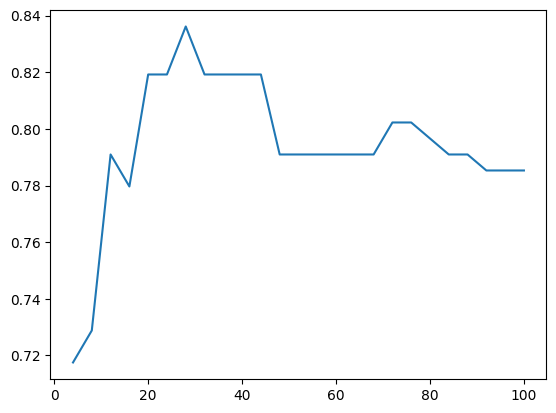

In [ ]:
import matplotlib.pyplot as plt
plt.plot(list(scores.keys()),list(scores.values()))

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_depth = 8, min_samples_leaf=1), n_estimators=25,
                            max_samples=100, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.score(X_test, y_test)

0.8870056497175142

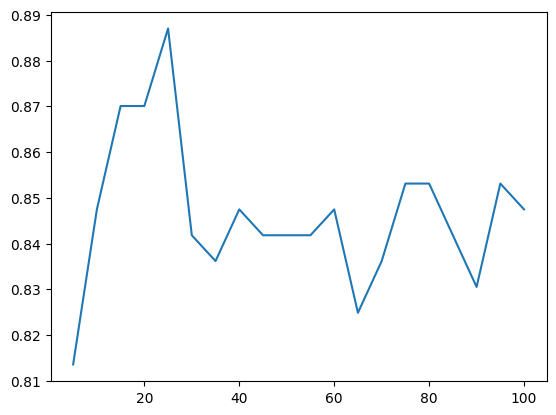

In [ ]:
scores:dict[int, int] = dict()
for i in range(5,105,5):
    bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=i,
                            max_samples=100, n_jobs=-1, random_state=42)
    bag_clf.fit(X_train, y_train)
    scores[i] = bag_clf.score(X_test, y_test)
plt.plot(list(scores.keys()),list(scores.values()))

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        # ("svc", make_pipeline(StandardScaler(), SVC(random_state=42, kernel = "poly", degree = 28, max_iter = 10_000)))
        ('svc', SVC(random_state=42, kernel = "poly", degree = 40, max_iter = 10_000))
    ]
)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.847457627118644

In [ ]:
for name, clf in voting_clf.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))

lr = 0.8870056497175142
rf = 0.768361581920904
svc = 0.7853107344632768


In [ ]:
log_reg = LogisticRegression(random_state=42, C = 205,max_iter=100)
# log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = 205))
log_reg.fit(X_train, y_train)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9096045197740112

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

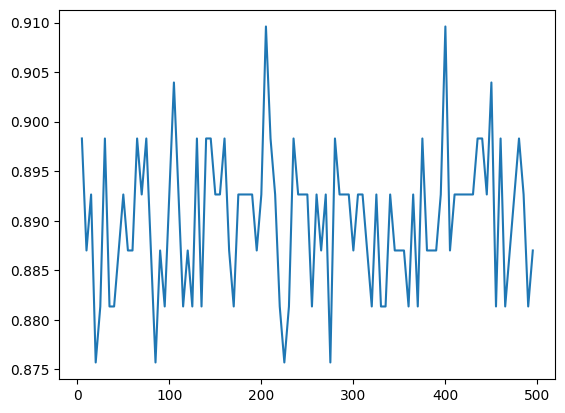

In [ ]:
scores: dict[int, float] = dict()
for i in range(5,500,5):
    log_reg = LogisticRegression(random_state=42, C = i)
    # log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = i))
    log_reg.fit(X_train, y_train)
    scores[i] = log_reg.score(X_test, y_test)
plt.plot(list(scores.keys()), list(scores.values()))

In [ ]:
from sklearn.svm import LinearSVC
# svm = make_pipeline(StandardScaler(), SVC(random_state=42, kernel = "poly", degree = 50, max_iter = 30_000))
svm = SVC(random_state=42, kernel = "poly", degree = 50, max_iter = 30_000, coef0 =.1)
#svm = SVC(random_state=42, kernel = "rbf", gamma = 50, C = .01)
# svm = make_pipeline(StandardScaler(), SVC(random_state=42, kernel = "rbf", gamma = 50, C = .01))
svm = LinearSVC(C = .005, random_state=42)
svm.fit(X_train, y_train)
svm.score(X_test, y_test)

0.8870056497175142

In [ ]:
scores[18],scores[29]

(0.8305084745762712, 0.8305084745762712)

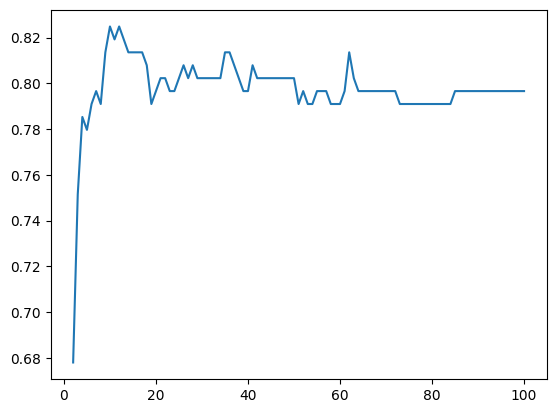

In [ ]:
scores = dict()
for i in range(2,101):
    rnd_clf = RandomForestClassifier(n_estimators=75, max_leaf_nodes=i,
                                    n_jobs=-1, random_state=42)
    rnd_clf.fit(X_train, y_train)
    scores[i] = rnd_clf.score(X_test, y_test)
plt.plot(list(scores.keys()), list(scores.values()))

In [ ]:
# BaggingClassifier(DecisionTreeClassifier(), n_estimators=25,
#                            max_samples=100, n_jobs=-1, random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=500, max_samples=100, max_leaf_nodes=20,
                                    n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
rnd_clf.score(X_test, y_test)

0.7796610169491526

In [ ]:
# best combo so far
# 5 estimators, min samples 10 - .8136

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
ex_clf = ExtraTreesClassifier(n_estimators = 5, min_samples_leaf=10, max_depth =15, n_jobs = -1, random_state = 42)
ex_clf.fit(X_train, y_train)
ex_clf.score(X_test, y_test)

0.8135593220338984

In [ ]:
# best combo so far
# max depth = 3, n_estimators = 30 - .8757

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=3), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)
ada_clf.score(X_test, y_test)

0.8757062146892656

## ensemble

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, C = 205,max_iter=100)),
        ('svc', LinearSVC(C = .005, random_state=42)),
        ('bag', BaggingClassifier(DecisionTreeClassifier(), n_estimators=25, max_samples=100, n_jobs=-1, random_state=42)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=3),
                                            n_estimators=30,
                                            learning_rate=0.5,
                                            random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.903954802259887

In [ ]:
for name, clf in voting_clf.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))

lr = 0.9096045197740112
svc = 0.8870056497175142
bag = 0.8870056497175142
ada = 0.8757062146892656


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbrt_best = GradientBoostingRegressor(
    max_depth=2, learning_rate=0.05, n_estimators=500,
    n_iter_no_change=10, random_state=42)
gbrt_best.fit(X, y)
gbrt_best.n_estimators_

96

## first round predicting

In [ ]:
X_64 = dat.loc[dat["round"] == 64,]
y_64 =X_64["win"]
X_64 = X_64[[cols for cols in X_64.columns if cols not in ["win","team1","team2","season","round"]]]

In [ ]:
m = len(X_64)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_64.iloc[train_labels]
y_train = y_64.iloc[train_labels]

X_test = X_64.iloc[test_labels]
y_test = y_64.iloc[test_labels]

len(X_train), len(X_test)

(358, 90)

In [ ]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(DecisionTreeClassifier(),
                        n_estimators=90,
                        max_samples=190,
                        n_jobs=-1,
                        random_state=42)
bag.fit(X_train, y_train)
bag.score(X_test, y_test)

0.9222222222222223

In [ ]:
best_combo = [0,0,0]
for n in range(5,55,5):
    for m in range(5,105,5):
        bag = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=n,
                            max_samples=m,
                            n_jobs=-1,
                            random_state=42)
        bag.fit(X_train, y_train)
        score = bag.score(X_test, y_test)
        if score > best_combo[2]:
            best_combo = [n,m, score]

In [ ]:
best_combo

[20, 80, 0.9222222222222223]

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
def hyperparamter_hunt(lo, hi, step = 1):
    scores = dict()
    for i in range(lo,hi,step):
        log_reg = LogisticRegression(random_state=42, C = i, max_iter=100)
        # log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = i, max_iter=100))
        log_reg.fit(X_train, y_train)
        scores[i] = log_reg.score(X_test, y_test)
    plt.plot(list(scores.keys()), list(scores.values()))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

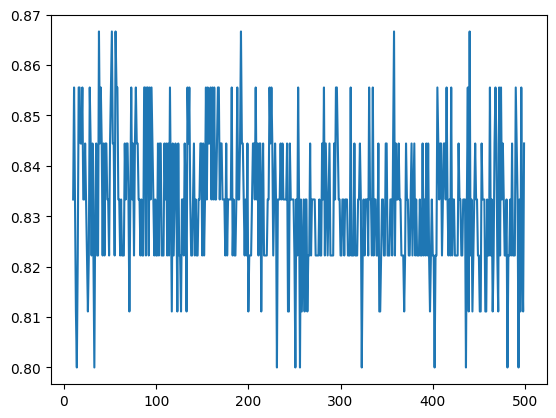

In [ ]:
hyperparamter_hunt(10,500,1)

In [ ]:
log_reg = LogisticRegression(random_state=42, C = 38, max_iter=80)
log_reg.fit(X_train, y_train)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8666666666666667

best = .00125

In [ ]:
from sklearn.svm import LinearSVC
svc = LinearSVC(C = .0008, random_state=42)
svc.fit(X_train, y_train)
svc.score(X_test, y_test)

0.8666666666666667

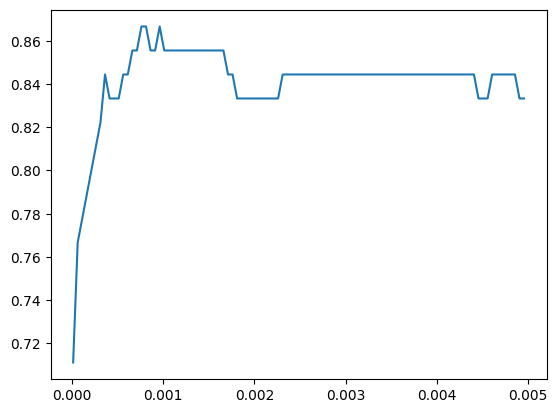

In [ ]:
scores = dict()
for i in range(1,501,5):
    svc = LinearSVC(C = i/100000, random_state=42)
    svc.fit(X_train, y_train)
    scores[i/100000] = svc.score(X_test, y_test)
plt.plot(list(scores.keys()), list(scores.values()))

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=8),
                                            n_estimators=24,
                                            learning_rate=0.5,
                                            random_state=42)
ada.fit(X_train, y_train)
ada.score(X_test, y_test)

0.9111111111111111

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
ex_clf = ExtraTreesClassifier(n_estimators = 17, min_samples_leaf=1, max_depth =30, n_jobs = -1, random_state = 42)
ex_clf.fit(X_train, y_train)
ex_clf.score(X_test, y_test)

0.8333333333333334

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
rnd_clf = RandomForestClassifier(n_estimators=10, max_samples=100, max_leaf_nodes=20,
                                    n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
rnd_clf.score(X_test, y_test)

0.7888888888888889

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
# svc = SVC(degree = 9, kernel = "poly", C = 1, coef0 =.01)
svc = make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))
svc.fit(X_train, y_train)
svc.score(X_test, y_test)

0.8666666666666667

In [ ]:
from sklearn.linear_model import SGDClassifier
# sgd = SGDClassifier(penalty = "l1", alpha = 4)
sgd = make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))
sgd.fit(X_train, y_train)
sgd.score(X_test, y_test)

0.9111111111111111

In [ ]:
voting_clf1 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))),
        # ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        #('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, max_samples=80, n_jobs=-1, random_state=42)),
        #("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=8),
                                            n_estimators=24,
                                            learning_rate=0.5,
                                            random_state=42))
    ]
)
voting_clf1.fit(X_train, y_train)
voting_clf1.score(X_test, y_test)

0.9333333333333333

In [ ]:
for name, clf in voting_clf1.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))

sgd = 0.9111111111111111
bag = 0.9222222222222223
ada = 0.9111111111111111


## second round predicting

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# y = dat["win"]

X_32 = dat.loc[dat["round"] == 32,]
y_32 =X_32["win"]
X_32 = X_32[[cols for cols in X_32.columns if cols not in ["win","team1","team2","season","round"]]]

m = len(X_32)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_32.iloc[train_labels]
y_train = y_32.iloc[train_labels]

X_test = X_32.iloc[test_labels]
y_test = y_32.iloc[test_labels]

len(X_train), len(X_test)

(179, 45)

In [ ]:
voting_clf1_32 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0699, random_state = 42))),
        #('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        #('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=26,
                  max_samples=80,
                  n_jobs=-1,
                  random_state=42)),
        #("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        #('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=26, learning_rate=0.5, random_state=42))
    ]
)
voting_clf1_32.fit(X_train, y_train)
for name, clf in voting_clf1_32.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf1_32.score(X_test, y_test)

sgd = 0.8666666666666667
bag = 0.9111111111111111


0.8666666666666667

In [ ]:
BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=26,
                  max_samples=80,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)

0.9111111111111111

In [ ]:
AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                            n_estimators=26,
                                            learning_rate=0.5,
                                            random_state=42
                   ).fit(X_train, y_train).score(X_test, y_test)

0.8444444444444444

In [ ]:
LogisticRegression(random_state=42, C = 410, max_iter=80).fit(X_train, y_train).score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8

## third round (s16) training

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# y = dat["win"]

X_16 = dat.loc[dat["round"] == 16,]
y_16 =X_16["win"]
X_16 = X_16[[cols for cols in X_16.columns if cols not in ["win","team1","team2","season","round"]]]

m = len(X_16)
spl: float = .75
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_16.iloc[train_labels]
y_train = y_16.iloc[train_labels]

X_test = X_16.iloc[test_labels]
y_test = y_16.iloc[test_labels]

len(X_train), len(X_test)

(84, 28)

In [ ]:
best = 0
for n in range(10,36):
    for m in range(22,84):
        score = BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=n,
                  max_samples=m,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
        if score > best:
            best = score
            print(f"{n} estimators, {m} max samples -> {score}")

10 estimators, 22 max samples -> 0.7142857142857143
10 estimators, 41 max samples -> 0.75
10 estimators, 43 max samples -> 0.7857142857142857
10 estimators, 65 max samples -> 0.8214285714285714
10 estimators, 71 max samples -> 0.8571428571428571
11 estimators, 70 max samples -> 0.8928571428571429
11 estimators, 72 max samples -> 0.9642857142857143


In [ ]:
BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=11,
                  max_samples=72,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)

0.9642857142857143

In [ ]:
best

0.8571428571428571

In [ ]:
# c= 410

In [ ]:
best = 0
for C in range(1,1001):
    # score = LogisticRegression(random_state=42, C = C, max_iter=800).fit(X_train, y_train).score(X_test, y_test)
    score = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = C, max_iter=50)).fit(X_train, y_train).score(X_test, y_test)
    if best < score:
        best = score
        print(f"C = {C} -> {score}")
    if C % 100 == 0:
        print(f"C = {C}")

C = 1 -> 0.8571428571428571
C = 100
C = 200
C = 300
C = 400
C = 500
C = 600
C = 700
C = 800
C = 900
C = 1000


In [ ]:
LogisticRegression(random_state=42, C = 73, max_iter=800).fit(X_train, y_train).score(X_test, y_test)

0.9285714285714286

In [ ]:
best = 0
for m in range(1,11):
    for n in range(1,21):
        for lr in range(1,9):
            score = AdaBoostClassifier(DecisionTreeClassifier(max_depth=m),
                                                        n_estimators=n,
                                                        learning_rate=lr/10,
                                                        random_state=42
                              ).fit(X_train, y_train).score(X_test, y_test)
            if best < score:
                best = score
                print(f"max depth = {m}, n estimators = {n}, lr = {lr/10} -> {score}")
    print(f"m = {m}")

max depth = 1, n estimators = 1, lr = 0.1 -> 0.6785714285714286
max depth = 1, n estimators = 3, lr = 0.3 -> 0.9285714285714286
max depth = 1, n estimators = 9, lr = 0.8 -> 0.9642857142857143
m = 1
m = 2
m = 3
m = 4
m = 5
m = 6
m = 7
m = 8
m = 9
m = 10


In [ ]:
AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=9,
                                                        learning_rate=.8,
                                                        random_state=42
                              ).fit(X_train, y_train).score(X_test, y_test)

0.9642857142857143

In [ ]:
make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0699, random_state = 42)).fit(X_train, y_train).score(X_test, y_test)

0.9642857142857143

In [ ]:
make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 14,random_state=42)).fit(X_train, y_train).score(X_test, y_test)

0.9285714285714286

In [ ]:
LinearSVC(C = .0075, random_state=42, max_iter=100000).fit(X_train, y_train).score(X_test, y_test)

0.8928571428571429

In [ ]:
voting_clf_16 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0699, random_state = 42))),
        ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 14,random_state=42))),
        #('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=11,
                  max_samples=72,
                  n_jobs=-1,
                  random_state=42)),
        ("lr", LogisticRegression(random_state=42, C = 73, max_iter=800)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=9,
                                                        learning_rate=.8,
                                                        random_state=42
                              ))
    ]
)
voting_clf_16.fit(X_train, y_train)
for name, clf in voting_clf_16.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf_16.score(X_test, y_test)

sgd = 0.9642857142857143
svc = 0.9285714285714286
bag = 0.9642857142857143
lr = 0.9285714285714286
ada = 0.9642857142857143


0.9642857142857143

## fourth round (e8) training

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# y = dat["win"]

X_8 = dat.loc[dat["round"] == 8,]
y_8 =X_8["win"]
X_8 = X_8[[cols for cols in X_8.columns if cols not in ["win","team1","team2","season","round"]]]

m = len(X_8)
spl: float = .7
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_8.iloc[train_labels]
y_train = y_8.iloc[train_labels]

X_test = X_8.iloc[test_labels]
y_test = y_8.iloc[test_labels]

len(X_train), len(X_test)

(39, 17)

In [ ]:
ada_8 = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=9,
                                                        learning_rate=.8,
                                                        random_state=42
                              )
ada_8.fit(X_train, y_train).score(X_test, y_test)

1.0

In [ ]:
voting_clf_8 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0699, random_state = 42))),
        ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 14,random_state=42))),
        #('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=11,
                  max_samples=38,
                  n_jobs=-1,
                  random_state=42)),
        ("lr", LogisticRegression(random_state=42, C = 73, max_iter=800)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=9,
                                                        learning_rate=.8,
                                                        random_state=42
                              ))
    ]
)
voting_clf_8.fit(X_train, y_train)
for name, clf in voting_clf_8.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf_8.score(X_test, y_test)

sgd = 0.75
svc = 0.75
bag = 0.75
lr = 0.6666666666666666
ada = 0.9166666666666666


0.75

## fifth round (f4) training

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# y = dat["win"]

X_4 = dat.loc[dat["round"] == 4,]
y_4 =X_4["win"]
X_4 = X_4[[cols for cols in X_4.columns if cols not in ["win","team1","team2","season","round"]]]

m = len(X_4)
spl: float = .75
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_4.iloc[train_labels]
y_train = y_4.iloc[train_labels]

X_test = X_4.iloc[test_labels]
y_test = y_4.iloc[test_labels]

len(X_train), len(X_test)

(21, 7)

In [ ]:
voting_clf_8 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0699, random_state = 42))),
        ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 14,random_state=42))),
        #('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(max_depth = 5, min_samples_leaf=1),
                  n_estimators=11,
                  max_samples=15,
                  n_jobs=-1,
                  random_state=42)),
        ("lr", LogisticRegression(random_state=42, C = 4, max_iter=800)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=9,
                                                        learning_rate=.8,
                                                        random_state=42
                              ))
    ]
)
voting_clf_8.fit(X_train, y_train)
for name, clf in voting_clf_8.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf_8.score(X_test, y_test)

sgd = 0.42857142857142855
svc = 0.2857142857142857
bag = 0.5714285714285714
lr = 0.14285714285714285
ada = 0.5714285714285714


0.2857142857142857

In [ ]:
AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=26,
                                                        learning_rate=.5,
                                                        random_state=42
                              ).fit(X_train, y_train).score(X_test, y_test)

0.5714285714285714

In [ ]:
best_ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=12,
                                                        learning_rate=.75,
                                                        random_state=42
                              ).fit(X_train, y_train)

In [ ]:
best= 0
for n in range(1,50):
    for lr in range(1,100):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                                        n_estimators=n,
                                                        learning_rate=lr/100,
                                                        random_state=42
                              ).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
            best = score
            print(f"n = {n}, lr = {lr} -> score = {score}")

n = 1, lr = 1 -> score = 0.5714285714285714
n = 5, lr = 12 -> score = 0.7142857142857143
n = 12, lr = 75 -> score = 0.8571428571428571


KeyboardInterrupt: 

In [ ]:
BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=1,
                  max_samples=17,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
best= 0
for n in range(1,50):
    for m in range(1,20):
        score = BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=n,
                  max_samples=m,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
            best = score
            print(f"n = {n}, m = {m} -> score = {score}")

n = 1, m = 1 -> score = 0.2857142857142857
n = 1, m = 9 -> score = 0.7142857142857143
n = 7, m = 17 -> score = 0.8571428571428571


In [ ]:
best_bag = BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=7,
                  max_samples=17,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train)

In [ ]:
vote_4 = VotingClassifier(estimators=[
    ("bag" , best_bag),
    ("ada" , best_ada)
])
vote_4.fit(X_train, y_train)
for name, clf in vote_4.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
vote_4.score(X_test, y_test)

bag = 0.8571428571428571
ada = 0.8571428571428571


0.7142857142857143

In [ ]:
LinearSVC(random_state = 42, C = 100).fit(X_train, y_train).score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.14285714285714285

In [ ]:
LogisticRegression(random_state=42, max_iter=800).fit(X_train, y_train).score(X_test, y_test)

0.6666666666666666

In [ ]:
# .fit(X_train, y_train).score(X_test, y_test)

## sixth round (final)

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
# y = dat["win"]

X_2 = dat.loc[dat["round"] == 2,]
y_2 =X_2["win"]
X_2 = X_2[[cols for cols in X_4.columns if cols not in ["win","team1","team2","season","round"]]]

m = len(X_2)
spl: float = .7
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_2.iloc[train_labels]
y_train = y_2.iloc[train_labels]

X_test = X_2.iloc[test_labels]
y_test = y_2.iloc[test_labels]

len(X_train), len(X_test)

(9, 5)

In [ ]:
BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=1,
                  max_samples=1,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
best= 0
for n in range(1,50):
    for m in range(1,10):
        score = BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=n,
                  max_samples=m,
                  n_jobs=-1,
                  random_state=42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
            best = score
            print(f"n = {n}, m = {m} -> score = {score}")

n = 1, m = 1 -> score = 1.0


KeyboardInterrupt: 

In [ ]:
best_bag = BaggingClassifier(DecisionTreeClassifier(max_depth = 1, min_samples_leaf=4),
                  n_estimators=1,
                  max_samples=1,
                  n_jobs=-1,
                  random_state=42)
best_bag.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                   min_samples_leaf=4),
                  max_samples=1, n_estimators=1, n_jobs=-1, random_state=42)

## random forest

In [ ]:
X_64 = X_64[[cols for cols in X_64.columns if cols not in ["win","team1","team2","season","round","team1_seed","team2_seed"]]]
m = len(X_64)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X_64.iloc[train_labels]
y_train = y_64.iloc[train_labels]

X_test = X_64.iloc[test_labels]
y_test = y_64.iloc[test_labels]

len(X_train), len(X_test)

(358, 90)

In [ ]:
voting_clf2 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))),
        ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        ('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, max_samples=80, n_jobs=-1, random_state=42)),
        ("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=8), n_estimators=24, learning_rate=0.5, random_state=42))

    ]
)
voting_clf2.fit(X_train, y_train)
voting_clf2.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9

In [ ]:
for name, clf in voting_clf2.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))

sgd = 0.9111111111111111
svc = 0.8555555555555555
linear_svc = 0.8555555555555555
bag = 0.8777777777777778
lr = 0.8222222222222222
ada = 0.8444444444444444


## first four training

In [ ]:
# # removing round made it worse
#X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season","team1_seed","team2_seed"]]]
X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season"]]]
y = dat["win"]

In [ ]:
X.loc[X["team1_seed"] == X["team2_seed"],]

,round,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,opp_FG%_team1,opp_3P%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
62,2,1,1,26.70,8.70,0.497,0.358,0.743,0.392,0.312,...,2.461538,3.571960,9.435897,13.692514,20.307692,29.468671,0.346831,0.757221,0.566902,0.412852
251,2,1,1,24.83,7.40,0.486,0.413,0.708,0.433,0.329,...,2.781250,3.715455,14.406250,19.245220,19.250000,25.715956,0.331807,0.768574,0.530394,0.357761
375,4,1,1,26.64,10.24,0.500,0.401,0.779,0.428,0.317,...,3.538462,5.023091,12.846154,18.236003,16.820513,23.877881,0.411665,0.689726,0.491514,0.270499
440,2,1,1,24.84,11.76,0.466,0.355,0.701,0.413,0.340,...,3.076923,4.337140,12.179487,17.167847,19.743590,27.829984,0.328509,0.741718,0.519795,0.390351
501,4,2,2,24.08,9.71,0.483,0.362,0.782,0.403,0.339,...,3.189189,4.444235,12.648649,17.626289,18.756757,26.138129,0.407191,0.699654,0.504698,0.329888
565,4,1,1,28.72,8.67,0.468,0.349,0.726,0.354,0.271,...,2.100000,3.509395,9.450000,15.792277,18.075000,30.205864,0.373522,0.762780,0.542044,0.361702
566,2,1,1,24.97,9.87,0.502,0.387,0.699,0.422,0.314,...,2.100000,3.509395,9.450000,15.792277,18.075000,30.205864,0.373522,0.762780,0.542044,0.361702
691,4,4,4,20.30,8.57,0.439,0.335,0.675,0.369,0.283,...,3.179487,4.910040,12.051282,18.610637,15.487179,23.916648,0.340265,0.676998,0.502150,0.284071
754,4,2,2,23.95,9.07,0.476,0.334,0.709,0.407,0.325,...,3.512821,5.200820,13.666667,20.233847,18.410256,27.256852,0.296450,0.686846,0.517995,0.397879
880,4,5,5,15.33,8.16,0.471,0.344,0.685,0.406,0.328,...,3.157895,4.910612,13.921053,21.647612,20.500000,31.878053,0.398221,0.726083,0.515197,0.468864


In [ ]:
m = len(X)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

X_train= X.iloc[train_labels]
y_train = y.iloc[train_labels]

X_test = X.iloc[test_labels]
y_test = y.iloc[test_labels]

len(X_train), len(X_test)

(705, 177)

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))),
        # ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        # ('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, max_samples=80, n_jobs=-1, random_state=42)),
        # ("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=8),
                                            n_estimators=24,
                                            learning_rate=0.5,
                                            random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)
for name, clf in voting_clf.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf.score(X_test, y_test)

sgd = 0.8135593220338984
bag = 0.7740112994350282
ada = 0.7740112994350282


0.8022598870056498

In [ ]:
AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                            n_estimators=17,
                                            learning_rate=0.5,
                                            random_state=42
                   ).fit(X_train, y_train).score(X_test, y_test)

0.847457627118644

In [ ]:
best_combo = [0,0,0.0,0]
for m in range(1,20):
    for n in range(1,50):
        for lr in range(1,100):
            score = AdaBoostClassifier(DecisionTreeClassifier(max_depth=m),
                                                n_estimators=n,
                                                learning_rate=lr/100,
                                                random_state=42
                        ).fit(X_train, y_train).score(X_test, y_test)
            if score > best_combo[3]:
                best_combo = [m,n, lr/100, score]
best_combo

KeyboardInterrupt: 

In [ ]:
best_combo = [0,0,0]
for n in range(50,105,5):
    for m in range(95,255,5):
        score = BaggingClassifier(DecisionTreeClassifier(),
                  n_estimators=n,
                  max_samples=m,
                  n_jobs=-1,
                  random_state=42
                  ).fit(X_train, y_train).score(X_test, y_test)
        if score > best_combo[2]:
            best_combo = [n,m, score]
best_combo

[60, 95, 0.8418079096045198]

In [ ]:
BaggingClassifier(DecisionTreeClassifier(),
                  n_estimators=60,
                  max_samples=95,
                  n_jobs=-1,
                  random_state=42
                  ).fit(X_train, y_train).score(X_test, y_test)

0.8022598870056498

In [ ]:
# alpha = .0256 - .8418

In [ ]:
best_combo = [0,0]
for a in range(1,260):
    score = make_pipeline(
        StandardScaler(),
                          SGDClassifier(penalty = "l1",
                                        alpha = a/10000,
                                        random_state = 42
                                        )
                          ).fit(X_train, y_train).score(X_test, y_test)
    if score > best_combo[1]:
        print(best_combo)
        best_combo = [a/10000, score]
    if a % 200 == 0:
        print(f"current alpha: {a}")
best_combo

[0, 0]
[0.0001, 0.7740112994350282]
[0.0002, 0.7796610169491526]
current alpha: 200


[0.0004, 0.7853107344632768]

In [ ]:
#.0012

In [ ]:
make_pipeline(
        StandardScaler(), LinearSVC(C = 12, random_state=42)).fit(X_train, y_train).score(X_test, y_test)

0.8192090395480226

## four factors

In [ ]:
X_64 = dat.loc[dat["round"] == 64,]
y_64 =X_64["win"]
# X_64 = X_64[[cols for cols in X_64.columns if cols not in ["win","team1","team2","season","round"]]]
Xff_64 = X_64[["srs_team1","sos_team1","srs_team2","sos_team2","eFG_team1","FT_FGA_team1","TOV_pct_team1","ORB_pct_team1",
      "eFG_team2","FT_FGA_team2","TOV_pct_team2","ORB_pct_team2"]]

In [ ]:
m = len(Xff_64)
spl: float = .8
np.random.seed(42)
train_labels = np.random.choice(m, int(m*spl), replace = False)
test_labels = np.array(list(i for i in range(m) if i not in train_labels))
len(train_labels), len(test_labels)

Xff_train= Xff_64.iloc[train_labels]
yff_train = y_64.iloc[train_labels]

Xff_test = Xff_64.iloc[test_labels]
yff_test = y_64.iloc[test_labels]

len(Xff_train), len(Xff_test)

(358, 90)

In [ ]:
voting_clf3 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))),
        ('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        ('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, max_samples=80, n_jobs=-1, random_state=42)),
        ("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=8), n_estimators=24, learning_rate=0.5, random_state=42))

    ]
)
voting_clf3.fit(Xff_train, yff_train)
for name, clf in voting_clf3.named_estimators_.items():
     print(name, "=", clf.score(Xff_test, yff_test))
voting_clf3.score(Xff_test, yff_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


sgd = 0.7111111111111111
svc = 0.7222222222222222
linear_svc = 0.7444444444444445
bag = 0.7111111111111111
lr = 0.7444444444444445
ada = 0.7444444444444445


0.7444444444444445

In [ ]:
BaggingClassifier(DecisionTreeClassifier(),
                  n_estimators=113,
                  max_samples=6,
                  n_jobs=-1,
                  random_state=42).fit(Xff_train, yff_train).score(Xff_test, yff_test)

0.6777777777777778

# model with diff dataset

In [ ]:
dat = pd.read_csv('database2.csv')
dat = dat.drop("Unnamed: 0", axis = 1)

In [ ]:
# removing round made it worse
# X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season","round","team1_seed","team2_seed"]]]
X = dat[[cols for cols in dat.columns if cols not in ["win","team1","team2","season","round"]]]
y = dat["win"]

In [ ]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
def manual_train_test(X, y, split: float):

    m = len(X)
    np.random.seed(42)
    train_labels = np.random.choice(m, int(m*split), replace = False)
    test_labels = np.array(list(i for i in range(m) if i not in train_labels))
    #len(train_labels), len(test_labels)

    X_train= X.iloc[train_labels]
    y_train = y.iloc[train_labels]

    X_test = X.iloc[test_labels]
    y_test = y.iloc[test_labels]

    # len(X_train), len(X_test)

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 42)
# X_train, X_test, y_train, y_test = manual_train_test(X, y, .8)

In [ ]:
rf_clf = RandomForestClassifier(n_estimators = 1500,
                       # max_samples = len(X_train),
                       max_leaf_nodes = 8,
                       oob_score = True,  # bootstrap = True,
                       n_jobs = -1, random_state = 42)
rf_clf.fit(X_train, y_train)
print(rf_clf.oob_score_)
rf_clf.score(X_test, y_test)

0.6916030534351145


0.6829268292682927

In [ ]:
# classifiers
# decision tree, svc, sgdclassifer, linear svc, logisitic

In [ ]:
dt = DecisionTreeClassifier(random_state = 42)
svc = SVC(random_state = 42)
lsvc = LinearSVC(random_state = 42)
logit = LogisticRegression(random_state = 42)
sgd = SGDClassifier(random_state = 42)

In [ ]:
clfs: list = [dt,svc,lsvc,logit,sgd]
for i in range(5):
    print(clfs[i])
    clfs[i].fit(X_train, y_train)
    print(clfs[i].score(X_test, y_test))
    print()

DecisionTreeClassifier(random_state=42)
0.6829268292682927

SVC(random_state=42)
0.6036585365853658

LinearSVC(random_state=42)
0.6890243902439024

LogisticRegression(random_state=42)
0.6707317073170732

SGDClassifier(random_state=42)
0.7073170731707317



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 1), n_estimators = 50, learning_rate = .5, random_state = 42)
ada.fit(X_train, y_train)
ada.score(X_test, y_test)

0.725609756097561

In [ ]:
from sklearn.ensemble import StackingClassifier
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
         ('rf', RandomForestClassifier(random_state=42)),
          ('svc', SVC(probability=True, random_state=42))     ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5  # number of cross-validation folds
    )
stacking_clf.fit(X_train, y_train)
stacking_clf.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.6707317073170732

In [ ]:
# best model without seed
dec1 = DecisionTreeClassifier(random_state = 42, max_depth = 3, max_leaf_nodes = 4, criterion = "gini")#.fit(X_train, y_train).score(X_test, y_test)

In [ ]:
# with seed
best = 0
avg_Score = 0
for d in range(1,6):
    # for mf in range(1,20):
        for mn in range(2,51):
            for mss in range(2,3):
                for msl in range(1,2):
                    score = DecisionTreeClassifier(random_state = 42,
                                                   max_depth = d,
                                                   max_features = None,
                                                   max_leaf_nodes = mn,
                                                   min_samples_split = mss,
                                                   min_samples_leaf = msl).fit(X_train, y_train).score(X_test, y_test)
                    avg_Score += score
                    if best < score:
                        best = score
                        print(f"{d} max depth, N/A max features, {mn} max nodes, {mss} min_samples_split, {msl} min samples leaf -> {score}")
        print(f"{d} avg score = {avg_Score/(49)}")
        avg_Score = 0

1 max depth, N/A max features, 2 max nodes, 2 min_samples_split, 1 min samples leaf -> 0.6463414634146342
1 avg score = 0.6463414634146334
2 max depth, N/A max features, 3 max nodes, 2 min_samples_split, 1 min samples leaf -> 0.7073170731707317
2 avg score = 0.7060726729716278
3 avg score = 0.6560477849676456
4 max depth, N/A max features, 7 max nodes, 2 min_samples_split, 1 min samples leaf -> 0.7195121951219512
4 avg score = 0.7004728720756603
5 avg score = 0.6836734693877554


In [ ]:
# best model without seed
ada1 = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 3, max_leaf_nodes = 4), n_estimators=6, learning_rate = .76, random_state = 42)# .fit(X_train, y_train).score(X_test, y_test)

In [ ]:
# with seed
AdaBoostClassifier(DecisionTreeClassifier(max_depth = 4, max_leaf_nodes = 7), n_estimators=12, learning_rate = 0.28, random_state = 42).fit(X_train, y_train).score(X_test, y_test)

0.6951219512195121

In [ ]:
# with seed
# 12 estimators, lr = 0.28 -> 0.774390243902439
best = 0
for n in range(35,501,5):
    avg_Score = 0
    if n % 50 == 0:
        print(f"n = {n}")
    for lr in range(1,100,5):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 4, max_leaf_nodes = 7), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_train, y_train).score(X_test, y_test)
        avg_Score += score
        if best < score:
            best = score
            print(f"{n} estimators, lr = {lr/100} -> {score}")
    print(f"n = {n}, avg score = {avg_Score/20}")

35 estimators, lr = 0.01 -> 0.7195121951219512
35 estimators, lr = 0.06 -> 0.7378048780487805
n = 35, avg score = 0.7003048780487806
n = 40, avg score = 0.6960365853658537
n = 45, avg score = 0.6969512195121952
n = 50
n = 50, avg score = 0.6917682926829267
n = 55, avg score = 0.6917682926829268
n = 60, avg score = 0.688109756097561


KeyboardInterrupt: 

In [ ]:
best = 0
for n in range(11,501):
    if n % 50 == 0:
        print(f"n = {n}")
    for lr in range(75,81):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth = 3, max_leaf_nodes = 4), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
            best = score
            print(f"{n} estimators, lr = {lr/100} -> {score}")

11 estimators, lr = 0.75 -> 0.7195121951219512
11 estimators, lr = 0.76 -> 0.7378048780487805
11 estimators, lr = 0.78 -> 0.7560975609756098
11 estimators, lr = 0.79 -> 0.7682926829268293
n = 50


KeyboardInterrupt: 

In [ ]:
best = 0
for n in range(1,51):
    if n % 10 == 0:
        print(f"n = {n}")
    for ms in range(1,501):
        score = BaggingClassifier(DecisionTreeClassifier(max_depth = 4, max_leaf_nodes = 7), n_estimators=n, max_samples=ms, n_jobs=-1, random_state=42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
                best = score
                print(f"{n} estimators, ms = {ms} -> {score}")

1 estimators, ms = 1 -> 0.6036585365853658
1 estimators, ms = 7 -> 0.6097560975609756
1 estimators, ms = 28 -> 0.6158536585365854
1 estimators, ms = 62 -> 0.6524390243902439
1 estimators, ms = 67 -> 0.6707317073170732
1 estimators, ms = 71 -> 0.6951219512195121
2 estimators, ms = 199 -> 0.7012195121951219
2 estimators, ms = 239 -> 0.7073170731707317
2 estimators, ms = 245 -> 0.725609756097561
n = 10
10 estimators, ms = 458 -> 0.7317073170731707


KeyboardInterrupt: 

In [ ]:
bag1 = BaggingClassifier(DecisionTreeClassifier(max_depth = 3, max_leaf_nodes = 4), n_estimators=14, max_samples=176, n_jobs=-1, random_state=42)#.fit(X_train, y_train).score(X_test, y_test)

In [ ]:
best= .6890243902439024 #31
for n in range(101,500):
    score= RandomForestClassifier(n_estimators = n,max_depth = 3, max_leaf_nodes=4, random_state = 42).fit(X_train, y_train).score(X_test, y_test)
    if best < score:
        best = score
        print(f"{n} estimators -> {score}")

In [ ]:
# 2 degree, C = 4, coef = 70 -> 0.75
best = 0
for d in range(5,100):
    print(f"degree = {d}")
    avg_score = 0
    for c in range(1,21,1):
        for co in range(0,110,10):
            score = SVC(kernel = "poly", degree =d, coef0 = co/100, C= c).fit(X_train, y_train).score(X_test, y_test)
            avg_score += score
            if best < score:
                best = score
                print(f"{d} degree, C = {c}, coef = {co/100} -> {score}")
    print(f"degree {d}: avg score = {avg_score/(20*11)}")

degree = 5
5 degree, C = 1, coef = 0.0 -> 0.7317073170731707
5 degree, C = 1, coef = 0.1 -> 0.7378048780487805
degree 5: avg score = 0.6855598669623052
degree = 6
degree 6: avg score = 0.6871674057649654
degree = 7
degree 7: avg score = 0.6759423503325943
degree = 8
degree 8: avg score = 0.652217294900222
degree = 9
degree 9: avg score = 0.6250277161862524
degree = 10


KeyboardInterrupt: 

In [ ]:
svc1 = SVC(kernel = "poly", degree =4, coef0 = 0, C= 1)#.fit(X_train, y_train).score(X_test, y_test)

In [ ]:
# 2 degree, C = 4, coef = 70 -> 0.75
best = 0
for d in range(1,100):
    print(f"degree = {d}")
    avg_score = 0
    for c in range(1,51,1):
        for co in range(0,110,10):
            score = make_pipeline(StandardScaler(), SVC(kernel = "poly", degree =d, coef0 = co/100, C= c)).fit(X_train, y_train).score(X_test, y_test)
            avg_score += score
            if best < score:
                best = score
                print(f"{d} degree, C = {c}, coef = {co/100} -> {score}")
    print(f"degree {d}: avg score = {avg_score/(c*11)}")

degree = 1
1 degree, C = 1, coef = 0.0 -> 0.6951219512195121
1 degree, C = 2, coef = 0.0 -> 0.7134146341463414
degree 1: avg score = 0.6768625277161896
degree = 2
degree 2: avg score = 0.6266075388026577
degree = 3
degree 3: avg score = 0.6252882483370287
degree = 4
degree 4: avg score = 0.6180155210643
degree = 5
degree 5: avg score = 0.6371175166297105
degree = 6
degree 6: avg score = 0.6385365853658503
degree = 7
degree 7: avg score = 0.6482594235033223
degree = 8
degree 8: avg score = 0.6465188470066475
degree = 9
degree 9: avg score = 0.6442017738359177
degree = 10
degree 10: avg score = 0.6399999999999988
degree = 11


KeyboardInterrupt: 

In [ ]:
# 2 degree, C = 4, coef = 70 -> 0.75
best = 0
for g in range(1,10):
    print(f"degree = {g}")
    avg_score = 0
    for c in range(1,50,1):
        #for co in range(0,110,10):
        score = make_pipeline(StandardScaler(), SVC(kernel = "rbf", gamma =g, C = c/1000)).fit(X_train, y_train).score(X_test, y_test)
        avg_score += score
        if best < score:
            best = score
            print(f"{g} gamma, C = {c} -> {score}")
    print(f"gamma {g}: avg score = {avg_score/(c)}")

degree = 1
1 gamma, C = 1 -> 0.6036585365853658
gamma 1: avg score = 0.6036585365853666
degree = 2
gamma 2: avg score = 0.6036585365853666
degree = 3
gamma 3: avg score = 0.6036585365853666
degree = 4
gamma 4: avg score = 0.6036585365853666
degree = 5


KeyboardInterrupt: 

In [ ]:
votclf_all = VotingClassifier(estimators = [
    ("svc", svc1),
    ("bag1", bag1),
    ("ada1", ada1),
    #("dec1", dec1)
])
votclf_all.fit(X_train, y_train)
for name, clf in votclf_all.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
votclf_all.score(X_test, y_test)

svc = 0.75
bag1 = 0.7682926829268293
ada1 = 0.7682926829268293


0.7804878048780488

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
y_pred = votclf_all.predict(X_test)
recall_score(y_test, y_pred), f1_score(y_test, y_pred), precision_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(0.8888888888888888,
 0.8301886792452831,
 0.7787610619469026,
 np.float64(0.7521367521367521))

## first round predicting

In [ ]:
X_64 = dat.loc[dat["round"] == 64,]
y_64 =X_64["win"]
X_64 = X_64[[cols for cols in X_64.columns if cols not in ["win","team1","team2","season","round"]]]
# X_64 = X_64[[cols for cols in X_64.columns if cols not in ["win","team1","team2","season","round", "team1_seed", "team2_seed"]]]

In [ ]:
X_64train, X_64test, y_64train, y_64test = train_test_split(X_64, y_64, test_size = .2, random_state = 42)

In [ ]:
len(X_64train)

332

In [ ]:
BaggingClassifier(DecisionTreeClassifier(),
                        n_estimators=90,
                        max_samples=190,
                        n_jobs=-1,
                        random_state=42).fit(X_64train, y_64train).feature_importance_ #.score(X_64test, y_64test)

AttributeError: 'BaggingClassifier' object has no attribute 'feature_importance_'

In [ ]:
# n = 5, 37 max samples -> 0.7619047619047619
# n = 5, 99 max samples -> 0.8333333333333334
best = 0
for n in range(1,11):
    avg_score = 0
    print(f"n = {n}")
    for ms in range(60,201):
        score = BaggingClassifier(DecisionTreeClassifier(),
                        n_estimators=n,
                        max_samples=ms,
                        n_jobs=-1,
                        random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)
        avg_score += score
        if best < score:
            best = score
            print(f"n = {n}, {ms} max samples -> {score}")
    print(f"n = {n} -> avg_Score = {avg_score/140}")

n = 1
n = 1, 60 max samples -> 0.7380952380952381
n = 1, 61 max samples -> 0.7619047619047619
n = 1 -> avg_Score = 0.6307823129251696
n = 2
n = 2 -> avg_Score = 0.5912414965986393
n = 3
n = 3, 96 max samples -> 0.7857142857142857
n = 3, 98 max samples -> 0.8095238095238095
n = 3 -> avg_Score = 0.6715136054421764
n = 4
n = 4, 98 max samples -> 0.8214285714285714
n = 4 -> avg_Score = 0.6494047619047618
n = 5
n = 5, 99 max samples -> 0.8452380952380952
n = 5 -> avg_Score = 0.6924319727891157
n = 6
n = 6 -> avg_Score = 0.6826530612244903
n = 7
n = 7 -> avg_Score = 0.7043367346938768
n = 8
n = 8 -> avg_Score = 0.6966836734693873
n = 9
n = 9 -> avg_Score = 0.7050170068027206
n = 10
n = 10 -> avg_Score = 0.7031462585034005


In [ ]:
best = 0
for md in range(1,6):
    print(f"md = {md}")
    for mln in range(2,35):
        score = BaggingClassifier(DecisionTreeClassifier(max_depth=md, max_leaf_nodes=mln),
                        n_estimators=5,
                        max_samples=99,
                        n_jobs=-1,
                        random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)
        avg_score += score
        if best < score:
            best = score
            print(f"n = {md}, {mln} max samples -> {score}")

md = 1
n = 1, 2 max samples -> 0.7380952380952381
md = 2
n = 2, 3 max samples -> 0.7857142857142857
md = 3
md = 4
md = 5


In [ ]:
AdaBoostClassifier(DecisionTreeClassifier(max_depth =3, max_leaf_nodes=4), n_estimators=5, learning_rate = .72, random_state = 42).fit(X_64train, y_64train).score(X_64test, y_64test)

0.7619047619047619

In [ ]:
best = 0
for n in range(11,51):
    for lr in range(64,80):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth =3, max_leaf_nodes=4), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_64train, y_64train).score(X_64test, y_64test)
        if best < score:
                    best = score
                    print(f"{n} estimators, lr = {lr/100} -> {score}")

11 estimators, lr = 0.64 -> 0.6428571428571429
11 estimators, lr = 0.67 -> 0.75
12 estimators, lr = 0.74 -> 0.7857142857142857


KeyboardInterrupt: 

In [ ]:
#w/o seed
AdaBoostClassifier(DecisionTreeClassifier(max_depth =3, max_leaf_nodes=4), n_estimators=9, learning_rate = .78, random_state = 42)

In [ ]:
# with seed
# depth 3, nodes 3, 5 estimators, lr = 0.17 -> 0.7261904761904762
# depth 2, noes 2, 5 estimators, lr = 0.74 -> 0.75
# depth 4, nodes 4, 5 estimators, lr = 0.68 -> 0.7619047619047619
#d 5, n 5, 5 estimators, lr = 0.33 -> 0.7380952380952381
best = 0
for md in range(1,6):
    for mln in range(2, 6):
        for n in range(4,6,1):
            avg_Score = 0
            # if n % 5 == 0:
                # print(f"n = {n}")
            for lr in range(1,100,1):
                score = AdaBoostClassifier(DecisionTreeClassifier(max_depth = md, max_leaf_nodes = mln), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_64train, y_64train).score(X_64test, y_64test)
                avg_Score += score
                if best < score:
                    best = score
                    print(f"d = {md}, mln = {mln}, {n} estimators, lr = {lr/100} -> {score}")
                # elif score >= .75:
                  #  print(f"{n} estimators, lr = {lr/100} -> {score}")
            # print(f"n = {n}, avg score = {avg_Score/100}")

d = 1, mln = 2, 4 estimators, lr = 0.01 -> 0.6785714285714286
d = 1, mln = 2, 5 estimators, lr = 0.68 -> 0.7023809523809523
d = 1, mln = 2, 5 estimators, lr = 0.74 -> 0.75
d = 3, mln = 4, 5 estimators, lr = 0.68 -> 0.7619047619047619


KeyboardInterrupt: 

In [ ]:
# 0.8095238095238095
BaggingClassifier(DecisionTreeClassifier(),n_estimators=5,max_samples=100,n_jobs=-1,random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)
# BaggingClassifier(DecisionTreeClassifier(max_depth = 3, max_leaf_nodes = 4),n_estimators=5,max_samples=100,n_jobs=-1,random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)

0.7738095238095238

In [ ]:
best_combo = [0,0,0]
for n in range(1,11,1):
    for m in range(255,330,5):
        bag = BaggingClassifier(DecisionTreeClassifier(),
                            n_estimators=n,
                            max_samples=m,
                            n_jobs=-1,
                            random_state=42)
        bag.fit(X_64train, y_64train)
        score = bag.score(X_64test, y_64test)
        if score > best_combo[2]:
            best_combo = [n,m, score]

In [ ]:
best_combo

[9, 315, 0.7619047619047619]

In [ ]:
LogisticRegression(random_state=42, C = 1, max_iter=10).fit(X_64train, y_64train).score(X_64test, y_64test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7738095238095238

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

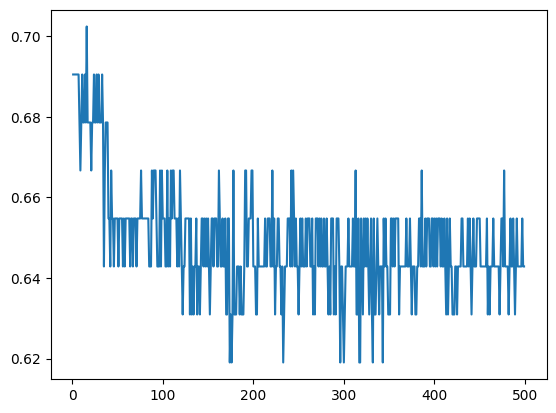

In [ ]:
scores = dict()
for i in range(1,500,1):
    # log_reg = LogisticRegression(random_state=42, C = i, max_iter =10)
    log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = i, max_iter=100))
    log_reg.fit(X_64train, y_64train)
    scores[i] = log_reg.score(X_64test, y_64test)
plt.plot(list(scores.keys()), list(scores.values()))

In [ ]:
LogisticRegression(random_state=42, C = 1, max_iter =10).fit(X_64train, y_64train).score(X_64test, y_64test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7738095238095238

In [ ]:
make_pipeline(StandardScaler() , LinearSVC(C =2, random_state=42)).fit(X_64train, y_64train).score(X_64test, y_64test)

0.6666666666666666

C = 0.0001, not scaled -> score 0.7380952380952381

In [ ]:
best = 0.738
for i in range(1,1001):
    score1 = make_pipeline(StandardScaler() , LinearSVC(C =i/10000, random_state=42)).fit(X_64train, y_64train).score(X_64test, y_64test)
    score2 = LinearSVC(C =i/10000, random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)
    if score1 > best:
        best = score1
        print(f"C = {i/10000}, scaled -> score {score1}")
    if score2 > best:
        best = score2
        print(f"C = {i/10000}, not scaled -> score {score2}")
    if score1 < .5 and score2 < .5:
        break

C = 0.0001, not scaled -> score 0.7380952380952381


In [ ]:
LinearSVC(C = .00011, random_state=42).fit(X_64train, y_64train).score(X_64test, y_64test)

0.75

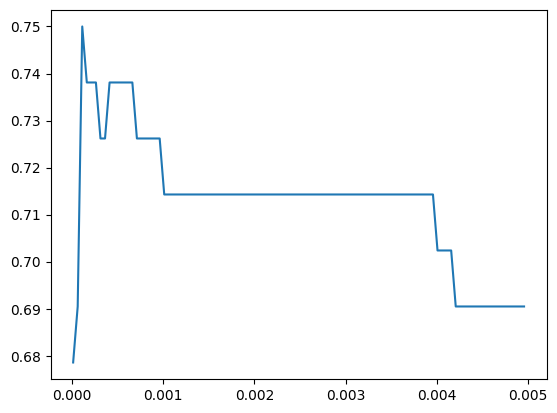

In [ ]:
scores = dict()
for i in range(1,501,5):
    svc = LinearSVC(C = i/100000, random_state=42)
    svc.fit(X_64train, y_64train)
    scores[i/100000] = svc.score(X_64test, y_64test)
plt.plot(list(scores.keys()), list(scores.values()))

0.0165, 0.7619047619047619 scaled l1\
.0014 0.77 < scaled l2\
.2005 .8 < unscaled l1


In [ ]:
list(inds for inds in scores.keys() if scores[inds] > .79)

[0.0053, 0.0054, 0.0087, 0.0144, 0.0148, 0.0156, 0.0171]

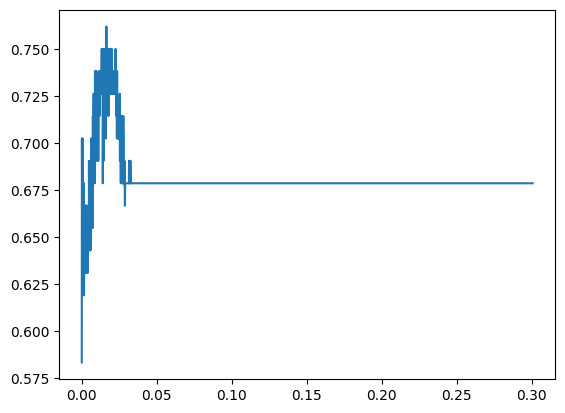

In [ ]:
scores = dict()
for i in range(1,3006):
    sgd = make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = i/10000, random_state = 42))
    # sgd = SGDClassifier(penalty = "l1", alpha = i/10000, random_state = 42)
    sgd.fit(X_64train, y_64train)
    scores[i/10000] = sgd.score(X_64test, y_64test)
plt.plot(list(scores.keys()), list(scores.values()))

In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=21, max_samples=100, max_leaf_nodes=7,
                                    n_jobs=-1, random_state=42)
rnd_clf.fit(X_64train, y_64train)
rnd_clf.score(X_64test, y_64test)

0.6666666666666666

In [ ]:
voting_clf = VotingClassifier(estimators = [
    # ("log" , LogisticRegression(random_state=42, C = 1, max_iter=10)),
    ("sgd" , SGDClassifier(penalty = "l1", alpha = .2005, random_state = 42)),
    # ("sgd2" , SGDClassifier(penalty = "l1", alpha = .0054, random_state = 42)),
    ("bag" , BaggingClassifier(DecisionTreeClassifier(), n_estimators=5, max_samples=99,n_jobs=-1, random_state=42)), # w seed 83.3 84.5 w/o seed
    # ("ada" , AdaBoostClassifier(DecisionTreeClassifier(max_depth =3, max_leaf_nodes=4), n_estimators=9, learning_rate = .78, random_state = 42)),
    # ("lin", LinearSVC(C = .00011, random_state=42))


])
voting_clf.fit(X_64train, y_64train)
for name, clf in voting_clf.named_estimators_.items():
     print(name, "=", clf.score(X_64test, y_64test))
voting_clf.score(X_64test, y_64test)

sgd = 0.8095238095238095
bag = 0.8333333333333334


0.8571428571428571

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
y_pred = voting_clf.predict(X_64test)
recall_score(y_64test, y_pred), f1_score(y_64test, y_pred), precision_score(y_64test, y_pred), roc_auc_score(y_64test, y_pred)

(0.9298245614035088,
 0.8983050847457628,
 0.8688524590163934,
 np.float64(0.8167641325536062))

In [ ]:
bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=5, max_samples=99,n_jobs=-1, random_state=42)
bag.fit(X_64train, y_64train)
y_pred = bag.predict(X_64test)
recall_score(y_64test, y_pred), f1_score(y_64test, y_pred), precision_score(y_64test, y_pred), roc_auc_score(y_64test, y_pred)

(0.9649122807017544,
 0.8943089430894309,
 0.8333333333333334,
 np.float64(0.7787524366471734))

## second round

In [ ]:
X_32 = dat.loc[dat["round"] == 32,]
y_32 =X_32["win"]
X_32 = X_32[[cols for cols in X_32.columns if cols not in ["win","team1","team2","season","round"]]]
X_train, X_test, y_train, y_test = train_test_split(X_32, y_32, test_size = .2, random_state = 42)

In [ ]:
voting_clf = VotingClassifier(estimators = [
    ("log" , LogisticRegression(random_state=42, C = 1, max_iter=10)),
    ("sgd" , SGDClassifier(penalty = "l1", alpha = .2005, random_state = 42)),
    ("sgd2" , SGDClassifier(penalty = "l1", alpha = .0054, random_state = 42)),
    ("bag" , BaggingClassifier(DecisionTreeClassifier(), n_estimators=5, max_samples=99,n_jobs=-1, random_state=42)), # w seed 83.3 84.5 w/o seed
    ("ada" , AdaBoostClassifier(DecisionTreeClassifier(max_depth =3, max_leaf_nodes=4), n_estimators=9, learning_rate = .78, random_state = 42)),
    ("lin", LinearSVC(C = .00011, random_state=42)),
    ("rf" , RandomForestClassifier(n_estimators=26, max_samples=100, max_leaf_nodes=7,
                                    n_jobs=-1, random_state=42))


])
voting_clf.fit(X_train, y_train)
for name, clf in voting_clf.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
voting_clf.score(X_test, y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


log = 0.7857142857142857
sgd = 0.7380952380952381
sgd2 = 0.7142857142857143
bag = 0.7380952380952381
ada = 0.7142857142857143
lin = 0.7380952380952381


0.7380952380952381

In [ ]:
def random_forest_maker(n =100, ms = None, mln = None) -> "RandomForestClassifier":

    return RandomForestClassifier(n_estimators=n, max_samples=ms, max_leaf_nodes=mln,
                                    n_jobs=-1, random_state=42)

def bag_maker(n = 10, ms = None, msl = 1, md = None, mln = None) -> "BaggingClassifier":

    return BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=msl, max_depth = md, max_leaf_nodes = mln),
                        n_estimators=n,
                        max_samples=ms,
                        n_jobs=-1,
                        random_state=42)

def sgd_maker(scaled: bool, penalty: str = "l2", alpha: float = .0001) -> "SGDClassifier":

    if scaled:
        return make_pipeline(StandardScaler(), SGDClassifier(penalty = penalty, alpha = alpha, random_state = 42))
    else:
        return SGDClassifier(penalty = penalty, alpha = alpha, random_state = 42)

def lin_svc_maker(scaled: bool, C: float = 1.0) -> "LinearSVC":

    if scaled:
        return make_pipeline(StandardScaler() , LinearSVC(C = C, random_state=42))
    else:
        return LinearSVC(C =i/10000, random_state=42, max_iter = 40000)

def ada_maker(md = None, mln = None, n = 50, lr = 1) -> "AdaBoostClassifier":

    return AdaBoostClassifier(DecisionTreeClassifier(max_depth =md, max_leaf_nodes=mln), n_estimators=n, learning_rate = lr, random_state = 42)

In [ ]:
rnd_clf = RandomForestClassifier(n_estimators=1, max_samples=38, max_leaf_nodes=5,
                                    n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)
rnd_clf.score(X_test, y_test)

0.8095238095238095

In [ ]:
rf1 = random_forest_maker(1, 38, 5)
rf2 = random_forest_maker(1, 35, 3)

In [ ]:
best = .75
for n in range(1,501):
  for ms in range(1,50):
    for mln in range(2,7):
      rnd_clf = RandomForestClassifier(n_estimators=n, max_samples=ms, max_leaf_nodes=mln,
                                      n_jobs=-1, random_state=42)
      rnd_clf.fit(X_train, y_train)
      score = rnd_clf.score(X_test, y_test)
      if best < score:
          best = score
          print(f"n = {n}, ms = {ms}, mln= {mln}, score = {score}")

n = 1, ms = 35, mln= 3, score = 0.7619047619047619
n = 1, ms = 38, mln= 5, score = 0.8095238095238095


KeyboardInterrupt: 

In [ ]:
# n = 5, 37 max samples -> 0.7619047619047619
# n = 5, 99 max samples -> 0.8333333333333334
best = 0.75
for n in range(1,21):
    avg_score = 0
    print(f"n = {n}")
    for ms in range(60,126):
        score = BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=3, max_depth = 3, max_leaf_nodes=2),
                        n_estimators=n,
                        max_samples=ms,
                        n_jobs=-1,
                        random_state=42).fit(X_train, y_train).score(X_test, y_test)
        avg_score += score
        if best < score:
            best = score
            print(f"n = {n}, {ms} max samples -> {score}")
    # print(f"n = {n} -> avg_Score = {avg_score/140}")

n = 1
n = 2
n = 2, 60 max samples -> 0.7619047619047619
n = 3
n = 3, 72 max samples -> 0.7857142857142857
n = 4
n = 4, 77 max samples -> 0.8095238095238095
n = 5
n = 6
n = 7
n = 8
n = 9
n = 10
n = 11
n = 12
n = 13
n = 14
n = 15
n = 16
n = 17


KeyboardInterrupt: 

In [ ]:
bag1 = bag_maker(n = 6, ms = 90) #80.9
bag4 = bag_maker(n = 4, ms = 90, msl = 1) # 76.2
bag4 = bag_maker(n = 7, ms = 101, msl = 3, md = 3) # 83.3
bag2 = bag_maker(n = 8, ms = 69, msl = 2) # 80.9
bag3 = bag_maker(n = 6, ms = 66, msl = 3) # 78.6
bag5 = bag_maker(n = 8, ms = 69, msl = 3) # 83.3

In [ ]:
best = .8
for i in range(1,3006):
    # sgd = make_pipeline(StandardScaler(), SGDClassifier(penalty = "l2", alpha = i/10000, random_state = 42))
    sgd = SGDClassifier(penalty = "l2", alpha = i/10000, random_state = 42)
    sgd.fit(X_train, y_train)
    score = sgd.score(X_test, y_test)
    if score > best:
        best = score
        print(f"l1, alpha = {i/10000} -> {score}")

In [ ]:
sgd5 = sgd_maker(scaled = True, penalty = "l1", alpha = .0026) #76.2
sgd4 = sgd_maker(scaled = True, penalty = "l1", alpha = .0057) #78.6
sgd5 = sgd_maker(scaled = True, penalty = "l1", alpha = .0078) #80.95
sgd2 = sgd_maker(scaled = True, penalty = "l1", alpha = .0085) #83.3
sgd1 = sgd_maker(scaled = True, penalty = "l1", alpha = .0116) #85.7
sgd3 = sgd_maker(scaled = True, penalty = "l2", alpha = .0036) #83.3
sgd4 = sgd_maker(scaled = False, penalty = "l1", alpha = .0001) # 83.3

In [ ]:
best = .76
for i in range(1,500,1):
    # log_reg = LogisticRegression(random_state=42, C = i, max_iter =1000)
    log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = i, max_iter=1000))
    log_reg.fit(X_train, y_train)
    score = log_reg.score(X_test, y_test)
    if score > best:
        best = score
        print(f"c ={i} -> {score}")

c =1 -> 0.7619047619047619
c =2 -> 0.7857142857142857


In [ ]:
log1 = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = 2, max_iter=1000))

In [ ]:
best = 0.738
for i in range(1,1001):
    score1 = make_pipeline(StandardScaler() , LinearSVC(C =i/10000, random_state=42)).fit(X_train, y_train).score(X_test, y_test)
    score2 = LinearSVC(C =i/10000, random_state=42, max_iter = 40000).fit(X_train, y_train).score(X_test, y_test)
    if score1 > best:
        best = score1
        print(f"C = {i/10000}, scaled -> score {score1}")
    if score2 > best:
        best = score2
        print(f"C = {i/10000}, not scaled -> score {score2}")
    # if score1 < .5 and score2 < .5:
    #     break

C = 0.0003, not scaled -> score 0.7380952380952381
C = 0.0006, not scaled -> score 0.7857142857142857
C = 0.0007, not scaled -> score 0.8095238095238095
C = 0.001, not scaled -> score 0.8333333333333334


KeyboardInterrupt: 

In [ ]:
lsvc1 = lin_svc_maker(False, .0007)
lsvc2 = lin_svc_maker(False, .001)

In [ ]:
best = 0.78
for n in range(1,11):
    for lr in range(1,101):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth =4, max_leaf_nodes=2), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
                    best = score
                    print(f"{n} estimators, lr = {lr/100} -> {score}")

3 estimators, lr = 0.19 -> 0.7857142857142857
8 estimators, lr = 0.23 -> 0.8095238095238095


In [ ]:
ada2 = ada_maker(md = 3, mln = 3, n = 4, lr = .5) # .7857
ada1 = ada_maker(md = 1, mln = 3, n = 8, lr = .23) # .8095

In [ ]:
vot_clf_32 = VotingClassifier(estimators = [
    ("ada1", ada1),
    ("ada2", ada2),
    #("lsvc1" , lsvc1),
    #("lsvc2", lsvc2),
    ("log" , log1),
    ("bag1" , bag1),
    ("bag2" , bag2),
    ("bag3" , bag3),
    ("bag4" , bag4),
    ("bag5" , bag5),
    ("sgd1" , sgd1),
    ("sgd2" , sgd2),
    ("sgd3" , sgd3),
    ("sgd4" , sgd4),
    ("sgd5" , sgd5),
    ("rf1", rf1),
    ("rf2", rf2)
])
vot_clf_32.fit(X_train, y_train)
for name, clf in vot_clf_32.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
vot_clf_32.score(X_test, y_test)

ada1 = 0.8095238095238095
ada2 = 0.7857142857142857
log = 0.7857142857142857
bag1 = 0.8095238095238095
bag2 = 0.8095238095238095
bag3 = 0.7857142857142857
bag4 = 0.8333333333333334
bag5 = 0.8333333333333334
sgd1 = 0.8571428571428571
sgd2 = 0.8333333333333334
sgd3 = 0.8333333333333334
sgd4 = 0.8333333333333334
sgd5 = 0.8095238095238095
rf1 = 0.8095238095238095
rf2 = 0.7619047619047619


0.8809523809523809

In [ ]:
bag5.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(min_samples_leaf=3),
                  max_samples=69, n_estimators=8, n_jobs=-1, random_state=42)

In [ ]:
y_pred = vot_clf_32.predict(X_64test)
recall_score(y_64test, y_pred), f1_score(y_64test, y_pred), precision_score(y_64test, y_pred), roc_auc_score(y_64test, y_pred)

(0.9298245614035088,
 0.8091603053435115,
 0.7162162162162162,
 np.float64(0.5760233918128654))

In [ ]:
y_pred = sgd1.predict(X_64test)
recall_score(y_64test, y_pred), f1_score(y_64test, y_pred), precision_score(y_64test, y_pred), roc_auc_score(y_64test, y_pred)

(0.8245614035087719,
 0.7899159663865546,
 0.7580645161290323,
 np.float64(0.6345029239766082))

##round 3 s16

In [ ]:
X_16 = dat.loc[dat["round"] == 16,]
y_16 =X_16["win"]
X_16 = X_16[[cols for cols in X_16.columns if cols not in ["win","team1","team2","season","round"]]]
X_train, X_test, y_train, y_test = train_test_split(X_16, y_16, test_size = .2, random_state = 42)
len(X_train)

83

In [ ]:
best = .75
for n in range(1,501):
  for ms in range(1,50):
    for mln in range(2,7):
      rnd_clf = RandomForestClassifier(n_estimators=n, max_samples=ms, max_leaf_nodes=mln,
                                      n_jobs=-1, random_state=42)
      rnd_clf.fit(X_train, y_train)
      score = rnd_clf.score(X_test, y_test)
      if best < score:
          best = score
          print(f"n = {n}, ms = {ms}, mln= {mln}, score = {score}")

n = 6, ms = 31, mln= 2, score = 0.7619047619047619
n = 16, ms = 6, mln= 3, score = 0.8095238095238095
n = 18, ms = 6, mln= 3, score = 0.8571428571428571


KeyboardInterrupt: 

In [ ]:
rf1 = random_forest_maker(n = 6, ms = 31, mln = 2) # .7619
rf2 = random_forest_maker(n = 16, ms = 6, mln = 3) # .8095
rf3 = random_forest_maker(n = 18, ms = 6, mln = 3) # .85714

In [ ]:
bag1 = bag_maker(n = 6, ms = 14, md = 3, mln = 2, msl = 3) #.857
bag2 = bag_maker(n = 4, ms = 26, md = 3, mln = 2, msl = 3) #.8095

In [ ]:
# n = 5, 37 max samples -> 0.7619047619047619
# n = 5, 99 max samples -> 0.8333333333333334
best = 0.75
for n in range(1,21):
    avg_score = 0
    print(f"n = {n}")
    for ms in range(1,61):
        score = BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=1, max_depth = 1, max_leaf_nodes=2),
                        n_estimators=n,
                        max_samples=ms,
                        n_jobs=-1,
                        random_state=42).fit(X_train, y_train).score(X_test, y_test)
        avg_score += score
        if best < score:
            best = score
            print(f"n = {n}, {ms} max samples -> {score}")
    # print(f"n = {n} -> avg_Score = {avg_score/140}")

n = 1
n = 2
n = 3
n = 4
n = 4, 25 max samples -> 0.7619047619047619
n = 4, 26 max samples -> 0.8095238095238095
n = 5
n = 6
n = 6, 14 max samples -> 0.8571428571428571
n = 7
n = 8
n = 9
n = 10
n = 11
n = 12
n = 13
n = 14
n = 15
n = 16
n = 17
n = 18
n = 19
n = 20


In [ ]:
best = .8
for i in range(1,3006):
    sgd = make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = i/10000, random_state = 42))
    # sgd = SGDClassifier(penalty = "l1", alpha = i/10000, random_state = 42)
    sgd.fit(X_train, y_train)
    score = sgd.score(X_test, y_test)
    if score > best:
        best = score
        print(f"l1, alpha = {i/10000} -> {score}")

l1, alpha = 0.0305 -> 0.8095238095238095


In [ ]:
sgd1 = sgd_maker(penalty="l1", alpha = .1431, scaled = False) #.8095
sgd2 = sgd_maker(scaled = True, penalty = "l1", alpha = .0305) # same

In [ ]:
votclf16 = VotingClassifier(estimators = [
    ('sgd1' , sgd1),
    ("sgd2" ,sgd2),
    ("bag1" , bag1),
    ("bag2" , bag2),
    # ("rf1", rf1),
    ("rf2", rf2),
    ("rf3", rf3)

])
votclf16.fit(X_train, y_train)
for name, clf in votclf16.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))
votclf16.score(X_test, y_test)

sgd1 = 0.8095238095238095
sgd2 = 0.8095238095238095
bag1 = 0.8571428571428571
bag2 = 0.8095238095238095
rf2 = 0.8095238095238095
rf3 = 0.8571428571428571


0.9047619047619048

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
y_pred = votclf16.predict(X_test)
recall_score(y_test, y_pred), f1_score(y_test, y_pred), precision_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(1.0, 0.9090909090909091, 0.8333333333333334, np.float64(0.9090909090909091))

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
bag1.fit(X_train, y_train)
y_pred = bag1.predict(X_test)
recall_score(y_test, y_pred), f1_score(y_test, y_pred), precision_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(0.9, 0.8571428571428571, 0.8181818181818182, np.float64(0.859090909090909))

## round 4 e8

In [ ]:
def round_iso(round: int, dataset):
    X_r = dataset.loc[dataset["round"] == round,]
    y_r = X_r["win"]
    X_r = X_r[[cols for cols in X_r.columns if cols not in ["win","team1","team2","season","round"]]]
    X_train, X_test, y_train, y_test = train_test_split(X_r, y_r, test_size = .25, random_state = 42)

    return X_train, X_test, y_train, y_test

In [ ]:
X_16 = dat.loc[dat["round"] == 16,]
y_16 =X_16["win"]
X_16 = X_16[[cols for cols in X_16.columns if cols not in ["win","team1","team2","season","round"]]]
X_train, X_test, y_train, y_test = train_test_split(X_16, y_16, test_size = .2, random_state = 42)
len(X_train)

In [ ]:
X_train, X_test, y_train, y_test = round_iso(8, dat)
len(X_train)

39

In [ ]:
best = 0
for n in range(1,11):
  for ms in range(1,20):
    for mln in range(2,7):
      rnd_clf = RandomForestClassifier(n_estimators=n, max_samples=ms, max_leaf_nodes=mln,
                                      n_jobs=-1, random_state=42)
      rnd_clf.fit(X_train, y_train)
      score = rnd_clf.score(X_test, y_test)
      if best < score:
          best = score
          print(f"n = {n}, ms = {ms}, mln= {mln}, score = {score}")

n = 1, ms = 1, mln= 2, score = 0.38461538461538464
n = 1, ms = 7, mln= 3, score = 0.6153846153846154
n = 2, ms = 7, mln= 2, score = 0.6923076923076923


KeyboardInterrupt: 

In [ ]:

best = 0.75
for n in range(1,21):
    avg_score = 0
    print(f"n = {n}")
    for ms in range(1,40):
        score = BaggingClassifier(DecisionTreeClassifier(min_samples_leaf=1, max_depth = 1, max_leaf_nodes=2),
                        n_estimators=n,
                        max_samples=ms,
                        n_jobs=-1,
                        random_state=42).fit(X_train, y_train).score(X_test, y_test)
        avg_score += score
        if best < score:
            best = score
            print(f"n = {n}, {ms} max samples -> {score}")
    # print(f"n = {n} -> avg_Score = {avg_score/140}")

n = 1
n = 2
n = 3
n = 4
n = 5
n = 6
n = 7
n = 7, 4 max samples -> 0.8461538461538461
n = 8
n = 9
n = 10
n = 11
n = 12
n = 13
n = 14
n = 15
n = 16
n = 17
n = 18
n = 19
n = 20


In [ ]:
bag1 = bag_maker(ms = 4, n = 7, md = 1, mln = 2, msl =2)

In [ ]:

best = 0.7
avg_Score = 0
for d in range(1,6):
    # for mf in range(1,20):
        for mn in range(2,15):
            for mss in range(2,3):
                for msl in range(1,2):
                    score = DecisionTreeClassifier(random_state = 42,
                                                   max_depth = d,
                                                   max_features = None,
                                                   max_leaf_nodes = mn,
                                                   min_samples_split = mss,
                                                   min_samples_leaf = msl).fit(X_train, y_train).score(X_test, y_test)
                    avg_Score += score
                    if best < score:
                        best = score
                        print(f"{d} max depth, N/A max features, {mn} max nodes, {mss} min_samples_split, {msl} min samples leaf -> {score}")
        print(f"{d} avg score = {avg_Score/(13)}")
        avg_Score = 0

1 avg score = 0.4615384615384616
2 avg score = 0.3905325443786983
3 avg score = 0.3905325443786983
4 avg score = 0.3905325443786983
5 avg score = 0.3905325443786983


In [ ]:
best = .8
for i in range(1,3006):
    # sgd = make_pipeline(StandardScaler(), SGDClassifier(penalty = "l2", alpha = i/10000, random_state = 42))
    sgd = SGDClassifier(penalty = "l2", alpha = i/10000, random_state = 42)
    sgd.fit(X_train, y_train)
    score = sgd.score(X_test, y_test)
    if score > best:
        best = score
        print(f"l1, alpha = {i/10000} -> {score}")

In [ ]:
best = 0.78
for n in range(1,31):
    for lr in range(1,101):
        score = AdaBoostClassifier(DecisionTreeClassifier(max_depth =1, max_leaf_nodes=2), n_estimators=n, learning_rate = lr/100, random_state = 42).fit(X_train, y_train).score(X_test, y_test)
        if best < score:
                    best = score
                    print(f"{n} estimators, lr = {lr/100} -> {score}")

KeyboardInterrupt: 

In [ ]:
best = 0.7
for d in range(1,100):
    print(f"degree = {d}")
    avg_score = 0
    for c in range(1,51,1):
        for co in range(0,110,10):
            score = make_pipeline(StandardScaler(), SVC(kernel = "poly", degree =d, coef0 = co/100, C= c)).fit(X_train, y_train).score(X_test, y_test)
            avg_score += score
            if best < score:
                best = score
                print(f"{d} degree, C = {c}, coef = {co/100} -> {score}")
    print(f"degree {d}: avg score = {avg_score/(c*11)}")

degree = 1
degree 1: avg score = 0.46307692307692
degree = 2
degree 2: avg score = 0.3234965034965056
degree = 3
degree 3: avg score = 0.35902097902098157
degree = 4
degree 4: avg score = 0.39398601398601535
degree = 5


KeyboardInterrupt: 

In [ ]:
best = .76
for i in range(1,500,1):
    # log_reg = LogisticRegression(random_state=42, C = i, max_iter =1000)
    log_reg = make_pipeline(StandardScaler(), LogisticRegression(random_state=42, C = i, max_iter=1000))
    log_reg.fit(X_train, y_train)
    score = log_reg.score(X_test, y_test)
    if score > best:
        best = score
        print(f"c ={i} -> {score}")

In [ ]:
from sklearn.metrics import recall_score, f1_score, precision_score, roc_auc_score
bag1.fit(X_train, y_train)
y_pred = bag1.predict(X_test)
recall_score(y_test, y_pred), f1_score(y_test, y_pred), precision_score(y_test, y_pred), roc_auc_score(y_test, y_pred)

(0.25, 0.3076923076923077, 0.4, np.float64(0.325))

# Building 2025 Database

In [ ]:
df25 = pd.DataFrame(columns = ["round", "team1", "team2", "team1_seed","team2_seed"])
# team : url
url_head: str = "https://www.sports-reference.com/"
team_info: dict["str", "str"] = dict()
df25

,round,team1,team2,team1_seed,team2_seed


In [ ]:
oup = soupify(f"https://www.sports-reference.com/cbb/postseason/men/{2025}-ncaa.html")
regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": regions[0]})
matchup = curr_region.find_all('div', {"class" : "round"})[0].find_all('div')[0]
matchup.find_all('a')[1].find('span')
# matchup.find_all('a')[1].contents[0].find('span').contents[0]

<span class="note">tbd</span>

In [ ]:
oup = soupify(f"https://www.sports-reference.com/cbb/postseason/men/{2025}-ncaa.html")
regions = list(reg.contents[0].lower() for reg in oup.find("div", {"class":"switcher filter"}).find_all('a'))
for region in regions[:4]:
    curr_region = oup.find("div", {"id" : "brackets"}).find("div", {"id": region})
    for round in range(1):
        # for matchup in curr_region.find_all('div', {"class" : "round"})[round].find_all('div'):
        for g in range(int(8/(2**round))):
            matchup = curr_region.find_all('div', {"class" : "round"})[round].find_all('div')[3*g]
            if matchup.find_all('a')[1].find('span'):
                curr_list: list = [int(64/(2**(round))),
                                  matchup.find_all('a')[0].contents[0],
                                  "TBD",
                                  int(matchup.find_all('span')[0].contents[0]),
                                  17 - int(matchup.find_all('span')[0].contents[0])]
            else:
                curr_list: list = [int(64/(2**(round))),
                                  matchup.find_all('a')[0].contents[0],
                                  matchup.find_all('a')[1].contents[0],
                                  int(matchup.find_all('span')[0].contents[0]),
                                  int(matchup.find_all('span')[1].contents[0])]  # round
            if round == 0:
                if matchup.find_all('a')[1].find('span'):
                    team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                    # team_info[matchup.find_all('a')[1].contents[0]] = url_head + matchup.find_all('a', href = True)[1]["href"]
                else:
                    team_info[matchup.find_all('a')[0].contents[0]] = url_head + matchup.find_all('a', href = True)[0]["href"]
                    team_info[matchup.find_all('a')[1].contents[0]] = url_head + matchup.find_all('a', href = True)[1]["href"]
            df25.loc[len(df25.index)] = curr_list

In [ ]:
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = soupify(team_info[name])
    t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    if t == 0:
        cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
        team_stats25 = pd.DataFrame(columns = ["team"] + cols + list("opp_" + stat for stat in cols))
    team_stats25.loc[len(team_stats25.index)] = [name] + t_stats + opp_stats
    sleep(2)

In [ ]:
cols

['G',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '2P',
 '2PA',
 '2P%',
 '3P',
 '3PA',
 '3P%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS']

In [ ]:
for t in range(len(list(team_info.keys()))):
    name = list(team_info.keys())[t]
    team = soupify(team_info[name])
    t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    if t == 0:
        cols = list((ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('thead').find_all('th')[1:])
        team_stats25 = pd.DataFrame(columns = ["team","srs","sos"] + cols + list("opp_" + stat for stat in cols))
    strength: list[float] = list()
    for cat in team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
        if cat.find('strong').find('a'):
            strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
    team_stats25.loc[len(team_stats25.index)] = [name] + strength + t_stats + opp_stats
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[4],
                                             # team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[5]] + t_stats + opp_stats
    sleep(2)

In [ ]:
team_stats25

,team,srs,sos,G,MP,FG,FGA,FG%,2P,2PA,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,Duke,30.31,9.51,34.0,6800.0,981.0,2010.0,0.488,637.0,1098.0,...,0.715,336.0,702.0,1038.0,390.0,182.0,106.0,401.0,560.0,2105.0
1,Mississippi State,17.53,11.92,33.0,6675.0,945.0,2095.0,0.451,667.0,1209.0,...,0.695,348.0,828.0,1176.0,445.0,202.0,104.0,442.0,572.0,2447.0
2,Baylor,19.41,13.57,33.0,6725.0,894.0,1995.0,0.448,614.0,1198.0,...,0.697,339.0,740.0,1079.0,476.0,197.0,130.0,420.0,551.0,2282.0
3,Oregon,17.49,12.21,33.0,6675.0,884.0,1935.0,0.457,630.0,1188.0,...,0.721,345.0,766.0,1111.0,430.0,200.0,104.0,404.0,589.0,2341.0
4,Liberty,8.22,-1.39,34.0,6825.0,938.0,1898.0,0.494,579.0,977.0,...,0.735,326.0,834.0,1160.0,318.0,204.0,85.0,409.0,491.0,2138.0
5,Arizona,23.12,13.82,34.0,6850.0,977.0,2067.0,0.473,745.0,1351.0,...,0.714,370.0,743.0,1113.0,461.0,218.0,91.0,400.0,601.0,2463.0
6,Akron,3.54,-4.52,34.0,6825.0,1039.0,2197.0,0.473,670.0,1184.0,...,0.723,361.0,813.0,1174.0,397.0,241.0,79.0,428.0,562.0,2534.0
7,BYU,19.80,9.71,33.0,6725.0,950.0,1970.0,0.482,597.0,1018.0,...,0.706,307.0,733.0,1040.0,429.0,217.0,87.0,392.0,546.0,2339.0
8,VCU,15.17,1.35,34.0,6825.0,903.0,2025.0,0.446,581.0,1061.0,...,0.717,368.0,765.0,1133.0,337.0,223.0,79.0,469.0,582.0,2121.0
9,Wisconsin,20.94,11.65,35.0,7025.0,933.0,2065.0,0.452,586.0,1071.0,...,0.723,344.0,845.0,1189.0,434.0,165.0,116.0,350.0,646.0,2465.0


In [ ]:
# first four teams
# Texas, UNC, Xavier, SDSU, St Francis PA, Alabama St, Mount St Marys, American

In [ ]:
team_stats25 = team_stats25.iloc[:60,].copy()

In [ ]:
schools = ["saint-francis-pa","american","mount-st-marys","texas","xavier",
    "north-carolina","san-diego-state","alabama-state"]
first_four: list[str] = list(f"https://www.sports-reference.com/cbb/schools/{school}/men/2025.html" for school in schools)

In [ ]:
schools = ["Saint Francis (PA)", "American" ,"Mount St. Mary's", "Texas", "Xavier",
           "North Carolina","San Diego State", "Alabama State"]

In [ ]:
for t in range(len(first_four)):
    team = soupify(first_four[t])
    name = schools[t]
    t_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[0].find_all('td'))
    opp_stats = list(float(ent.contents[0]) for ent in team.find('div', {"id":"switcher_totals_team"}).find('table').find('tbody').find_all('tr')[2].find_all('td'))
    strength: list[float] = list()
    for cat in team.find('div', {"data-template" : "Partials/Teams/Summary"}).find_all('p')[:7]:
        if cat.find('strong').find('a'):
            strength.append(float(cat.contents[1].lstrip().split(' ')[0]))
    team_stats25.loc[len(team_stats25.index)] = [name] + strength + t_stats + opp_stats
    sleep(2)

In [ ]:
team_stats25

,team,srs,sos,G,MP,FG,FGA,FG%,2P,2PA,...,opp_FT%,opp_ORB,opp_DRB,opp_TRB,opp_AST,opp_STL,opp_BLK,opp_TOV,opp_PF,opp_PTS
0,Duke,30.31,9.51,34.0,6800.0,981.0,2010.0,0.488,637.0,1098.0,...,0.715,336.0,702.0,1038.0,390.0,182.0,106.0,401.0,560.0,2105.0
1,Mississippi State,17.53,11.92,33.0,6675.0,945.0,2095.0,0.451,667.0,1209.0,...,0.695,348.0,828.0,1176.0,445.0,202.0,104.0,442.0,572.0,2447.0
2,Baylor,19.41,13.57,33.0,6725.0,894.0,1995.0,0.448,614.0,1198.0,...,0.697,339.0,740.0,1079.0,476.0,197.0,130.0,420.0,551.0,2282.0
3,Oregon,17.49,12.21,33.0,6675.0,884.0,1935.0,0.457,630.0,1188.0,...,0.721,345.0,766.0,1111.0,430.0,200.0,104.0,404.0,589.0,2341.0
4,Liberty,8.22,-1.39,34.0,6825.0,938.0,1898.0,0.494,579.0,977.0,...,0.735,326.0,834.0,1160.0,318.0,204.0,85.0,409.0,491.0,2138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Texas,16.18,9.98,34.0,6900.0,929.0,2012.0,0.462,673.0,1300.0,...,0.701,367.0,818.0,1185.0,404.0,196.0,106.0,391.0,639.0,2456.0
64,Xavier,15.56,8.41,32.0,6450.0,848.0,1818.0,0.466,584.0,1138.0,...,0.718,277.0,757.0,1034.0,464.0,189.0,129.0,394.0,577.0,2268.0
65,North Carolina,17.16,11.33,35.0,7050.0,1005.0,2110.0,0.476,729.0,1329.0,...,0.748,349.0,831.0,1180.0,443.0,215.0,139.0,378.0,605.0,2624.0
66,San Diego State,13.77,8.04,30.0,6050.0,766.0,1726.0,0.444,535.0,1036.0,...,0.700,341.0,719.0,1060.0,315.0,176.0,87.0,401.0,529.0,1909.0


In [ ]:
team_stats25["poss"] = (0.5 * (team_stats25["FGA"] + (.475*team_stats25["FTA"]) -
                             team_stats25["ORB"] + team_stats25["TOV"]) +
                      0.5 * (team_stats25["opp_FGA"] + (.475*team_stats25["opp_FTA"]) -
       team_stats25["opp_ORB"] + team_stats25["opp_TOV"]))
team_stats25["off_rtg"] = 100*team_stats25["PTS"]/team_stats25["poss"]
team_stats25["def_rtg"] = 100*team_stats25["opp_PTS"]/team_stats25["poss"]
team_stats25["pace"] = 40*team_stats25["poss"]/(0.2*team_stats25["MP"])

team_stats25["net_rtg"] = team_stats25["off_rtg"] - team_stats25["def_rtg"]

# four factors
team_stats25["eFG"] = (team_stats25["FG"] + (.5*team_stats25['3P']))/team_stats25["FGA"]
team_stats25["ORB_pct"] = team_stats25["ORB"]/(team_stats25["ORB"] + team_stats25["opp_DRB"])
team_stats25["FT_FGA"] = team_stats25["FT"]/team_stats25["FGA"]
team_stats25["TOV_pct"] = 100*team_stats25['TOV']/(team_stats25['FGA'] + (.475*team_stats25["FTA"]) + team_stats25["TOV"])
# opponent four factors
team_stats25["opp_eFG"] = (team_stats25["opp_FG"] + (.5*team_stats25['opp_3P']))/team_stats25["opp_FGA"]
team_stats25["opp_ORB_pct"] = team_stats25["opp_ORB"]/(team_stats25["opp_ORB"] + team_stats25["DRB"])
team_stats25["opp_FT_FGA"] = team_stats25["opp_FT"]/team_stats25["opp_FGA"]
team_stats25["opp_TOV_pct"] = 100*team_stats25['opp_TOV']/(team_stats25['opp_FGA'] +
 (.475*team_stats25["opp_FTA"]) + team_stats25["opp_TOV"])

team_stats25["TS_pct"] = team_stats25["PTS"]/(2*(team_stats25["FGA"] + (.475*team_stats25["FTA"])))
team_stats25["opp_TS_pct"] = team_stats25["opp_PTS"]/(2*(team_stats25["opp_FGA"] + (.475*team_stats25["opp_FTA"])))

team_stats25["pyth_W"] = team_stats25["G"]*(team_stats25["PTS"]/(team_stats25["PTS"] + team_stats25["opp_PTS"]))
team_stats25["pyth_L"] = team_stats25["G"] - team_stats25["pyth_W"]

tots: list[str] = ["FG","FGA","3P","3PA","FT","FTA","ORB","DRB","TRB","AST","STL","BLK","TOV","PF"]
tots = tots + ["opp_" + t for t in tots]
for t in tots:
    team_stats25[f"{t}_G"] = team_stats25[f"{t}"]/team_stats25["G"]
    team_stats25[f"{t}_100poss"] = 100*(team_stats25[f"{t}"]/team_stats25['poss'])

team_stats25["3PAr"] = team_stats25["3PA"]/team_stats25["FGA"]
team_stats25["DRB_pct"] = team_stats25["DRB"]/(team_stats25["opp_ORB"] + team_stats25["DRB"])
team_stats25["TRB_pct"] = (team_stats25["ORB_pct"] + team_stats25["DRB_pct"])/2
team_stats25["FTr"] = team_stats25["FTA"]/team_stats25["FGA"]

<ipython-input-492-8f540bfdaa49>:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  team_stats25[f"{t}_G"] = team_stats25[f"{t}"]/team_stats25["G"]
<ipython-input-492-8f540bfdaa49>:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  team_stats25[f"{t}_100poss"] = 100*(team_stats25[f"{t}"]/team_stats25['poss'])
<ipython-input-492-8f540bfdaa49>:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once usin

In [ ]:
team_stats25.columns[3:50]

Index(['G', 'MP', 'FG', 'FGA', 'FG%', '2P', '2PA', '2P%', '3P', '3PA', '3P%',
       'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'PTS', 'opp_G', 'opp_MP', 'opp_FG', 'opp_FGA', 'opp_FG%',
       'opp_2P', 'opp_2PA', 'opp_2P%', 'opp_3P', 'opp_3PA', 'opp_3P%',
       'opp_FT', 'opp_FTA', 'opp_FT%', 'opp_ORB', 'opp_DRB', 'opp_TRB',
       'opp_AST', 'opp_STL', 'opp_BLK', 'opp_TOV', 'opp_PF', 'opp_PTS',
       'poss'],
      dtype='object')

In [ ]:
team_stats25 = team_stats25[[col for col in team_stats25.columns if col not in team_stats25.columns[3:50] or col in {"FG%","3P%","FT%","opp_FG%","opp_3P%","opp_FT%"}]].copy()

In [ ]:
team_stats25

,team,srs,sos,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,off_rtg,...,opp_BLK_G,opp_BLK_100poss,opp_TOV_G,opp_TOV_100poss,opp_PF_G,opp_PF_100poss,3PAr,DRB_pct,TRB_pct,FTr
0,Duke,30.31,9.51,0.488,0.377,0.784,0.386,0.309,0.715,124.221407,...,3.117647,4.682599,11.794118,17.714361,16.470588,24.738260,0.453731,0.735016,0.543408,0.320896
1,Mississippi State,17.53,11.92,0.451,0.314,0.700,0.439,0.361,0.695,113.117942,...,3.151515,4.469706,13.393939,18.996250,17.333333,24.583383,0.422912,0.704835,0.522799,0.316468
2,Baylor,19.41,13.57,0.448,0.351,0.745,0.433,0.350,0.697,113.649289,...,3.939394,5.855889,12.727273,18.919025,16.696970,24.819960,0.399499,0.693490,0.527780,0.306266
3,Oregon,17.49,12.21,0.457,0.340,0.763,0.431,0.317,0.721,109.858309,...,3.151515,4.542849,12.242424,17.647219,17.848485,25.728248,0.386047,0.707875,0.506703,0.333850
4,Liberty,8.22,-1.39,0.494,0.390,0.661,0.401,0.283,0.735,113.781780,...,2.500000,3.715502,12.029412,17.878121,14.441176,21.462487,0.485248,0.735175,0.471199,0.293467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Texas,16.18,9.98,0.462,0.360,0.749,0.424,0.333,0.701,112.979751,...,3.117647,4.490384,11.500000,16.563586,18.794118,27.069389,0.353877,0.702834,0.500344,0.365805
64,Xavier,15.56,8.41,0.466,0.388,0.794,0.443,0.339,0.718,111.536078,...,4.031250,5.762176,12.312500,17.599205,18.031250,25.773455,0.374037,0.748182,0.500079,0.371837
65,North Carolina,17.16,11.33,0.476,0.353,0.737,0.432,0.335,0.748,113.381912,...,3.971429,5.572873,10.800000,15.155008,17.285714,24.256031,0.370142,0.729457,0.510810,0.348341
66,San Diego State,13.77,8.04,0.444,0.335,0.666,0.378,0.302,0.700,106.106356,...,2.900000,4.342076,13.366667,20.013475,17.633333,26.401817,0.399768,0.689435,0.493643,0.314021


In [ ]:
dat25 = df25.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25

,round,team1,team2,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,64,Mississippi State,Baylor,8,9,17.53,11.92,0.451,0.314,0.700,...,3.939394,5.855889,12.727273,18.919025,16.696970,24.819960,0.399499,0.693490,0.527780,0.306266
1,64,Oregon,Liberty,5,12,17.49,12.21,0.457,0.340,0.763,...,2.500000,3.715502,12.029412,17.878121,14.441176,21.462487,0.485248,0.735175,0.471199,0.293467
2,64,Arizona,Akron,4,13,23.12,13.82,0.473,0.324,0.784,...,2.323529,3.195340,12.588235,17.311465,16.529412,22.731409,0.461083,0.717085,0.526163,0.259445
3,64,BYU,VCU,6,11,19.80,9.71,0.482,0.371,0.705,...,2.323529,3.471745,13.794118,20.610742,17.117647,25.576656,0.476049,0.699101,0.534994,0.327901
4,64,Wisconsin,Montana,3,14,20.94,11.65,0.452,0.349,0.828,...,2.764706,4.053122,10.882353,15.953777,17.588235,25.784753,0.369856,0.721694,0.479755,0.353821
5,64,Saint Mary's,Vanderbilt,7,10,17.74,5.74,0.455,0.323,0.694,...,4.218750,5.987028,14.062500,19.956760,17.562500,24.923776,0.402223,0.702933,0.512257,0.340071
6,64,Alabama,Robert Morris,2,15,25.96,16.26,0.483,0.350,0.716,...,3.500000,5.008707,13.088235,18.730040,19.176471,27.442666,0.367000,0.715008,0.535385,0.383500
7,64,Houston,SIU-Edwardsville,1,16,28.44,12.70,0.458,0.398,0.741,...,2.757576,4.031387,12.666667,18.517801,16.818182,24.587032,0.365472,0.720528,0.521633,0.322060
8,64,Gonzaga,Georgia,8,9,23.62,6.62,0.500,0.344,0.801,...,3.312500,4.833534,12.343750,18.011753,19.750000,28.818805,0.367956,0.682131,0.521581,0.398343
9,64,Clemson,McNeese State,5,12,18.50,7.84,0.465,0.372,0.766,...,3.000000,4.519439,14.545455,21.912430,15.939394,24.012371,0.369279,0.692308,0.521473,0.351920


In [ ]:
df25.to_csv("matchups25.csv")
team_stats25.to_csv("team_stats25.csv")
dat25.to_csv("database25.csv")

# Predictions

In [ ]:
dat25 = pd.read_csv("database25.csv")
dat25 = dat25.drop("Unnamed: 0", axis = 1)

In [ ]:
X_pred = dat25[list(cols for cols in dat25.columns if cols not in["team1","team2","round"])]

In [ ]:
voting_clf1 = VotingClassifier(
    estimators=[
        ('sgd', make_pipeline(StandardScaler(), SGDClassifier(penalty = "l1", alpha = .0481, random_state = 42))),
        #('svc', make_pipeline(StandardScaler(), SVC(degree = 1, kernel = "poly", C = 9,random_state=42))),
        # ('linear_svc', LinearSVC(C = .0008, random_state=42)),
        ("bag", BaggingClassifier(DecisionTreeClassifier(), n_estimators=20, max_samples=80, n_jobs=-1, random_state=42)),
        # ("lr", LogisticRegression(random_state=42, C = 38, max_iter=80)),
        ('ada', AdaBoostClassifier(DecisionTreeClassifier(max_depth=8),
                                            n_estimators=24,
                                            learning_rate=0.5,
                                            random_state=42))
    ]
)
voting_clf1.fit(X_train, y_train)
voting_clf1.score(X_test, y_test)

0.9333333333333333

In [ ]:
for name, clf in voting_clf1.named_estimators_.items():
     print(name, "=", clf.score(X_test, y_test))

sgd = 0.9111111111111111
bag = 0.9222222222222223
ada = 0.9111111111111111


In [ ]:
pd.DataFrame({"team1": dat25["team1"],
              "team2": dat25["team2"],
              "team1_seed" : dat25['team1_seed'],
              "team2_seed" : dat25['team2_seed'],
              "pred_win" : voting_clf1.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })

,team1,team2,team1_seed,team2_seed,pred_win
0,Mississippi State,Baylor,8,9,0
1,Oregon,Liberty,5,12,0
2,Arizona,Akron,4,13,1
3,BYU,VCU,6,11,1
4,Wisconsin,Montana,3,14,1
5,Saint Mary's,Vanderbilt,7,10,1
6,Alabama,Robert Morris,2,15,1
7,Houston,SIU-Edwardsville,1,16,1
8,Gonzaga,Georgia,8,9,1
9,Clemson,McNeese State,5,12,1


### other models

In [ ]:
X_pred = dat25[list(cols for cols in dat25.columns if cols not in["team1_seed","team2_seed","round","team1","team2"])]
# without seed
pd.DataFrame({"team1": dat25["team1"],
              "team2": dat25["team2"],
              "team1_seed" : dat25['team1_seed'],
              "team2_seed" : dat25['team2_seed'],
              "pred_win" : voting_clf.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })

,team1,team2,team1_seed,team2_seed,pred_win
0,Mississippi State,Baylor,8,9,0
1,Oregon,Liberty,5,12,0
2,Arizona,Akron,4,13,1
3,BYU,VCU,6,11,0
4,Wisconsin,Montana,3,14,1
5,Saint Mary's,Vanderbilt,7,10,1
6,Alabama,Robert Morris,2,15,1
7,Houston,SIU-Edwardsville,1,16,1
8,Gonzaga,Georgia,8,9,0
9,Clemson,McNeese State,5,12,1


In [ ]:
trees[:5]

[[array([101,  55]),
  DecisionTreeClassifier(min_samples_leaf=5, random_state=42),
  0.519774011299435],
 [array([38, 10]),
  DecisionTreeClassifier(min_samples_leaf=5, random_state=43),
  0.536723163841808],
 [array([ 3, 89]),
  DecisionTreeClassifier(min_samples_leaf=5, random_state=44),
  0.6101694915254238],
 [array([112,   0]),
  DecisionTreeClassifier(min_samples_leaf=5, random_state=45),
  0.5819209039548022],
 [array([166,  43]),
  DecisionTreeClassifier(min_samples_leaf=5, random_state=46),
  0.5875706214689266]]

In [ ]:
first_four[sig_cols]

,team2_seed,srs_team1,sos_team1,pyth_W_team1,pyth_L_team1,3P_100poss_team1,3PA_100poss_team1,ORB_100poss_team1,DRB_100poss_team1,TOV_G_team1,...,FTA_G_team2,FTA_100poss_team2,DRB_100poss_team2,AST_G_team2,STL_G_team2,opp_FG_G_team2,opp_FG_100poss_team2,opp_3PA_100poss_team2,opp_BLK_G_team2,opp_BLK_100poss_team2
0,16,-12.53,-7.07,16.443949,16.556051,12.008818,35.450386,12.717826,37.001340,12.878788,...,18.882353,27.072473,35.211082,11.764706,7.823529,24.764706,35.506265,32.006241,3.264706,4.680755
1,11,17.16,11.33,18.154806,16.845194,11.065561,31.312331,13.751767,37.727150,10.771429,...,18.066667,27.050633,37.781050,13.100000,7.666667,20.800000,31.143164,38.779228,2.900000,4.342076
2,16,-7.79,-7.28,17.067786,16.932214,11.553547,33.168486,14.964188,39.648704,15.147059,...,16.411765,25.127212,34.628721,12.529412,6.617647,24.176471,37.015356,28.369433,2.764706,4.232900
3,11,15.56,8.41,16.768940,15.231060,11.792361,30.374262,11.390348,36.761791,11.218750,...,21.647059,31.178514,36.770313,12.970588,6.294118,24.617647,35.457087,30.288910,3.117647,4.490384


In [ ]:
pred_win_arr = np.array([0,0,0,0])
ff_pred = first_four
for i in range(465):
    pred_win_arr += trees[i][1].predict(ff_pred.iloc[:,[ind + 2 for ind in trees[i][0]]])
    # pred_win_arr += trees[i][1].predict(ff_pred[trees[i][0]])

In [ ]:
pred_win_arr

array([309, 362, 325, 282])

In [ ]:
pd.DataFrame({"team1": first_four["team1"],
              "team2": first_four["team2"],
              "team1_seed" : first_four['team1_seed'],
              "team2_seed" : first_four['team2_seed'],
              "team1_win" : pred_win_arr,
              "team2_win" : [500 - i for i in pred_win_arr]
              })

,team1,team2,team1_seed,team2_seed,team1_win,team2_win
0,Saint Francis (PA),Alabama State,16,16,309,191
1,North Carolina,San Diego State,11,11,362,138
2,Mount St. Mary's,American,16,16,325,175
3,Xavier,Texas,11,11,282,218


## first four

In [ ]:
team_stats25 = pd.read_csv("team_stats25.csv")
team_stats25 = team_stats25.drop("Unnamed: 0", axis = 1)

In [ ]:
team_stats25.iloc[60:]

,team,srs,sos,FG%,3P%,FT%,opp_FG%,opp_3P%,opp_FT%,off_rtg,...,opp_BLK_G,opp_BLK_100poss,opp_TOV_G,opp_TOV_100poss,opp_PF_G,opp_PF_100poss,3PAr,DRB_pct,TRB_pct,FTr
60,Saint Francis (PA),-12.53,-7.07,0.461,0.339,0.727,0.432,0.309,0.736,104.002570,...,2.939394,4.298359,11.212121,16.395804,14.212121,20.782789,0.420168,0.714286,0.489158,0.231092
61,American,-7.01,-6.54,0.443,0.347,0.756,0.454,0.329,0.696,105.101995,...,2.764706,4.232900,11.941176,18.282524,15.735294,24.091503,0.448802,0.727531,0.485967,0.303922
62,Mount St. Mary's,-7.79,-7.28,0.442,0.348,0.734,0.406,0.312,0.735,101.978172,...,3.088235,4.476467,11.205882,16.243179,16.205882,23.490791,0.409689,0.715935,0.515650,0.316482
63,Texas,16.18,9.98,0.462,0.360,0.749,0.424,0.333,0.701,112.979751,...,3.117647,4.490384,11.500000,16.563586,18.794118,27.069389,0.353877,0.702834,0.500344,0.365805
64,Xavier,15.56,8.41,0.466,0.388,0.794,0.443,0.339,0.718,111.536078,...,4.031250,5.762176,12.312500,17.599205,18.031250,25.773455,0.374037,0.748182,0.500079,0.371837
65,North Carolina,17.16,11.33,0.476,0.353,0.737,0.432,0.335,0.748,113.381912,...,3.971429,5.572873,10.800000,15.155008,17.285714,24.256031,0.370142,0.729457,0.510810,0.348341
66,San Diego State,13.77,8.04,0.444,0.335,0.666,0.378,0.302,0.700,106.106356,...,2.900000,4.342076,13.366667,20.013475,17.633333,26.401817,0.399768,0.689435,0.493643,0.314021
67,Alabama State,-9.23,-8.93,0.405,0.330,0.692,0.435,0.331,0.699,105.295894,...,3.264706,4.680755,13.147059,18.849525,16.058824,23.024252,0.428174,0.692371,0.490760,0.297498


In [ ]:
first_four = pd.DataFrame({
    "team1" : ["Saint Francis (PA)", "North Carolina", "Mount St. Mary's", "Xavier"],
    "team2" : ["Alabama State", "San Diego State", "American", "Texas"],
    "team1_seed" :[16,11,16,11],
    "team2_seed" : [16,11,16,11]
})
first_four

,team1,team2,team1_seed,team2_seed
0,Saint Francis (PA),Alabama State,16,16
1,North Carolina,San Diego State,11,11
2,Mount St. Mary's,American,16,16
3,Xavier,Texas,11,11


In [ ]:
first_four = first_four.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)
first_four

,team1,team2,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,opp_FG%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,Saint Francis (PA),Alabama State,16,16,-12.53,-7.07,0.461,0.339,0.727,0.432,...,3.264706,4.680755,13.147059,18.849525,16.058824,23.024252,0.428174,0.692371,0.490760,0.297498
1,North Carolina,San Diego State,11,11,17.16,11.33,0.476,0.353,0.737,0.432,...,2.900000,4.342076,13.366667,20.013475,17.633333,26.401817,0.399768,0.689435,0.493643,0.314021
2,Mount St. Mary's,American,16,16,-7.79,-7.28,0.442,0.348,0.734,0.406,...,2.764706,4.232900,11.941176,18.282524,15.735294,24.091503,0.448802,0.727531,0.485967,0.303922
3,Xavier,Texas,11,11,15.56,8.41,0.466,0.388,0.794,0.443,...,3.117647,4.490384,11.500000,16.563586,18.794118,27.069389,0.353877,0.702834,0.500344,0.365805


In [ ]:
# ff_pred = first_four[list(cols for cols in first_four.columns if cols not in["round","team1","team2"])]
ff_pred = first_four[list(cols for cols in first_four.columns if cols not in["round","team1","team2","team1_seed","team2_seed"])]
# without seed
pd.DataFrame({"team1": first_four["team1"],
              "team2": first_four["team2"],
              "team1_seed" : first_four['team1_seed'],
              "team2_seed" : first_four['team2_seed'],
              "pred_win" : vot_all.predict(ff_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })

,team1,team2,team1_seed,team2_seed,pred_win
0,Saint Francis (PA),Alabama State,16,16,1
1,North Carolina,San Diego State,11,11,1
2,Mount St. Mary's,American,16,16,0
3,Xavier,Texas,11,11,0


In [ ]:
dat25

,round,team1,team2,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,64,Mississippi State,Baylor,8,9,17.53,11.92,0.451,0.314,0.700,...,3.939394,5.855889,12.727273,18.919025,16.696970,24.819960,0.399499,0.693490,0.527780,0.306266
1,64,Oregon,Liberty,5,12,17.49,12.21,0.457,0.340,0.763,...,2.500000,3.715502,12.029412,17.878121,14.441176,21.462487,0.485248,0.735175,0.471199,0.293467
2,64,Arizona,Akron,4,13,23.12,13.82,0.473,0.324,0.784,...,2.323529,3.195340,12.588235,17.311465,16.529412,22.731409,0.461083,0.717085,0.526163,0.259445
3,64,BYU,VCU,6,11,19.80,9.71,0.482,0.371,0.705,...,2.323529,3.471745,13.794118,20.610742,17.117647,25.576656,0.476049,0.699101,0.534994,0.327901
4,64,Wisconsin,Montana,3,14,20.94,11.65,0.452,0.349,0.828,...,2.764706,4.053122,10.882353,15.953777,17.588235,25.784753,0.369856,0.721694,0.479755,0.353821
5,64,Saint Mary's,Vanderbilt,7,10,17.74,5.74,0.455,0.323,0.694,...,4.218750,5.987028,14.062500,19.956760,17.562500,24.923776,0.402223,0.702933,0.512257,0.340071
6,64,Alabama,Robert Morris,2,15,25.96,16.26,0.483,0.350,0.716,...,3.500000,5.008707,13.088235,18.730040,19.176471,27.442666,0.367000,0.715008,0.535385,0.383500
7,64,Houston,SIU-Edwardsville,1,16,28.44,12.70,0.458,0.398,0.741,...,2.757576,4.031387,12.666667,18.517801,16.818182,24.587032,0.365472,0.720528,0.521633,0.322060
8,64,Gonzaga,Georgia,8,9,23.62,6.62,0.500,0.344,0.801,...,3.312500,4.833534,12.343750,18.011753,19.750000,28.818805,0.367956,0.682131,0.521581,0.398343
9,64,Clemson,McNeese State,5,12,18.50,7.84,0.465,0.372,0.766,...,3.000000,4.519439,14.545455,21.912430,15.939394,24.012371,0.369279,0.692308,0.521473,0.351920


In [ ]:
to_add = pd.DataFrame({"round" :[64]*4,
              "team1" : ["Duke","Illinois", "Auburn", "Ole Miss"],
              "team2" : ["Mount St. Mary's","Xavier" ,"Alabama State", "North Carolina"],
              "team1_seed": [1,6,1,6],
              "team2_seed" : [16,11,16,11]}).merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)
to_add

,round,team1,team2,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,64,Duke,Mount St. Mary's,1,16,30.31,9.51,0.488,0.377,0.784,...,3.088235,4.476467,11.205882,16.243179,16.205882,23.490791,0.409689,0.715935,0.515650,0.316482
1,64,Illinois,Xavier,6,11,21.70,12.49,0.450,0.311,0.759,...,4.031250,5.762176,12.312500,17.599205,18.031250,25.773455,0.374037,0.748182,0.500079,0.371837
2,64,Auburn,Alabama State,1,16,29.57,15.33,0.483,0.368,0.740,...,3.264706,4.680755,13.147059,18.849525,16.058824,23.024252,0.428174,0.692371,0.490760,0.297498
3,64,Ole Miss,North Carolina,6,11,17.92,12.47,0.442,0.341,0.738,...,3.971429,5.572873,10.800000,15.155008,17.285714,24.256031,0.370142,0.729457,0.510810,0.348341


In [ ]:
temp = pd.concat([pd.DataFrame(to_add.iloc[:1]), dat25], axis = 0).reset_index(drop = True).copy()
temp = pd.concat([temp.iloc[:12],to_add.iloc[1:2], temp.iloc[12:]], axis = 0).reset_index(drop = True).copy()
temp = pd.concat([temp.iloc[:16],to_add.iloc[2:3], temp.iloc[16:]], axis = 0).reset_index(drop = True).copy()
dat25_pff = pd.concat([temp.iloc[:20],to_add.iloc[3:], temp.iloc[20:]], axis = 0).reset_index(drop = True).copy()
dat25_pff

,round,team1,team2,team1_seed,team2_seed,srs_team1,sos_team1,FG%_team1,3P%_team1,FT%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,64,Duke,Mount St. Mary's,1,16,30.31,9.51,0.488,0.377,0.784,...,3.088235,4.476467,11.205882,16.243179,16.205882,23.490791,0.409689,0.715935,0.515650,0.316482
1,64,Mississippi State,Baylor,8,9,17.53,11.92,0.451,0.314,0.700,...,3.939394,5.855889,12.727273,18.919025,16.696970,24.819960,0.399499,0.693490,0.527780,0.306266
2,64,Oregon,Liberty,5,12,17.49,12.21,0.457,0.340,0.763,...,2.500000,3.715502,12.029412,17.878121,14.441176,21.462487,0.485248,0.735175,0.471199,0.293467
3,64,Arizona,Akron,4,13,23.12,13.82,0.473,0.324,0.784,...,2.323529,3.195340,12.588235,17.311465,16.529412,22.731409,0.461083,0.717085,0.526163,0.259445
4,64,BYU,VCU,6,11,19.80,9.71,0.482,0.371,0.705,...,2.323529,3.471745,13.794118,20.610742,17.117647,25.576656,0.476049,0.699101,0.534994,0.327901
5,64,Wisconsin,Montana,3,14,20.94,11.65,0.452,0.349,0.828,...,2.764706,4.053122,10.882353,15.953777,17.588235,25.784753,0.369856,0.721694,0.479755,0.353821
6,64,Saint Mary's,Vanderbilt,7,10,17.74,5.74,0.455,0.323,0.694,...,4.218750,5.987028,14.062500,19.956760,17.562500,24.923776,0.402223,0.702933,0.512257,0.340071
7,64,Alabama,Robert Morris,2,15,25.96,16.26,0.483,0.350,0.716,...,3.500000,5.008707,13.088235,18.730040,19.176471,27.442666,0.367000,0.715008,0.535385,0.383500
8,64,Houston,SIU-Edwardsville,1,16,28.44,12.70,0.458,0.398,0.741,...,2.757576,4.031387,12.666667,18.517801,16.818182,24.587032,0.365472,0.720528,0.521633,0.322060
9,64,Gonzaga,Georgia,8,9,23.62,6.62,0.500,0.344,0.801,...,3.312500,4.833534,12.343750,18.011753,19.750000,28.818805,0.367956,0.682131,0.521581,0.398343


In [ ]:
dat25_pff = dat25_pff.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})
dat25_pff.columns

Index(['round', 'team1', 'team2', 'team1_seed', 'team2_seed', 'SRS_team1',
       'SOS_team1', 'FG%_team1', '3P%_team1', 'FT%_team1',
       ...
       'opp_BLK_G_team2', 'opp_BLK_100poss_team2', 'opp_TOV_G_team2',
       'opp_TOV_100poss_team2', 'opp_PF_G_team2', 'opp_PF_100poss_team2',
       '3PAr_team2', 'DRB_pct_team2', 'TRB_pct_team2', 'FTr_team2'],
      dtype='object', length=173)

## round 1

In [ ]:
X_pred = dat25_pff[list(cols for cols in dat25_pff.columns if cols not in["team1","team2","round"])]
rd1_pred = pd.DataFrame({"team1": dat25_pff["team1"],
              "team2": dat25_pff["team2"],
              "team1_seed" : dat25_pff['team1_seed'],
              "team2_seed" : dat25_pff['team2_seed'],
              "pred_win" : voting_clf.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd1_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Duke,Mount St. Mary's,1,16,1
1,Mississippi State,Baylor,8,9,0
2,Oregon,Liberty,5,12,1
3,Arizona,Akron,4,13,1
4,BYU,VCU,6,11,1
5,Wisconsin,Montana,3,14,1
6,Saint Mary's,Vanderbilt,7,10,0
7,Alabama,Robert Morris,2,15,1
8,Houston,SIU-Edwardsville,1,16,1
9,Gonzaga,Georgia,8,9,0


In [ ]:
for i in range(32):
    print(f"{rd1_pred.iloc[i,0]} vs {rd1_pred.iloc[i,1]}")

Duke vs Mount St. Mary's
Mississippi State vs Baylor
Oregon vs Liberty
Arizona vs Akron
BYU vs VCU
Wisconsin vs Montana
Saint Mary's vs Vanderbilt
Alabama vs Robert Morris
Houston vs SIU-Edwardsville
Gonzaga vs Georgia
Clemson vs McNeese State
Purdue vs High Point
Illinois vs Xavier
Kentucky vs Troy
UCLA vs Utah State
Tennessee vs Wofford
Auburn vs Alabama State
Louisville vs Creighton
Michigan vs UC-San Diego
Texas A&M vs Yale
Ole Miss vs North Carolina
Iowa State vs Lipscomb
Marquette vs New Mexico
Michigan State vs Bryant
Florida vs Norfolk State
UConn vs Oklahoma
Memphis vs Colorado State
Maryland vs Grand Canyon
Missouri vs Drake
Texas Tech vs UNC Wilmington
Kansas vs Arkansas
St. John's (NY) vs Omaha


## round 2

In [ ]:
rd2 = pd.DataFrame(columns = ["round","team1","team2","team1_seed","team2_seed"])
for i in range(16):
    # curr_row = []
    if rd1_pred.iloc[2*i,4] == 1:
        team1 = rd1_pred.iloc[2*i,0]
        team1_seed = rd1_pred.iloc[2*i, 2]
    else:
        team1 = rd1_pred.iloc[2*i,1]
        team1_seed = rd1_pred.iloc[2*i, 3]
    if rd1_pred.iloc[2*i+1,4] == 1:
        team2 = rd1_pred.iloc[2*i + 1,0]
        team2_seed = rd1_pred.iloc[2*i + 1, 2]
    else:
        team2 = rd1_pred.iloc[2*i + 1,1]
        team2_seed = rd1_pred.iloc[2*i + 1, 3]
    rd2.loc[len(rd2.index)] = [32, team1, team2, team1_seed, team2_seed]
rd2

,round,team1,team2,team1_seed,team2_seed
0,32,Duke,Baylor,1,9
1,32,Oregon,Arizona,5,4
2,32,BYU,Wisconsin,6,3
3,32,Vanderbilt,Alabama,10,2
4,32,Houston,Georgia,1,9
5,32,Clemson,Purdue,5,4
6,32,Illinois,Kentucky,6,3
7,32,UCLA,Tennessee,7,2
8,32,Auburn,Creighton,1,9
9,32,Michigan,Texas A&M,5,4


In [ ]:
team_stats25 = team_stats25.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})

In [ ]:
dat25_prd1 = rd2.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25_prd1 = dat25_prd1.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})
dat25_prd1.columns

Index(['round', 'team1', 'team2', 'team1_seed', 'team2_seed', 'SRS_team1',
       'SOS_team1', 'FG%_team1', '3P%_team1', 'FT%_team1',
       ...
       'opp_BLK_G_team2', 'opp_BLK_100poss_team2', 'opp_TOV_G_team2',
       'opp_TOV_100poss_team2', 'opp_PF_G_team2', 'opp_PF_100poss_team2',
       '3PAr_team2', 'DRB_pct_team2', 'TRB_pct_team2', 'FTr_team2'],
      dtype='object', length=173)

In [ ]:
X_pred = dat25_prd1[list(cols for cols in dat25_prd1.columns if cols not in["team1","team2","round"])]
rd2_pred = pd.DataFrame({"team1": dat25_prd1["team1"],
              "team2": dat25_prd1["team2"],
              "team1_seed" : dat25_prd1['team1_seed'],
              "team2_seed" : dat25_prd1['team2_seed'],
              # "pred_win" : sgd1.predict(X_pred)
              "pred_win" : vot_clf_32.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd2_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Duke,Baylor,1,9,1
1,Oregon,Arizona,5,4,0
2,BYU,Wisconsin,6,3,0
3,Vanderbilt,Alabama,10,2,0
4,Houston,Georgia,1,9,1
5,Clemson,Purdue,5,4,0
6,Illinois,Kentucky,6,3,0
7,UCLA,Tennessee,7,2,0
8,Auburn,Creighton,1,9,1
9,Michigan,Texas A&M,5,4,1


## round 3

In [ ]:
rd3 = pd.DataFrame(columns = ["round","team1","team2","team1_seed","team2_seed"])
for i in range(8):
    # curr_row = []
    if rd2_pred.iloc[2*i,4] == 1:
        team1 = rd2_pred.iloc[2*i,0]
        team1_seed = rd2_pred.iloc[2*i, 2]
    else:
        team1 = rd2_pred.iloc[2*i,1]
        team1_seed = rd2_pred.iloc[2*i, 3]
    if rd2_pred.iloc[2*i+1,4] == 1:
        team2 = rd2_pred.iloc[2*i + 1,0]
        team2_seed = rd2_pred.iloc[2*i + 1, 2]
    else:
        team2 = rd2_pred.iloc[2*i + 1,1]
        team2_seed = rd2_pred.iloc[2*i + 1, 3]
    rd3.loc[len(rd3.index)] = [16, team1, team2, team1_seed, team2_seed]
rd3

,round,team1,team2,team1_seed,team2_seed
0,16,Duke,Arizona,1,4
1,16,Wisconsin,Alabama,3,2
2,16,Houston,Purdue,1,4
3,16,Kentucky,Tennessee,3,2
4,16,Auburn,Michigan,1,5
5,16,Iowa State,Marquette,3,7
6,16,Florida,Maryland,1,4
7,16,Texas Tech,St. John's (NY),3,2


In [ ]:
dat25_prd2 = rd3.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25_prd2 = dat25_prd2.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})
dat25_prd2.columns

Index(['round', 'team1', 'team2', 'team1_seed', 'team2_seed', 'SRS_team1',
       'SOS_team1', 'FG%_team1', '3P%_team1', 'FT%_team1',
       ...
       'opp_BLK_G_team2', 'opp_BLK_100poss_team2', 'opp_TOV_G_team2',
       'opp_TOV_100poss_team2', 'opp_PF_G_team2', 'opp_PF_100poss_team2',
       '3PAr_team2', 'DRB_pct_team2', 'TRB_pct_team2', 'FTr_team2'],
      dtype='object', length=173)

In [ ]:
X_pred = dat25_prd2[list(cols for cols in dat25_prd2.columns if cols not in["team1","team2","round"])]
rd3_pred = pd.DataFrame({"team1": dat25_prd2["team1"],
              "team2": dat25_prd2["team2"],
              "team1_seed" : dat25_prd2['team1_seed'],
              "team2_seed" : dat25_prd2['team2_seed'],
              "pred_win" : votclf_all.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd3_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Duke,Arizona,1,4,1
1,Wisconsin,Alabama,3,2,1
2,Houston,Purdue,1,4,1
3,Kentucky,Tennessee,3,2,0
4,Auburn,Michigan,1,5,1
5,Iowa State,Marquette,3,7,1
6,Florida,Maryland,1,4,1
7,Texas Tech,St. John's (NY),3,2,1


## round 4

In [ ]:
rd4 = pd.DataFrame(columns = ["round","team1","team2","team1_seed","team2_seed"])
for i in range(4):
    # curr_row = []
    if rd3_pred.iloc[2*i,4] == 1:
        team1 = rd3_pred.iloc[2*i,0]
        team1_seed = rd3_pred.iloc[2*i, 2]
    else:
        team1 = rd3_pred.iloc[2*i,1]
        team1_seed = rd3_pred.iloc[2*i, 3]
    if rd3_pred.iloc[2*i+1,4] == 1:
        team2 = rd3_pred.iloc[2*i + 1,0]
        team2_seed = rd3_pred.iloc[2*i + 1, 2]
    else:
        team2 = rd3_pred.iloc[2*i + 1,1]
        team2_seed = rd3_pred.iloc[2*i + 1, 3]
    rd4.loc[len(rd4.index)] = [8, team1, team2, team1_seed, team2_seed]
rd4

,round,team1,team2,team1_seed,team2_seed
0,8,Arizona,Alabama,4,2
1,8,Houston,Tennessee,1,2
2,8,Auburn,Iowa State,1,3
3,8,Maryland,St. John's (NY),4,2


In [ ]:
dat25_prd3 = rd4.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25_prd3 = dat25_prd3.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})

In [ ]:
X_pred = dat25_prd3[list(cols for cols in dat25_prd3.columns if cols not in["team1","team2","round"])]
rd4_pred = pd.DataFrame({"team1": dat25_prd3["team1"],
              "team2": dat25_prd3["team2"],
              "team1_seed" : dat25_prd3['team1_seed'],
              "team2_seed" : dat25_prd3['team2_seed'],
              "pred_win" : votclf_all.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd4_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Arizona,Alabama,4,2,1
1,Houston,Tennessee,1,2,1
2,Auburn,Iowa State,1,3,1
3,Maryland,St. John's (NY),4,2,1


## round 5

In [ ]:
rd5 = pd.DataFrame(columns = ["round","team1","team2","team1_seed","team2_seed"])
for i in range(2):
    # curr_row = []
    if rd4_pred.iloc[2*i,4] == 1:
        team1 = rd4_pred.iloc[2*i,0]
        team1_seed = rd4_pred.iloc[2*i, 2]
    else:
        team1 = rd4_pred.iloc[2*i,1]
        team1_seed = rd4_pred.iloc[2*i, 3]
    if rd4_pred.iloc[2*i+1,4] == 1:
        team2 = rd4_pred.iloc[2*i + 1,0]
        team2_seed = rd4_pred.iloc[2*i + 1, 2]
    else:
        team2 = rd4_pred.iloc[2*i + 1,1]
        team2_seed = rd4_pred.iloc[2*i + 1, 3]
    rd5.loc[len(rd5.index)] = [4, team1, team2, team1_seed, team2_seed]
rd5

,round,team1,team2,team1_seed,team2_seed
0,4,Arizona,Houston,4,1
1,4,Auburn,Maryland,1,4


In [ ]:
dat25_prd4 = rd5.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25_prd4 = dat25_prd4.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})

In [ ]:
X_pred = dat25_prd4[list(cols for cols in dat25_prd2.columns if cols not in["team1","team2","round"])]
rd5_pred = pd.DataFrame({"team1": dat25_prd4["team1"],
              "team2": dat25_prd4["team2"],
              "team1_seed" : dat25_prd4['team1_seed'],
              "team2_seed" : dat25_prd4['team2_seed'],
              "pred_win" : votclf_all.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd5_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Arizona,Houston,4,1,1
1,Auburn,Maryland,1,4,1


## round 6

In [ ]:
rd6 = pd.DataFrame(columns = ["round","team1","team2","team1_seed","team2_seed"])
for i in range(1):
    # curr_row = []
    if rd5_pred.iloc[2*i,4] == 1:
        team1 = rd5_pred.iloc[2*i,0]
        team1_seed = rd5_pred.iloc[2*i, 2]
    else:
        team1 = rd5_pred.iloc[2*i,1]
        team1_seed = rd5_pred.iloc[2*i, 3]
    if rd5_pred.iloc[2*i+1,4] == 1:
        team2 = rd5_pred.iloc[2*i + 1,0]
        team2_seed = rd5_pred.iloc[2*i + 1, 2]
    else:
        team2 = rd5_pred.iloc[2*i + 1,1]
        team2_seed = rd5_pred.iloc[2*i + 1, 3]
    rd6.loc[len(rd6.index)] = [2, team1, team2, team1_seed, team2_seed]
rd6

,round,team1,team2,team1_seed,team2_seed
0,2,Arizona,Auburn,4,1


In [ ]:
dat25_prd5 = rd6.merge(team_stats25, left_on=["team1"],right_on=["team"]).drop('team', axis = 1).merge(team_stats25, left_on=["team2"],right_on=["team"], suffixes= ("_team1","_team2")).drop("team", axis = 1)

In [ ]:
dat25_prd5 = dat25_prd5.rename(columns= {"srs_team1" : "SRS_team1", "srs_team2" : "SRS_team2", "sos_team1" : "SOS_team1", "sos_team2" : "SOS_team2"})

In [ ]:
X_pred = dat25_prd5[list(cols for cols in dat25_prd2.columns if cols not in["team1","team2","round"])]
rd6_pred = pd.DataFrame({"team1": dat25_prd5["team1"],
              "team2": dat25_prd5["team2"],
              "team1_seed" : dat25_prd5['team1_seed'],
              "team2_seed" : dat25_prd5['team2_seed'],
              "pred_win" : votclf_all.predict(X_pred)
              # "pred_win" : log_reg.predict(X_pred)
             })
rd6_pred

,team1,team2,team1_seed,team2_seed,pred_win
0,Arizona,Auburn,4,1,1


# Sandbox

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dat = pd.read_csv('database2.csv')
dat = dat.drop("Unnamed: 0", axis = 1)

In [ ]:
dat.head(5)

,season,round,team1,team2,team1_seed,team2_seed,win,SRS_team1,SOS_team1,FG%_team1,...,opp_BLK_G_team2,opp_BLK_100poss_team2,opp_TOV_G_team2,opp_TOV_100poss_team2,opp_PF_G_team2,opp_PF_100poss_team2,3PAr_team2,DRB_pct_team2,TRB_pct_team2,FTr_team2
0,2024,64,UConn,Stetson,1,16,1,26.70,8.70,0.495988,...,2.588235,3.777939,9.000000,13.136923,16.529412,24.127291,0.418919,0.710054,0.492807,0.299800
1,2024,64,Florida Atlantic,Northwestern,8,9,0,13.26,4.61,0.480912,...,3.718750,5.589118,11.968750,17.988505,16.781250,25.221481,0.368450,0.744385,0.491564,0.299127
2,2024,64,San Diego State,UAB,5,12,1,14.68,8.37,0.440220,...,4.117647,5.764430,10.676471,14.946344,18.647059,26.104635,0.313976,0.735478,0.533524,0.398622
3,2024,64,Auburn,Yale,4,13,0,22.46,7.66,0.475338,...,3.387097,4.974093,10.483871,15.396003,15.838710,23.259808,0.347826,0.790419,0.533751,0.268921
4,2024,64,BYU,Duquesne,6,11,0,19.33,7.86,0.462345,...,3.914286,5.753432,12.400000,18.226200,16.971429,24.945537,0.394380,0.729167,0.507962,0.328650


In [ ]:
X = dat[[c for c in dat.columns if c not in {"season","team1","team2", "win"}]]
y = dat["win"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
clf = make_pipeline(PCA(random_state = 42), RandomForestClassifier(random_state = 42))

In [ ]:
param_dist = {
    "pca__n_components" : np.arange(10,50),
    "randomforestclassifier__n_estimators" : np.arange(10,1500)
}

In [ ]:
rnd_search = RandomizedSearchCV(clf, param_dist, n_iter = 10, cv = 3, random_state = 42)
rnd_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49]),
                                        'randomforestclassifier__n_estimators': array([  10,   11,   12, ..., 1497, 1498, 1499])},
                   random_state=42)

In [ ]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(905), 'pca__n_components': np.int64(20)}


In [ ]:
rnd_search.best_params_['randomforestclassifier__n_estimators']

np.int64(905)

In [ ]:
rnd_search.score(X_test, y_test)

0.6682926829268293

In [ ]:
results = pd.DataFrame(columns = ["classifier", "PCA_comp", "n_estimators", "test_acc"])

In [ ]:
results.loc[len(results.index)] = [rnd_search.estimator.steps[1][0],
                                   rnd_search.best_params_['pca__n_components'],
                                   rnd_search.best_params_['randomforestclassifier__n_estimators'],
                                   rnd_search.score(X_test, y_test)]

In [ ]:
def report_add(upper_bound: int, results_df: "pd.DataFrame", X_train, X_test, y_train, y_test) -> "pd.DataFrame":

    clf = make_pipeline(PCA(random_state = 42), RandomForestClassifier(random_state = 42))
    param_dist = {
    "pca__n_components" : np.arange(10,171),
    "randomforestclassifier__n_estimators" : np.arange(10,upper_bound),
    'randomforestclassifier__max_features': np.arange(1, 171)
}

    rnd_search = RandomizedSearchCV(clf, param_dist, n_iter = 10, cv = 3, random_state = 42)
    rnd_search.fit(X_train, y_train)

    results_df.loc[len(results_df.index)] = [rnd_search.estimator.steps[1][0],
                                   rnd_search.best_params_['pca__n_components'],
                                   rnd_search.best_params_['randomforestclassifier__n_estimators'],
                                    rnd_search.best_params_['randomforestclassifier__max_features'],
                                   rnd_search.score(X_test, y_test)]

    return results_df

In [ ]:
report_add(500, results, X_train, X_test, y_train, y_test)

,classifier,PCA_comp,n_estimators,test_acc
0,randomforestclassifier,20,905,0.668293
1,randomforestclassifier,22,395,0.682927
2,randomforestclassifier,30,3904,0.668293
3,randomforestclassifier,29,172,0.678049
4,randomforestclassifier,44,372,0.648780
5,randomforestclassifier,53,348,0.668293
6,randomforestclassifier,53,305,0.668293
7,randomforestclassifier,22,395,0.682927


In [ ]:
results2 = results.copy()
results2["max_features"] = ["default"]*8
results2 = results2[["classifier","PCA_comp","n_estimators","max_features","test_acc"]]

In [ ]:
report_add(400, results2, X_train, X_test, y_train, y_test)

,classifier,PCA_comp,n_estimators,max_features,test_acc
0,randomforestclassifier,20,905,default,0.668293
1,randomforestclassifier,22,395,default,0.682927
2,randomforestclassifier,30,3904,default,0.668293
3,randomforestclassifier,29,172,default,0.678049
4,randomforestclassifier,44,372,default,0.648780
5,randomforestclassifier,53,348,default,0.668293
6,randomforestclassifier,53,305,default,0.668293
7,randomforestclassifier,22,395,default,0.682927
8,randomforestclassifier,27,122,16,0.673171
9,randomforestclassifier,77,351,78,0.653659
